In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator

In [ ]:
# Start fetching data directly from Snowflake
ctx = snowflake.connector.connect(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
    warehouse='COMPUTE_WH',
    schema='EARLY_RETRY_CUTOFF'
)


# 2. Create a cursor and execute
cur = ctx.cursor()
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_DATA")

# 3. Fetch directly to a Pandas DataFrame using Arrow
# This is drastically faster than pd.read_sql()
df = cur.fetch_pandas_all()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier, Pool

sampled_df = df

# Must match the DATEDIFF threshold in the training SQL's in-flight filter
MATURITY_DAYS = 30

# =====================================================================
# 1. Base Filtering and Sorting
# =====================================================================
sampled_df['LAST_DECLINE_CODE'] = sampled_df['LAST_DECLINE_CODE'].astype(str)
sampled_df['DECLINE_FAMILY'] = sampled_df['LAST_DECLINE_CODE'].str[0]

sampled_df['TRANSACTION_DATETIME'] = pd.to_datetime(sampled_df['TRANSACTION_DATETIME'])

# Sort ascending to guarantee Past predicts Future
sampled_df = sampled_df.sort_values('TRANSACTION_DATETIME').reset_index(drop=True)

# =====================================================================
# 1b. Invoice resolution timing  
# =====================================================================

print("Computing invoice resolution times...")

invoice_times = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    INVOICE_START=('TRANSACTION_DATETIME', 'min'),
    INVOICE_LAST_TXN=('TRANSACTION_DATETIME', 'max'),
    IS_EVENTUALLY_SUCCESSFUL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
)

first_accept = (
    sampled_df.loc[sampled_df['TRANSACTION_STATUS'] == 'accepted']
              .groupby('INVOICE_ID')['TRANSACTION_DATETIME'].min()
)

invoice_times['RESOLVED_AT'] = first_accept.reindex(invoice_times.index).where(
    invoice_times['IS_EVENTUALLY_SUCCESSFUL'] == 1,
    invoice_times['INVOICE_START'] + pd.Timedelta(days=MATURITY_DAYS)
)

if invoice_times['RESOLVED_AT'].isna().any():
    raise ValueError(
        f"{invoice_times['RESOLVED_AT'].isna().sum()} invoices are labelled successful "
        "but have no accepted transaction. Did the != 'accepted' filter get left in the SQL?"
    )

sampled_df = sampled_df.merge(
    invoice_times[['INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']],
    left_on='INVOICE_ID', right_index=True, how='left'
)

# Now drop the accepted rows -- at serving time the model only ever scores declines.
#sampled_df = sampled_df[sampled_df['TRANSACTION_STATUS'] != 'accepted'].reset_index(drop=True)
print(f"  {len(sampled_df):,} decline rows | {sampled_df['INVOICE_ID'].nunique():,} invoices "
      f"| {sampled_df['ORDER_ID'].nunique():,} orders")

# =======================================================================
# 2. Data Processing & Pre-Split Vectorized I
# =======================================================================
print("Processing and Imputing Data...")
drop_cols = ['ORDER_ID', 'INVOICE_ID', 'TRANSACTION_ID', 'TRANSACTION_DATETIME',
             'IS_EVENTUALLY_SUCCESSFUL', 'TRANSACTION_STATUS',
             'INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']

# Separate text features from standard categorical features for better string processing
text_features = [col for col in ['SUPER_PARTNER_ID_NAME', 'BANK'] if col in sampled_df.columns]

# Get remaining categorical features (Using errors='ignore' safely)
cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c not in text_features]

# Vectorized Imputation BEFORE the split (Massive speedup)
sampled_df[cat_features + text_features] = sampled_df[cat_features + text_features].fillna('unknown').astype(str)

# Get purely numeric feature columns (excluding drops and target)
numeric_cols = sampled_df.columns.difference(cat_features + text_features + drop_cols)
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(-1)

# =====================================================================
# 3. Hybrid Split (As-Of-Date OOT + Order-Grouped Random)
# =====================================================================
print("Splitting data (As-Of OOT + Order-Grouped Random)...")

ASOF_DATE = pd.Timestamp('2026-01-15')   # "retrain the model on this date"
OOT_END   = pd.Timestamp('2026-03-01')   # MUST be <= max ORDER_DATE in the extract

invoice_elig = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    RESOLVED_AT=('RESOLVED_AT', 'first'),
    INVOICE_LAST_TXN=('INVOICE_LAST_TXN', 'first'),
)
eligible_invoices = invoice_elig.index[
    (invoice_elig['RESOLVED_AT'] < ASOF_DATE) &
    (invoice_elig['INVOICE_LAST_TXN'] < ASOF_DATE)
]

past_data = sampled_df[
    sampled_df['INVOICE_ID'].isin(eligible_invoices) &
    (sampled_df['TRANSACTION_DATETIME'] < ASOF_DATE)
].copy()

oot_test_df = sampled_df[
    (sampled_df['TRANSACTION_DATETIME'] >= ASOF_DATE) &
    (sampled_df['TRANSACTION_DATETIME'] < OOT_END)
].copy()

assert not (set(past_data['INVOICE_ID']) & set(oot_test_df['INVOICE_ID'])), \
    "invoices straddle the as-of boundary"

print(f"  past_data   : {len(past_data):>9,} rows | {past_data['ORDER_ID'].nunique():>7,} orders")
print(f"  oot_test_df : {len(oot_test_df):>9,} rows | {oot_test_df['ORDER_ID'].nunique():>7,} orders")
print(f"  orders in both (new invoices, expected): "
      f"{len(set(past_data['ORDER_ID']) & set(oot_test_df['ORDER_ID'])):,}")
print(f"  dropped (unresolved at ASOF / beyond OOT_END): "
      f"{len(sampled_df) - len(past_data) - len(oot_test_df):,} rows")

# --- FIX 1: order-grouped assignment --------------------------------------------
# hashlib rather than hash(): Python salts str hashing per process, so hash() would
# reshuffle orders across splits on every run. This assignment is stable, and stays
# stable when new orders are added next month.
def order_hash_frac(order_ids, salt='retry_cutoff_v1'):
    return np.array([
        int(hashlib.md5(f'{salt}:{o}'.encode()).hexdigest()[:16], 16) / 2**64
        for o in order_ids
    ])

unique_orders = past_data['ORDER_ID'].unique()
order_frac = pd.Series(order_hash_frac(unique_orders), index=unique_orders)
row_frac = past_data['ORDER_ID'].map(order_frac)

# Same 75 / 10 / 10 / 5 boundaries as before -- but over ORDERS, not rows.
train_df       = past_data[row_frac < 0.75].copy()
stop_df        = past_data[(row_frac >= 0.75) & (row_frac < 0.85)].copy()
calib_df       = past_data[(row_frac >= 0.85) & (row_frac < 0.95)].copy()
random_test_df = past_data[row_frac >= 0.95].copy()

for _name, _part in [('train_df', train_df), ('stop_df', stop_df),
                     ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    print(f"  {_name:<15}: {len(_part):>9,} rows | {_part['ORDER_ID'].nunique():>7,} orders "
          f"| base rate {_part['IS_EVENTUALLY_SUCCESSFUL'].mean():.4f}")

for _a, _b in [('train_df', train_df), ('stop_df', stop_df),
               ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    for _c, _d in [('train_df', train_df), ('stop_df', stop_df),
                   ('calib_df', calib_df), ('random_test_df', random_test_df)]:
        if _a < _c:
            assert not (set(_b['ORDER_ID']) & set(_d['ORDER_ID'])), f"{_a}/{_c} share orders"
print("  [ok] no ORDER_ID spans two splits")

# 4. Separate X and y (Using errors='ignore' safely)
X_train, y_train = train_df.drop(columns=drop_cols, errors='ignore'), train_df['IS_EVENTUALLY_SUCCESSFUL']
X_stop,  y_stop  = stop_df.drop(columns=drop_cols, errors='ignore'),  stop_df['IS_EVENTUALLY_SUCCESSFUL']
X_calib, y_calib = calib_df.drop(columns=drop_cols, errors='ignore'), calib_df['IS_EVENTUALLY_SUCCESSFUL']

X_random_test, y_random_test = random_test_df.drop(columns=drop_cols, errors='ignore'), random_test_df['IS_EVENTUALLY_SUCCESSFUL']
X_oot_test,    y_oot_test    = oot_test_df.drop(columns=drop_cols, errors='ignore'),    oot_test_df['IS_EVENTUALLY_SUCCESSFUL']

# =====================================================================
# 4. Create Memory-Efficient CatBoost Pools
# =====================================================================
print("Building data pools...")
train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
stop_pool  = Pool(X_stop,  y_stop,  cat_features=cat_features, text_features=text_features)

# =====================================================================
# 5. Base Model Definition
# =====================================================================
print("Training Base Model...")
base_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.1,          # Updated Learning Rate
    depth=6,
    task_type="CPU",
    eval_metric='Logloss',
    custom_metric=['AUC'],
    l2_leaf_reg=6,
    thread_count=-1,
    early_stopping_rounds=100,
    verbose=50,
    random_state=42,
    cat_features=cat_features,
    text_features=text_features
)

# Train the model, strictly using the Stop pool
base_model.fit(train_pool, eval_set=stop_pool)

# =====================================================================
# 6. In-Flight Overfitting Diagnostic Plot
# =====================================================================
print("Plotting Learning Curves...")
history = base_model.evals_result_
iterations_range = range(len(history['learn']['Logloss']))
best_iter = base_model.get_best_iteration()

# Safely locate the validation dictionary key
val_key = 'validation' if 'validation' in history else 'validation_0'

plt.figure(figsize=(14, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(iterations_range, history['learn']['Logloss'], label='Train Log Loss', color='blue')
plt.plot(iterations_range, history[val_key]['Logloss'], label='Stop Log Loss', color='orange')
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
plt.title('Log Loss (Overfitting Check)')
plt.xlabel('Trees (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

# Plot ROC-AUC (Fixing the AUC KeyError by ignoring Train AUC)
plt.subplot(1, 2, 2)
if 'AUC' in history[val_key]:
    plt.plot(iterations_range, history[val_key]['AUC'], label='Stop AUC', color='orange')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
    plt.title('ROC-AUC (Performance on Stop Set)')
    plt.xlabel('Trees (Iterations)')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True)
else:
    plt.title('AUC not tracked')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. Probability Calibration
# =====================================================================
print("Calibrating Probabilities...")
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic'
)
calibrated_model.fit(X_calib, y_calib)

# =====================================================================
# 8. Final Dual-Evaluation (Random vs. Chronological)
# =====================================================================
print("\nEvaluating Model on Dual Test Sets...")

def evaluate_split(split_name, model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    brier = brier_score_loss(y, y_prob)
    print(f"{split_name: <15} | ROC-AUC: {auc:.4f} | Log Loss: {loss:.4f} | Brier Score: {brier:.4f}")
    return y_prob

print("--- Model Performance Summary ---")
# 1. Unseen ORDERS from the same period as training -> generalization to new customers.
random_probs = evaluate_split("Random Test", calibrated_model, X_random_test, y_random_test)

# 2. The strict future -> what the model would actually have scored after ASOF_DATE.
oot_probs    = evaluate_split("OOT Test", calibrated_model, X_oot_test, y_oot_test)

# Calculate the Degradation Penalty
auc_drop = roc_auc_score(y_random_test, random_probs) - roc_auc_score(y_oot_test, oot_probs)
print(f"\nTemporal Degradation Penalty (AUC Drop): {auc_drop:.4f}")
# CHANGED: both sides are now order-grouped and label-mature, so this gap is no longer
# contaminated by row duplication or by lifecycle-tail enrichment. What remains is
# genuine drift between the training period and the deployment window.
print("*(Both splits are order-grouped and label-mature. A large drop now means real")
print("  behavioural/processor drift between the training period and OOT window.)*")

Computing invoice resolution times...
  34,616,780 decline rows | 6,124,584 invoices | 2,007,998 orders
Processing and Imputing Data...


<ipython-input-3-19b157767224>:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()


Splitting data (As-Of OOT + Order-Grouped Random)...
  past_data   : 3,597,133 rows | 1,173,337 orders
  oot_test_df : 11,530,829 rows | 1,430,624 orders
  orders in both (new invoices, expected): 690,371
  dropped (unresolved at ASOF / beyond OOT_END): 19,488,818 rows
  train_df       : 2,698,315 rows | 879,698 orders | base rate 0.6638
  stop_df        :   360,039 rows | 117,040 orders | base rate 0.6676
  calib_df       :   357,090 rows | 117,547 orders | base rate 0.6690
  random_test_df :   181,689 rows |  59,052 orders | base rate 0.6658
  [ok] no ORDER_ID spans two splits
Building data pools...
Training Base Model...
0:	learn: 0.6600473	test: 0.6597360	best: 0.6597360 (0)	total: 1.83s	remaining: 1h 1m 8s
50:	learn: 0.4251312	test: 0.4224208	best: 0.4224208 (50)	total: 1m 24s	remaining: 53m 55s
100:	learn: 0.3961298	test: 0.3941582	best: 0.3941582 (100)	total: 2m 38s	remaining: 49m 40s


Restarted Python 3.14.6

In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator

In [ ]:
# Start fetching data directly from Snowflake
ctx = snowflake.connector.connect(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
    warehouse='COMPUTE_WH',
    schema='EARLY_RETRY_CUTOFF'
)


# 2. Create a cursor and execute
cur = ctx.cursor()
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_DATA")

# 3. Fetch directly to a Pandas DataFrame using Arrow
# This is drastically faster than pd.read_sql()
df = cur.fetch_pandas_all()

Computing invoice resolution times...
  34,616,780 rows | 6,124,584 invoices | 2,007,998 orders
Processing and Imputing Data...


<ipython-input-3-7604bbc02c19>:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()


Splitting data (As-Of OOT + Order-Grouped Random)...
  past_data   : 3,597,133 rows | 1,173,337 orders
  oot_test_df : 11,530,829 rows | 1,430,624 orders
  orders in both (new invoices, expected): 690,371
  dropped (unresolved at ASOF / beyond OOT_END): 19,488,818 rows
  train_df       : 2,698,315 rows | 879,698 orders | base rate 0.6638
  stop_df        :   360,039 rows | 117,040 orders | base rate 0.6676
  calib_df       :   357,090 rows | 117,547 orders | base rate 0.6690
  random_test_df :   181,689 rows |  59,052 orders | base rate 0.6658
  [ok] no ORDER_ID spans two splits
Building data pools...
Training Base Model...
0:	learn: 0.6600473	test: 0.6597360	best: 0.6597360 (0)	total: 1.97s	remaining: 1h 5m 43s
50:	learn: 0.4251312	test: 0.4224208	best: 0.4224208 (50)	total: 1m 32s	remaining: 59m 12s
100:	learn: 0.3961298	test: 0.3941582	best: 0.3941582 (100)	total: 2m 55s	remaining: 55m
150:	learn: 0.3806504	test: 0.3795100	best: 0.3795100 (150)	total: 4m 21s	remaining: 53m 26s
200:	

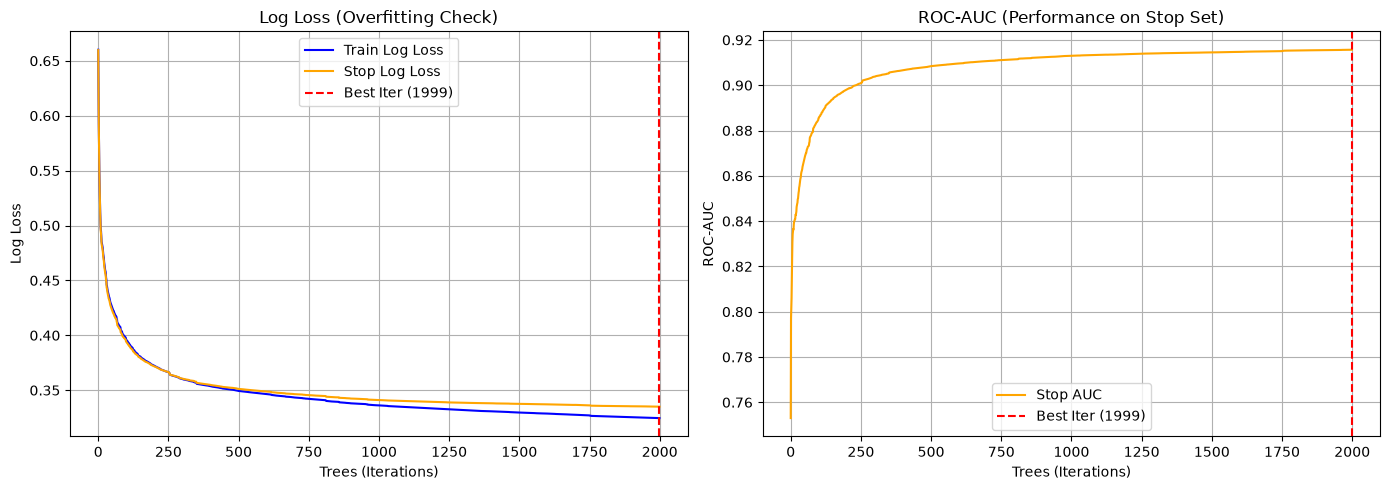

Calibrating Probabilities...

Evaluating Model on Dual Test Sets...
--- Model Performance Summary ---
Random Test     | ROC-AUC: 0.9161 | Log Loss: 0.3336 | Brier Score: 0.1095
OOT Test        | ROC-AUC: 0.7600 | Log Loss: 2.8119 | Brier Score: 0.4043

Temporal Degradation Penalty (AUC Drop): 0.1561
*(Both splits are order-grouped and label-mature. A large drop now means real
  behavioural/processor drift between the training period and OOT window.)*


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier, Pool

sampled_df = df

# Must match the DATEDIFF threshold in the training SQL's in-flight filter
MATURITY_DAYS = 30

# =====================================================================
# 1. Base Filtering and Sorting
# =====================================================================
sampled_df['LAST_DECLINE_CODE'] = sampled_df['LAST_DECLINE_CODE'].astype(str)
sampled_df['DECLINE_FAMILY'] = sampled_df['LAST_DECLINE_CODE'].str[0]

sampled_df['TRANSACTION_DATETIME'] = pd.to_datetime(sampled_df['TRANSACTION_DATETIME'])

# Sort ascending to guarantee Past predicts Future
sampled_df = sampled_df.sort_values('TRANSACTION_DATETIME').reset_index(drop=True)

# =====================================================================
# 1b. Invoice resolution timing  
# =====================================================================

print("Computing invoice resolution times...")

invoice_times = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    INVOICE_START=('TRANSACTION_DATETIME', 'min'),
    INVOICE_LAST_TXN=('TRANSACTION_DATETIME', 'max'),
    IS_EVENTUALLY_SUCCESSFUL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
)

first_accept = (
    sampled_df.loc[sampled_df['TRANSACTION_STATUS'] == 'accepted']
              .groupby('INVOICE_ID')['TRANSACTION_DATETIME'].min()
)

invoice_times['RESOLVED_AT'] = first_accept.reindex(invoice_times.index).where(
    invoice_times['IS_EVENTUALLY_SUCCESSFUL'] == 1,
    invoice_times['INVOICE_START'] + pd.Timedelta(days=MATURITY_DAYS)
)

if invoice_times['RESOLVED_AT'].isna().any():
    raise ValueError(
        f"{invoice_times['RESOLVED_AT'].isna().sum()} invoices are labelled successful "
        "but have no accepted transaction. Did the != 'accepted' filter get left in the SQL?"
    )

sampled_df = sampled_df.merge(
    invoice_times[['INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']],
    left_on='INVOICE_ID', right_index=True, how='left'
)

# Now drop the accepted rows -- at serving time the model only ever scores declines.
#sampled_df = sampled_df[sampled_df['TRANSACTION_STATUS'] != 'accepted'].reset_index(drop=True)
print(f"  {len(sampled_df):,} rows | {sampled_df['INVOICE_ID'].nunique():,} invoices "
      f"| {sampled_df['ORDER_ID'].nunique():,} orders")

# =======================================================================
# 2. Data Processing & Pre-Split Vectorized I
# =======================================================================
print("Processing and Imputing Data...")
drop_cols = ['ORDER_ID', 'INVOICE_ID', 'TRANSACTION_ID', 'TRANSACTION_DATETIME',
             'IS_EVENTUALLY_SUCCESSFUL', 'TRANSACTION_STATUS',
             'INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']

# Separate text features from standard categorical features for better string processing
text_features = [col for col in ['SUPER_PARTNER_ID_NAME', 'BANK'] if col in sampled_df.columns]

# Get remaining categorical features (Using errors='ignore' safely)
cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c not in text_features]

# Vectorized Imputation BEFORE the split (Massive speedup)
sampled_df[cat_features + text_features] = sampled_df[cat_features + text_features].fillna('unknown').astype(str)

# Get purely numeric feature columns (excluding drops and target)
numeric_cols = sampled_df.columns.difference(cat_features + text_features + drop_cols)
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(-1)

# =====================================================================
# 3. Hybrid Split (As-Of-Date OOT + Order-Grouped Random)
# =====================================================================
print("Splitting data (As-Of OOT + Order-Grouped Random)...")

ASOF_DATE = pd.Timestamp('2026-01-15')   # "retrain the model on this date"
OOT_END   = pd.Timestamp('2026-03-01')   # MUST be <= max ORDER_DATE in the extract

invoice_elig = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    RESOLVED_AT=('RESOLVED_AT', 'first'),
    INVOICE_LAST_TXN=('INVOICE_LAST_TXN', 'first'),
)
eligible_invoices = invoice_elig.index[
    (invoice_elig['RESOLVED_AT'] < ASOF_DATE) &
    (invoice_elig['INVOICE_LAST_TXN'] < ASOF_DATE)
]

past_data = sampled_df[
    sampled_df['INVOICE_ID'].isin(eligible_invoices) &
    (sampled_df['TRANSACTION_DATETIME'] < ASOF_DATE)
].copy()

oot_test_df = sampled_df[
    (sampled_df['TRANSACTION_DATETIME'] >= ASOF_DATE) &
    (sampled_df['TRANSACTION_DATETIME'] < OOT_END)
].copy()

assert not (set(past_data['INVOICE_ID']) & set(oot_test_df['INVOICE_ID'])), \
    "invoices straddle the as-of boundary"

print(f"  past_data   : {len(past_data):>9,} rows | {past_data['ORDER_ID'].nunique():>7,} orders")
print(f"  oot_test_df : {len(oot_test_df):>9,} rows | {oot_test_df['ORDER_ID'].nunique():>7,} orders")
print(f"  orders in both (new invoices, expected): "
      f"{len(set(past_data['ORDER_ID']) & set(oot_test_df['ORDER_ID'])):,}")
print(f"  dropped (unresolved at ASOF / beyond OOT_END): "
      f"{len(sampled_df) - len(past_data) - len(oot_test_df):,} rows")

# --- FIX 1: order-grouped assignment --------------------------------------------
# hashlib rather than hash(): Python salts str hashing per process, so hash() would
# reshuffle orders across splits on every run. This assignment is stable, and stays
# stable when new orders are added next month.
def order_hash_frac(order_ids, salt='retry_cutoff_v1'):
    return np.array([
        int(hashlib.md5(f'{salt}:{o}'.encode()).hexdigest()[:16], 16) / 2**64
        for o in order_ids
    ])

unique_orders = past_data['ORDER_ID'].unique()
order_frac = pd.Series(order_hash_frac(unique_orders), index=unique_orders)
row_frac = past_data['ORDER_ID'].map(order_frac)

# Same 75 / 10 / 10 / 5 boundaries as before -- but over ORDERS, not rows.
train_df       = past_data[row_frac < 0.75].copy()
stop_df        = past_data[(row_frac >= 0.75) & (row_frac < 0.85)].copy()
calib_df       = past_data[(row_frac >= 0.85) & (row_frac < 0.95)].copy()
random_test_df = past_data[row_frac >= 0.95].copy()

for _name, _part in [('train_df', train_df), ('stop_df', stop_df),
                     ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    print(f"  {_name:<15}: {len(_part):>9,} rows | {_part['ORDER_ID'].nunique():>7,} orders "
          f"| base rate {_part['IS_EVENTUALLY_SUCCESSFUL'].mean():.4f}")

for _a, _b in [('train_df', train_df), ('stop_df', stop_df),
               ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    for _c, _d in [('train_df', train_df), ('stop_df', stop_df),
                   ('calib_df', calib_df), ('random_test_df', random_test_df)]:
        if _a < _c:
            assert not (set(_b['ORDER_ID']) & set(_d['ORDER_ID'])), f"{_a}/{_c} share orders"
print("  [ok] no ORDER_ID spans two splits")

# 4. Separate X and y (Using errors='ignore' safely)
X_train, y_train = train_df.drop(columns=drop_cols, errors='ignore'), train_df['IS_EVENTUALLY_SUCCESSFUL']
X_stop,  y_stop  = stop_df.drop(columns=drop_cols, errors='ignore'),  stop_df['IS_EVENTUALLY_SUCCESSFUL']
X_calib, y_calib = calib_df.drop(columns=drop_cols, errors='ignore'), calib_df['IS_EVENTUALLY_SUCCESSFUL']

X_random_test, y_random_test = random_test_df.drop(columns=drop_cols, errors='ignore'), random_test_df['IS_EVENTUALLY_SUCCESSFUL']
X_oot_test,    y_oot_test    = oot_test_df.drop(columns=drop_cols, errors='ignore'),    oot_test_df['IS_EVENTUALLY_SUCCESSFUL']

# =====================================================================
# 4. Create Memory-Efficient CatBoost Pools
# =====================================================================
print("Building data pools...")
train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
stop_pool  = Pool(X_stop,  y_stop,  cat_features=cat_features, text_features=text_features)

# =====================================================================
# 5. Base Model Definition
# =====================================================================
print("Training Base Model...")
base_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.1,          # Updated Learning Rate
    depth=6,
    task_type="CPU",
    eval_metric='Logloss',
    custom_metric=['AUC'],
    l2_leaf_reg=6,
    thread_count=-1,
    early_stopping_rounds=100,
    verbose=50,
    random_state=42,
    cat_features=cat_features,
    text_features=text_features
)

# Train the model, strictly using the Stop pool
base_model.fit(train_pool, eval_set=stop_pool)

# =====================================================================
# 6. In-Flight Overfitting Diagnostic Plot
# =====================================================================
print("Plotting Learning Curves...")
history = base_model.evals_result_
iterations_range = range(len(history['learn']['Logloss']))
best_iter = base_model.get_best_iteration()

# Safely locate the validation dictionary key
val_key = 'validation' if 'validation' in history else 'validation_0'

plt.figure(figsize=(14, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(iterations_range, history['learn']['Logloss'], label='Train Log Loss', color='blue')
plt.plot(iterations_range, history[val_key]['Logloss'], label='Stop Log Loss', color='orange')
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
plt.title('Log Loss (Overfitting Check)')
plt.xlabel('Trees (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

# Plot ROC-AUC (Fixing the AUC KeyError by ignoring Train AUC)
plt.subplot(1, 2, 2)
if 'AUC' in history[val_key]:
    plt.plot(iterations_range, history[val_key]['AUC'], label='Stop AUC', color='orange')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
    plt.title('ROC-AUC (Performance on Stop Set)')
    plt.xlabel('Trees (Iterations)')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True)
else:
    plt.title('AUC not tracked')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. Probability Calibration
# =====================================================================
print("Calibrating Probabilities...")
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic'
)
calibrated_model.fit(X_calib, y_calib)

# =====================================================================
# 8. Final Dual-Evaluation (Random vs. Chronological)
# =====================================================================
print("\nEvaluating Model on Dual Test Sets...")

def evaluate_split(split_name, model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    brier = brier_score_loss(y, y_prob)
    print(f"{split_name: <15} | ROC-AUC: {auc:.4f} | Log Loss: {loss:.4f} | Brier Score: {brier:.4f}")
    return y_prob

print("--- Model Performance Summary ---")
# 1. Unseen ORDERS from the same period as training -> generalization to new customers.
random_probs = evaluate_split("Random Test", calibrated_model, X_random_test, y_random_test)

# 2. The strict future -> what the model would actually have scored after ASOF_DATE.
oot_probs    = evaluate_split("OOT Test", calibrated_model, X_oot_test, y_oot_test)

# Calculate the Degradation Penalty
auc_drop = roc_auc_score(y_random_test, random_probs) - roc_auc_score(y_oot_test, oot_probs)
print(f"\nTemporal Degradation Penalty (AUC Drop): {auc_drop:.4f}")
# CHANGED: both sides are now order-grouped and label-mature, so this gap is no longer
# contaminated by row duplication or by lifecycle-tail enrichment. What remains is
# genuine drift between the training period and the deployment window.
print("*(Both splits are order-grouped and label-mature. A large drop now means real")
print("  behavioural/processor drift between the training period and OOT window.)*")

No kernel connected

In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator

In [ ]:
# Start fetching data directly from Snowflake
ctx = snowflake.connector.connect(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
    warehouse='COMPUTE_WH',
    schema='EARLY_RETRY_CUTOFF'
)


# 2. Create a cursor and execute
cur = ctx.cursor()
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_DATA")

# 3. Fetch directly to a Pandas DataFrame using Arrow
# This is drastically faster than pd.read_sql()
df = cur.fetch_pandas_all()

Computing invoice resolution times...
  34,616,780 rows | 6,124,584 invoices | 2,007,998 orders
Processing and Imputing Data...


<ipython-input-3-7604bbc02c19>:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()


Splitting data (As-Of OOT + Order-Grouped Random)...
  past_data   : 3,597,133 rows | 1,173,337 orders
  oot_test_df : 11,530,829 rows | 1,430,624 orders
  orders in both (new invoices, expected): 690,371
  dropped (unresolved at ASOF / beyond OOT_END): 19,488,818 rows
  train_df       : 2,698,315 rows | 879,698 orders | base rate 0.6638
  stop_df        :   360,039 rows | 117,040 orders | base rate 0.6676
  calib_df       :   357,090 rows | 117,547 orders | base rate 0.6690
  random_test_df :   181,689 rows |  59,052 orders | base rate 0.6658
  [ok] no ORDER_ID spans two splits
Building data pools...
Training Base Model...
0:	learn: 0.6600473	test: 0.6597360	best: 0.6597360 (0)	total: 1.86s	remaining: 1h 1m 53s
50:	learn: 0.4251312	test: 0.4224208	best: 0.4224208 (50)	total: 1m 26s	remaining: 54m 59s
100:	learn: 0.3961298	test: 0.3941582	best: 0.3941582 (100)	total: 2m 38s	remaining: 49m 43s
150:	learn: 0.3806504	test: 0.3795100	best: 0.3795100 (150)	total: 3m 53s	remaining: 47m 44s
2

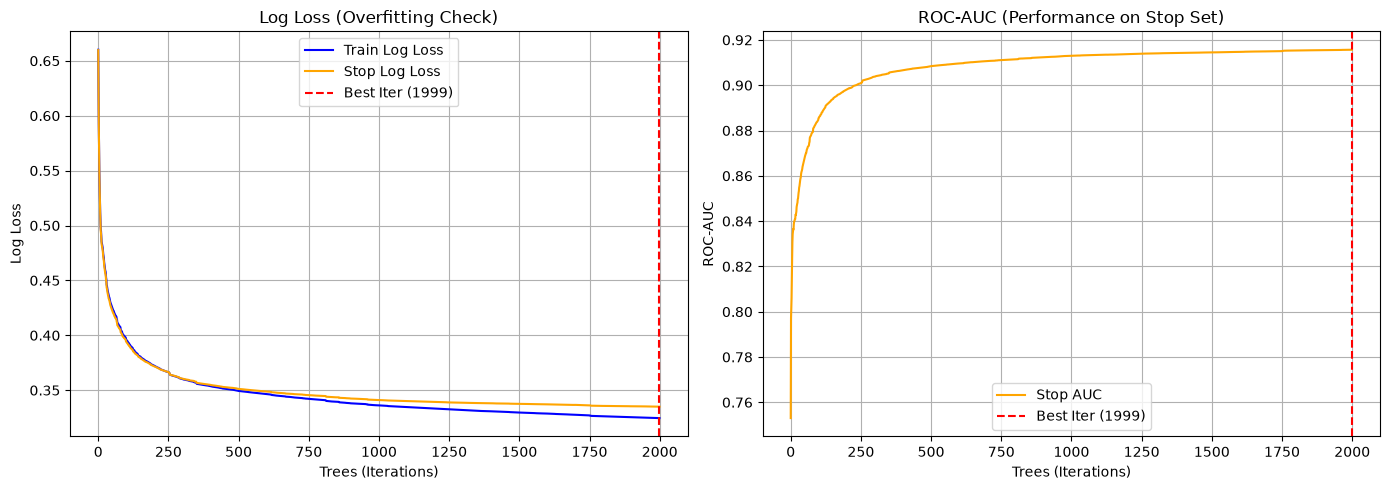

Calibrating Probabilities...

Evaluating Model on Dual Test Sets...
--- Model Performance Summary ---
Random Test     | ROC-AUC: 0.9161 | Log Loss: 0.3336 | Brier Score: 0.1095
OOT Test        | ROC-AUC: 0.7600 | Log Loss: 2.8119 | Brier Score: 0.4043

Temporal Degradation Penalty (AUC Drop): 0.1561
*(Both splits are order-grouped and label-mature. A large drop now means real
  behavioural/processor drift between the training period and OOT window.)*


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier, Pool

sampled_df = df

# Must match the DATEDIFF threshold in the training SQL's in-flight filter
MATURITY_DAYS = 30

# =====================================================================
# 1. Base Filtering and Sorting
# =====================================================================
sampled_df['LAST_DECLINE_CODE'] = sampled_df['LAST_DECLINE_CODE'].astype(str)
sampled_df['DECLINE_FAMILY'] = sampled_df['LAST_DECLINE_CODE'].str[0]

sampled_df['TRANSACTION_DATETIME'] = pd.to_datetime(sampled_df['TRANSACTION_DATETIME'])

# Sort ascending to guarantee Past predicts Future
sampled_df = sampled_df.sort_values('TRANSACTION_DATETIME').reset_index(drop=True)

# =====================================================================
# 1b. Invoice resolution timing  
# =====================================================================

print("Computing invoice resolution times...")

invoice_times = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    INVOICE_START=('TRANSACTION_DATETIME', 'min'),
    INVOICE_LAST_TXN=('TRANSACTION_DATETIME', 'max'),
    IS_EVENTUALLY_SUCCESSFUL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
)

first_accept = (
    sampled_df.loc[sampled_df['TRANSACTION_STATUS'] == 'accepted']
              .groupby('INVOICE_ID')['TRANSACTION_DATETIME'].min()
)

invoice_times['RESOLVED_AT'] = first_accept.reindex(invoice_times.index).where(
    invoice_times['IS_EVENTUALLY_SUCCESSFUL'] == 1,
    invoice_times['INVOICE_START'] + pd.Timedelta(days=MATURITY_DAYS)
)

if invoice_times['RESOLVED_AT'].isna().any():
    raise ValueError(
        f"{invoice_times['RESOLVED_AT'].isna().sum()} invoices are labelled successful "
        "but have no accepted transaction. Did the != 'accepted' filter get left in the SQL?"
    )

sampled_df = sampled_df.merge(
    invoice_times[['INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']],
    left_on='INVOICE_ID', right_index=True, how='left'
)

# Now drop the accepted rows -- at serving time the model only ever scores declines.
#sampled_df = sampled_df[sampled_df['TRANSACTION_STATUS'] != 'accepted'].reset_index(drop=True)
print(f"  {len(sampled_df):,} rows | {sampled_df['INVOICE_ID'].nunique():,} invoices "
      f"| {sampled_df['ORDER_ID'].nunique():,} orders")

# =======================================================================
# 2. Data Processing & Pre-Split Vectorized I
# =======================================================================
print("Processing and Imputing Data...")
drop_cols = ['ORDER_ID', 'INVOICE_ID', 'TRANSACTION_ID', 'TRANSACTION_DATETIME',
             'IS_EVENTUALLY_SUCCESSFUL', 'TRANSACTION_STATUS',
             'INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']

# Separate text features from standard categorical features for better string processing
text_features = [col for col in ['SUPER_PARTNER_ID_NAME', 'BANK'] if col in sampled_df.columns]

# Get remaining categorical features (Using errors='ignore' safely)
cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c not in text_features]

# Vectorized Imputation BEFORE the split (Massive speedup)
sampled_df[cat_features + text_features] = sampled_df[cat_features + text_features].fillna('unknown').astype(str)

# Get purely numeric feature columns (excluding drops and target)
numeric_cols = sampled_df.columns.difference(cat_features + text_features + drop_cols)
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(-1)

# =====================================================================
# 3. Hybrid Split (As-Of-Date OOT + Order-Grouped Random)
# =====================================================================
print("Splitting data (As-Of OOT + Order-Grouped Random)...")

ASOF_DATE = pd.Timestamp('2026-01-15')   # "retrain the model on this date"
OOT_END   = pd.Timestamp('2026-03-01')   # MUST be <= max ORDER_DATE in the extract

invoice_elig = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    RESOLVED_AT=('RESOLVED_AT', 'first'),
    INVOICE_LAST_TXN=('INVOICE_LAST_TXN', 'first'),
)
eligible_invoices = invoice_elig.index[
    (invoice_elig['RESOLVED_AT'] < ASOF_DATE) &
    (invoice_elig['INVOICE_LAST_TXN'] < ASOF_DATE)
]

past_data = sampled_df[
    sampled_df['INVOICE_ID'].isin(eligible_invoices) &
    (sampled_df['TRANSACTION_DATETIME'] < ASOF_DATE)
].copy()

oot_test_df = sampled_df[
    (sampled_df['TRANSACTION_DATETIME'] >= ASOF_DATE) &
    (sampled_df['TRANSACTION_DATETIME'] < OOT_END)
].copy()

assert not (set(past_data['INVOICE_ID']) & set(oot_test_df['INVOICE_ID'])), \
    "invoices straddle the as-of boundary"

print(f"  past_data   : {len(past_data):>9,} rows | {past_data['ORDER_ID'].nunique():>7,} orders")
print(f"  oot_test_df : {len(oot_test_df):>9,} rows | {oot_test_df['ORDER_ID'].nunique():>7,} orders")
print(f"  orders in both (new invoices, expected): "
      f"{len(set(past_data['ORDER_ID']) & set(oot_test_df['ORDER_ID'])):,}")
print(f"  dropped (unresolved at ASOF / beyond OOT_END): "
      f"{len(sampled_df) - len(past_data) - len(oot_test_df):,} rows")

# --- FIX 1: order-grouped assignment --------------------------------------------
# hashlib rather than hash(): Python salts str hashing per process, so hash() would
# reshuffle orders across splits on every run. This assignment is stable, and stays
# stable when new orders are added next month.
def order_hash_frac(order_ids, salt='retry_cutoff_v1'):
    return np.array([
        int(hashlib.md5(f'{salt}:{o}'.encode()).hexdigest()[:16], 16) / 2**64
        for o in order_ids
    ])

unique_orders = past_data['ORDER_ID'].unique()
order_frac = pd.Series(order_hash_frac(unique_orders), index=unique_orders)
row_frac = past_data['ORDER_ID'].map(order_frac)

# Same 75 / 10 / 10 / 5 boundaries as before -- but over ORDERS, not rows.
train_df       = past_data[row_frac < 0.75].copy()
stop_df        = past_data[(row_frac >= 0.75) & (row_frac < 0.85)].copy()
calib_df       = past_data[(row_frac >= 0.85) & (row_frac < 0.95)].copy()
random_test_df = past_data[row_frac >= 0.95].copy()

for _name, _part in [('train_df', train_df), ('stop_df', stop_df),
                     ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    print(f"  {_name:<15}: {len(_part):>9,} rows | {_part['ORDER_ID'].nunique():>7,} orders "
          f"| base rate {_part['IS_EVENTUALLY_SUCCESSFUL'].mean():.4f}")

for _a, _b in [('train_df', train_df), ('stop_df', stop_df),
               ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    for _c, _d in [('train_df', train_df), ('stop_df', stop_df),
                   ('calib_df', calib_df), ('random_test_df', random_test_df)]:
        if _a < _c:
            assert not (set(_b['ORDER_ID']) & set(_d['ORDER_ID'])), f"{_a}/{_c} share orders"
print("  [ok] no ORDER_ID spans two splits")

# 4. Separate X and y (Using errors='ignore' safely)
X_train, y_train = train_df.drop(columns=drop_cols, errors='ignore'), train_df['IS_EVENTUALLY_SUCCESSFUL']
X_stop,  y_stop  = stop_df.drop(columns=drop_cols, errors='ignore'),  stop_df['IS_EVENTUALLY_SUCCESSFUL']
X_calib, y_calib = calib_df.drop(columns=drop_cols, errors='ignore'), calib_df['IS_EVENTUALLY_SUCCESSFUL']

X_random_test, y_random_test = random_test_df.drop(columns=drop_cols, errors='ignore'), random_test_df['IS_EVENTUALLY_SUCCESSFUL']
X_oot_test,    y_oot_test    = oot_test_df.drop(columns=drop_cols, errors='ignore'),    oot_test_df['IS_EVENTUALLY_SUCCESSFUL']

# =====================================================================
# 4. Create Memory-Efficient CatBoost Pools
# =====================================================================
print("Building data pools...")
train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
stop_pool  = Pool(X_stop,  y_stop,  cat_features=cat_features, text_features=text_features)

# =====================================================================
# 5. Base Model Definition
# =====================================================================
print("Training Base Model...")
base_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.1,          # Updated Learning Rate
    depth=6,
    task_type="CPU",
    eval_metric='Logloss',
    custom_metric=['AUC'],
    l2_leaf_reg=6,
    thread_count=-1,
    early_stopping_rounds=100,
    verbose=50,
    random_state=42,
    cat_features=cat_features,
    text_features=text_features
)

# Train the model, strictly using the Stop pool
base_model.fit(train_pool, eval_set=stop_pool)

# =====================================================================
# 6. In-Flight Overfitting Diagnostic Plot
# =====================================================================
print("Plotting Learning Curves...")
history = base_model.evals_result_
iterations_range = range(len(history['learn']['Logloss']))
best_iter = base_model.get_best_iteration()

# Safely locate the validation dictionary key
val_key = 'validation' if 'validation' in history else 'validation_0'

plt.figure(figsize=(14, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(iterations_range, history['learn']['Logloss'], label='Train Log Loss', color='blue')
plt.plot(iterations_range, history[val_key]['Logloss'], label='Stop Log Loss', color='orange')
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
plt.title('Log Loss (Overfitting Check)')
plt.xlabel('Trees (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

# Plot ROC-AUC (Fixing the AUC KeyError by ignoring Train AUC)
plt.subplot(1, 2, 2)
if 'AUC' in history[val_key]:
    plt.plot(iterations_range, history[val_key]['AUC'], label='Stop AUC', color='orange')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
    plt.title('ROC-AUC (Performance on Stop Set)')
    plt.xlabel('Trees (Iterations)')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True)
else:
    plt.title('AUC not tracked')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. Probability Calibration
# =====================================================================
print("Calibrating Probabilities...")
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic'
)
calibrated_model.fit(X_calib, y_calib)

# =====================================================================
# 8. Final Dual-Evaluation (Random vs. Chronological)
# =====================================================================
print("\nEvaluating Model on Dual Test Sets...")

def evaluate_split(split_name, model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    brier = brier_score_loss(y, y_prob)
    print(f"{split_name: <15} | ROC-AUC: {auc:.4f} | Log Loss: {loss:.4f} | Brier Score: {brier:.4f}")
    return y_prob

print("--- Model Performance Summary ---")
# 1. Unseen ORDERS from the same period as training -> generalization to new customers.
random_probs = evaluate_split("Random Test", calibrated_model, X_random_test, y_random_test)

# 2. The strict future -> what the model would actually have scored after ASOF_DATE.
oot_probs    = evaluate_split("OOT Test", calibrated_model, X_oot_test, y_oot_test)

# Calculate the Degradation Penalty
auc_drop = roc_auc_score(y_random_test, random_probs) - roc_auc_score(y_oot_test, oot_probs)
print(f"\nTemporal Degradation Penalty (AUC Drop): {auc_drop:.4f}")
# CHANGED: both sides are now order-grouped and label-mature, so this gap is no longer
# contaminated by row duplication or by lifecycle-tail enrichment. What remains is
# genuine drift between the training period and the deployment window.
print("*(Both splits are order-grouped and label-mature. A large drop now means real")
print("  behavioural/processor drift between the training period and OOT window.)*")

In [ ]:
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

# 2. Package the model and the exact feature lists into one dictionary
# This ensures your prediction script applies the exact same preprocessing
model_artifact = {
    'model': calibrated_model,
    'cat_features': cat_features,
    'text_features': text_features,
    'drop_cols': drop_cols,
    'asof_date': ASOF_DATE,      # CHANGED: what the model knew, and when
    'oot_end': OOT_END,
}

# 3. Save the artifact to the script's directory
joblib.dump(model_artifact, model_path)

print(f"Model artifact successfully saved to: {model_path}")

Model artifact successfully saved to: /Users/amanda.huang/NIC/amanda_projects/Early_Retry_Cutoffs/calibrated_catboost_model.joblib


In [ ]:
# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active in your environment
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_062025")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
# CHANGED: mirrors section 1 -- DECLINE_FAMILY comes from LAST_DECLINE_CODE now.
# Without this the model's DECLINE_FAMILY column is missing and the reindex below
# raises a KeyError.
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    # Grab the wrapper from the first fold
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    # Fallback if calibrated without CV somehow
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator (Checking common attribute names)
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class (IS_EVENTUALLY_SUCCESSFUL = 1)
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!


In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against FCT_ECLTV_ORDER holding >1 row per order, which
        -- would fan out the join below and multiply cltv_360.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left')

    # Never fillna(0) here: ECLTV_1Y=0 passes the cap, drives loss negative, and turns a
    # missing join key into a phantom profit. Unpriceable orders get excluded instead.
    n_before = df['ORDER_ID'].nunique()
    df = df[df['ECLTV_1Y'].notna() & df['CLTV_360'].notna()].copy()
    dropped = n_before - df['ORDER_ID'].nunique()
    if dropped:
        print(f"Dropped {dropped:,}/{n_before:,} orders ({dropped/n_before:.1%}) with no CLTV.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the whole order, so every remaining attempt across all of its
    # invoices is saved. The decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # The order is cancelled, so all remaining collections are forgone -- not conditional
    # on whether this particular invoice would have succeeded. clip(0) because
    # CLTV_360 < already-collected means the two windows disagree, not that we profited.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    cut['loss_projected'] = (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Would Have Paid More': int((cut['loss_actual'] > 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_projected'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_projected']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


def evaluate_fixed_rule(df, retries_to_test, ecltv_max_threshold=float('inf')):
    """Baseline the model has to beat: cut every order at retry N, ignoring the model."""
    rows = []
    for n in retries_to_test:
        cut = df[(df['RETRIES'] >= n) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'always cut at retry {n}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
baseline_report = evaluate_fixed_rule(cutoff_df, [10, 16, 20, 25], ECLTV_CAP)

print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))
print(f"\n=== Baseline: fixed retry cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(baseline_report.to_string(index=False))
print("\nThe model is only worth deploying if its best Net beats the best fixed rule.")

Dropped 149,349/381,056 orders (39.2%) with no CLTV.

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Would Have Paid More  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       36625                  3663     81273.3      115737.88     -34464.58    108742.86   -27469.56
model p < 0.02       46980                  4593    101783.1      139451.70     -37668.60    141728.04   -39944.94
model p < 0.03       51240                  4909    108937.8      148218.56     -39280.76    155890.74   -46952.94
model p < 0.05       54730                  5179    114844.6      154329.58     -39484.98    167451.18   -52606.58
 model p < 0.1       59425                  5636    122937.7      165025.87     -42088.17    183539.06   -60601.36
model p < 0.15       64541                  6256    132079.8      177835.64     -45755.84    200964.64   -68884.84
 model p < 0.2       69409                  7043    141934.6      195195.86     -53261.26    21786

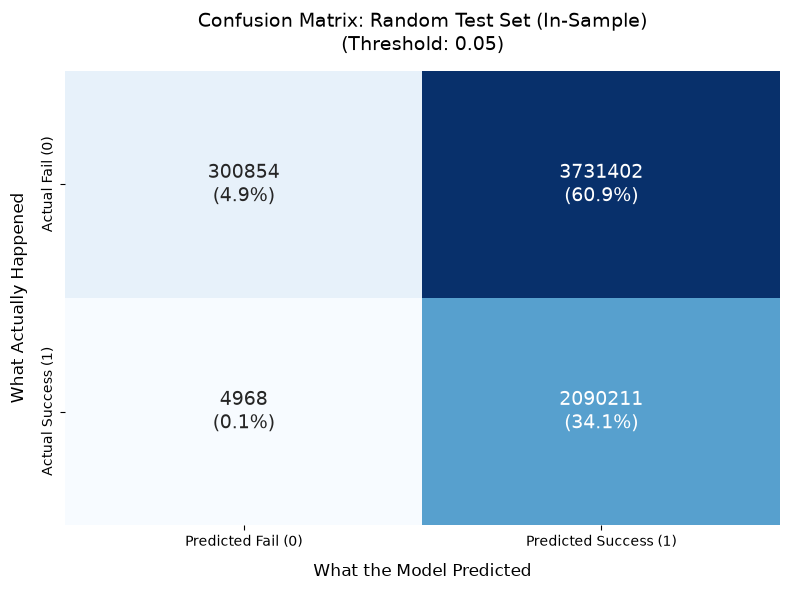


--- Confusion Matrix Breakdown: Random Test Set (In-Sample) (Threshold: 0.05) ---
True Negatives (TN):  300,854 (4.9%) -> Correctly cut off
False Positives (FP): 3,731,402 (60.9%) -> Wasted $0.10 retry
False Negatives (FN): 4,968 (0.1%) -> Missed revenue!
True Positives (TP):  2,090,211 (34.1%) -> Successfully collected


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_business_confusion_matrix(y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact based on model predictions and a given threshold.
    """
    # 2. Convert probabilities to hard predictions
    y_pred = (y_probs >= threshold).astype(int)

    # 3. Calculate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 4. Calculate Percentages and Create Custom Labels ugk 
    # Divide each cell by the total number of predictions to get the % of total
    cm_percentages = cm / np.sum(cm)

    # Zip the raw counts and the percentages together into a formatted string
    labels = [f"{count}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    # Reshape the list of strings back into a 2x2 grid to match the heatmap
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))

    # Notice we changed annot=labels and fmt='' (empty string) so Seaborn accepts our custom text
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
    plt.ylabel('What Actually Happened', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- Confusion Matrix Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"True Negatives (TN):  {tn:,} ({cm_percentages[0,0]:.1%}) -> Correctly cut off")
    print(f"False Positives (FP): {fp:,} ({cm_percentages[0,1]:.1%}) -> Wasted $0.10 retry")
    print(f"False Negatives (FN): {fn:,} ({cm_percentages[1,0]:.1%}) -> Missed revenue!")
    print(f"True Positives (TP):  {tp:,} ({cm_percentages[1,1]:.1%}) -> Successfully collected")

# =====================================================================
# Generate the Confusion Matrices using variables from your training script
# ====================================================================

# Check the Random Holdout Test Set
y_true_062025 = df_pred['IS_EVENTUALLY_SUCCESSFUL'].values
y_probs_062025 = df_pred['SUCCESS_PROBABILITY'].values

plot_business_confusion_matrix(y_true=y_true_062025, 
                               y_probs=y_probs_062025, 
                               threshold=0.05, 
                               dataset_name="Random Test Set (In-Sample)")

In [ ]:
# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active in your environment
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_062025 ")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
# CHANGED: mirrors section 1 -- DECLINE_FAMILY comes from LAST_DECLINE_CODE now.
# Without this the model's DECLINE_FAMILY column is missing and the reindex below
# raises a KeyError.
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    # Grab the wrapper from the first fold
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    # Fallback if calibrated without CV somehow
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator (Checking common attribute names)
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class (IS_EVENTUALLY_SUCCESSFUL = 1)
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!


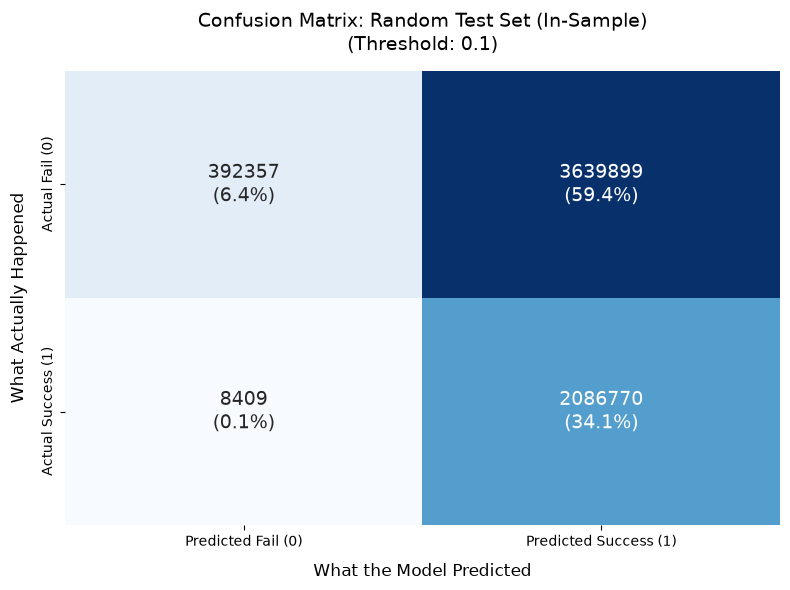


--- Confusion Matrix Breakdown: Random Test Set (In-Sample) (Threshold: 0.1) ---
True Negatives (TN):  392,357 (6.4%) -> Correctly cut off
False Positives (FP): 3,639,899 (59.4%) -> Wasted $0.10 retry
False Negatives (FN): 8,409 (0.1%) -> Missed revenue!
True Positives (TP):  2,086,770 (34.1%) -> Successfully collected


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_business_confusion_matrix(y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact based on model predictions and a given threshold.
    """
    # 2. Convert probabilities to hard predictions
    y_pred = (y_probs >= threshold).astype(int)

    # 3. Calculate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 4. Calculate Percentages and Create Custom Labels ugk 
    # Divide each cell by the total number of predictions to get the % of total
    cm_percentages = cm / np.sum(cm)

    # Zip the raw counts and the percentages together into a formatted string
    labels = [f"{count}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    # Reshape the list of strings back into a 2x2 grid to match the heatmap
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))

    # Notice we changed annot=labels and fmt='' (empty string) so Seaborn accepts our custom text
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
    plt.ylabel('What Actually Happened', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- Confusion Matrix Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"True Negatives (TN):  {tn:,} ({cm_percentages[0,0]:.1%}) -> Correctly cut off")
    print(f"False Positives (FP): {fp:,} ({cm_percentages[0,1]:.1%}) -> Wasted $0.10 retry")
    print(f"False Negatives (FN): {fn:,} ({cm_percentages[1,0]:.1%}) -> Missed revenue!")
    print(f"True Positives (TP):  {tp:,} ({cm_percentages[1,1]:.1%}) -> Successfully collected")

# =====================================================================
# Generate the Confusion Matrices using variables from your training script
# ====================================================================

# Check the Random Holdout Test Set
y_true_062025 = df_pred['IS_EVENTUALLY_SUCCESSFUL'].values
y_probs_062025 = df_pred['SUCCESS_PROBABILITY'].values

plot_business_confusion_matrix(y_true=y_true_062025, 
                               y_probs=y_probs_062025, 
                               threshold=0.1, 
                               dataset_name="Random Test Set (In-Sample)")

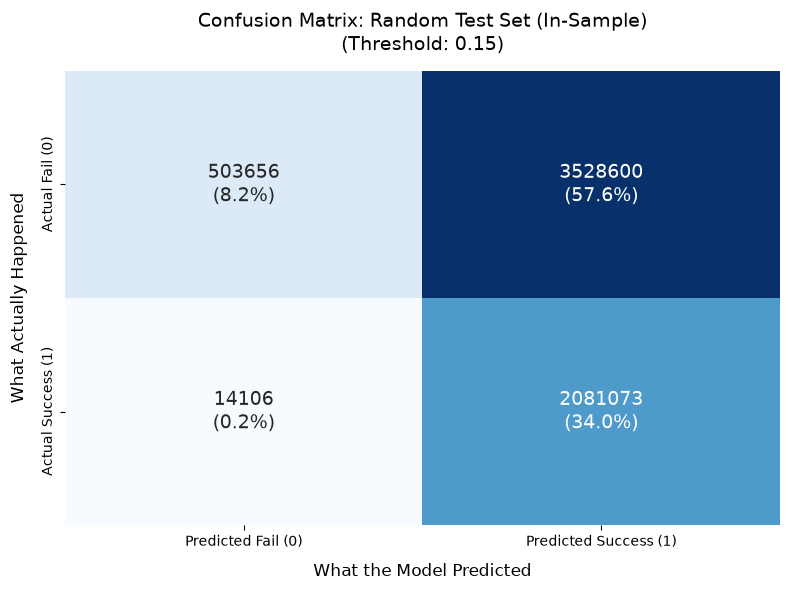


--- Confusion Matrix Breakdown: Random Test Set (In-Sample) (Threshold: 0.15) ---
True Negatives (TN):  503,656 (8.2%) -> Correctly cut off
False Positives (FP): 3,528,600 (57.6%) -> Wasted $0.10 retry
False Negatives (FN): 14,106 (0.2%) -> Missed revenue!
True Positives (TP):  2,081,073 (34.0%) -> Successfully collected


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_business_confusion_matrix(y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact based on model predictions and a given threshold.
    """
    # 2. Convert probabilities to hard predictions
    y_pred = (y_probs >= threshold).astype(int)

    # 3. Calculate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 4. Calculate Percentages and Create Custom Labels ugk 
    # Divide each cell by the total number of predictions to get the % of total
    cm_percentages = cm / np.sum(cm)

    # Zip the raw counts and the percentages together into a formatted string
    labels = [f"{count}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    # Reshape the list of strings back into a 2x2 grid to match the heatmap
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))

    # Notice we changed annot=labels and fmt='' (empty string) so Seaborn accepts our custom text
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
    plt.ylabel('What Actually Happened', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- Confusion Matrix Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"True Negatives (TN):  {tn:,} ({cm_percentages[0,0]:.1%}) -> Correctly cut off")
    print(f"False Positives (FP): {fp:,} ({cm_percentages[0,1]:.1%}) -> Wasted $0.10 retry")
    print(f"False Negatives (FN): {fn:,} ({cm_percentages[1,0]:.1%}) -> Missed revenue!")
    print(f"True Positives (TP):  {tp:,} ({cm_percentages[1,1]:.1%}) -> Successfully collected")

# =====================================================================
# Generate the Confusion Matrices using variables from your training script
# ====================================================================

# Check the Random Holdout Test Set
y_true_062025 = df_pred['IS_EVENTUALLY_SUCCESSFUL'].values
y_probs_062025 = df_pred['SUCCESS_PROBABILITY'].values

plot_business_confusion_matrix(y_true=y_true_062025, 
                               y_probs=y_probs_062025, 
                               threshold=0.15, 
                               dataset_name="Random Test Set (In-Sample)")

In [ ]:
import pandas as pd
import numpy as np

def evaluate_cutoff_thresholds(df_pred, thresholds_to_test, ecltv_max_threshold=float('inf')):
    """
    Calculates the financial impact of cutting off retries based on a probability threshold.
    Only cuts off orders if their ECLTV_1Y is strictly less than ecltv_max_threshold.
    """
    print("Loading data and merging...")
    
    # Execute Snowflake query
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
    SELECT ORDER_ID, CLTV_PRED_MEAN as ECLTV_1Y FROM DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
    ),

    tb as (select
    order_id,
    div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360 then transaction_amount else 0 end),
        count (distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360 then order_id else null end)) as cltv_360,
    max(ECLTV_1Y) as ecltv_1y
    FROM DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    left join ecltv using (order_id)
    where order_date >= '2025-06-01' and order_date < '2025-07-01'
    and is_m0 = 1
    group by 1
    )

    select 
    *
    from tb
    """) 
    ecltv_df = cur.fetch_pandas_all()
    
    # 1. Ensure datetime formatting
    df_pred['TRANSACTION_DATETIME'] = pd.to_datetime(df_pred['TRANSACTION_DATETIME'])
    
    # 2. Merge predictions with the ECLTV dataframe from Snowflake
    df = pd.merge(df_pred, ecltv_df, on='ORDER_ID', how='left')
    
    # Fill missing ECLTV with 0 to prevent math errors
    df['ECLTV_1Y'] = df['ECLTV_1Y'].fillna(0)
    df['CLTV_360'] = df['CLTV_360'].fillna(0)
    
    # 3. Sort chronologically
    df = df.sort_values(by=['ORDER_ID', 'TRANSACTION_DATETIME'])
    
    # --- Calculate order-level maximums for Gain and Actual Loss ---
    print("Calculating order-level maximums...")
    order_stats = df.groupby('ORDER_ID').agg(
        MAX_RETRY_COUNT=('RETRIES', 'max')
    ).reset_index()
    
    # Merge the max stats back into the main dataframe
    df = pd.merge(df, order_stats, on='ORDER_ID', how='left')
    results = []
    
    print(f"Evaluating thresholds with an ECLTV cap of {ecltv_max_threshold}...")
    # 4. Iterate over thresholds to generate a comparative report
    for threshold in thresholds_to_test:
        
        # --- MODIFIED LOGIC: Filter by BOTH probability and ECLTV ---
        below_threshold = df[
            (df['SUCCESS_PROBABILITY'] < threshold) & 
            (df['ECLTV_1Y'] < ecltv_max_threshold)
        ]
        
        # Keep only the FIRST instance for each order
        first_cutoffs = below_threshold.drop_duplicates(subset=['ORDER_ID'], keep='first').copy()
        
        # 5. Calculate Financial Impacts
        
        # Gain: (max retry count in the order - current retry count) * 0.1
        first_cutoffs['money_gained'] = (first_cutoffs['MAX_RETRY_COUNT'] - first_cutoffs['RETRIES']) * 0.1
        
        # Loss Actual: (actual collections over 360 days - current transaction HISTORICAL_COLLECTED_AMOUNT)
        first_cutoffs['loss_actual'] = np.where(
            first_cutoffs['IS_EVENTUALLY_SUCCESSFUL'] == 1,
            first_cutoffs['CLTV_360'] - first_cutoffs['HISTORICAL_COLLECTED_AMOUNT'],
            0.0
        )
        
        # Loss Projected: (ECLTV_1Y - current transaction HISTORICAL_COLLECTED_AMOUNT)
        first_cutoffs['loss_projected'] = np.where(
            first_cutoffs['IS_EVENTUALLY_SUCCESSFUL'] == 1,
            first_cutoffs['ECLTV_1Y'] - first_cutoffs['HISTORICAL_COLLECTED_AMOUNT'],
            0.0
        )
        
        # Calculate Net Actual and Net Projected
        first_cutoffs['net_actual'] = first_cutoffs['money_gained'] - first_cutoffs['loss_actual']
        first_cutoffs['net_projected'] = first_cutoffs['money_gained'] - first_cutoffs['loss_projected']
        
        # 6. Aggregate results for this threshold
        results.append({
            'Prob Threshold': threshold,
            'ECLTV Cap': ecltv_max_threshold,
            'Orders Cut': len(first_cutoffs),
            'Total Gain': round(first_cutoffs['money_gained'].sum(), 2),
            'Loss (Actual)': round(first_cutoffs['loss_actual'].sum(), 2),
            'Net (Actual)': round(first_cutoffs['net_actual'].sum(), 2),
            'Loss (Proj)': round(first_cutoffs['loss_projected'].sum(), 2),
            'Net (Proj)': round(first_cutoffs['net_projected'].sum(), 2)
        })
        
    return pd.DataFrame(results)

# Run the evaluation
test_thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.15]

# Set your ECLTV limit here (e.g., only cancel orders with ECLTV < 100)
# If you don't pass this argument, it defaults to infinity (meaning no ECLTV limit).
impact_report = evaluate_cutoff_thresholds(df_pred, test_thresholds, ecltv_max_threshold=20)

print(impact_report.to_string(index=False))

Loading data and merging...
Calculating order-level maximums...
Evaluating thresholds with an ECLTV cap of 20...
 Prob Threshold  ECLTV Cap  Orders Cut  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
           0.01         20       41619     64618.7        2373.52      62245.18       122.27    64496.43
           0.02         20       58029     81357.1        5278.81      76078.29       680.59    80676.51
           0.03         20       66231     87368.8        6926.80      80442.00      1094.94    86273.86
           0.04         20       67047     87905.5        7151.52      80753.98      1174.00    86731.50
           0.05         20       73713     92438.8       10422.61      82016.19      1784.93    90653.87
           0.10         20       84266     99394.3       18024.28      81370.02      2953.90    96440.40
           0.15         20       95938    107491.8       29395.49      78096.31      4631.38   102860.42


In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against FCT_ECLTV_ORDER holding >1 row per order, which
        -- would fan out the join below and multiply cltv_360.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left')

    # Never fillna(0) here: ECLTV_1Y=0 passes the cap, drives loss negative, and turns a
    # missing join key into a phantom profit. Unpriceable orders get excluded instead.
    n_before = df['ORDER_ID'].nunique()
    df = df[df['ECLTV_1Y'].notna() & df['CLTV_360'].notna()].copy()
    dropped = n_before - df['ORDER_ID'].nunique()
    if dropped:
        print(f"Dropped {dropped:,}/{n_before:,} orders ({dropped/n_before:.1%}) with no CLTV.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the whole order, so every remaining attempt across all of its
    # invoices is saved. The decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # The order is cancelled, so all remaining collections are forgone -- not conditional
    # on whether this particular invoice would have succeeded. clip(0) because
    # CLTV_360 < already-collected means the two windows disagree, not that we profited.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    cut['loss_projected'] = (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Would Have Paid More': int((cut['loss_actual'] > 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_projected'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_projected']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


def evaluate_fixed_rule(df, retries_to_test, ecltv_max_threshold=float('inf')):
    """Baseline the model has to beat: cut every order at retry N, ignoring the model."""
    rows = []
    for n in retries_to_test:
        cut = df[(df['RETRIES'] >= n) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'always cut at retry {n}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
baseline_report = evaluate_fixed_rule(cutoff_df, [10, 16, 20, 25], ECLTV_CAP)

print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))
print(f"\n=== Baseline: fixed retry cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(baseline_report.to_string(index=False))
print("\nThe model is only worth deploying if its best Net beats the best fixed rule.")

Dropped 149,349/381,056 orders (39.2%) with no CLTV.

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Would Have Paid More  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       36625                  3663     81273.3      115737.88     -34464.58    108742.86   -27469.56
model p < 0.02       46980                  4593    101783.1      139451.70     -37668.60    141728.04   -39944.94
model p < 0.03       51240                  4909    108937.8      148218.56     -39280.76    155890.74   -46952.94
model p < 0.05       54730                  5179    114844.6      154329.58     -39484.98    167451.18   -52606.58
 model p < 0.1       59425                  5636    122937.7      165025.87     -42088.17    183539.06   -60601.36
model p < 0.15       64541                  6256    132079.8      177835.64     -45755.84    200964.64   -68884.84
 model p < 0.2       69409                  7043    141934.6      195195.86     -53261.26    21786

In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator

In [ ]:
ctx = snowflake.connector.connect(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
    warehouse='COMPUTE_WH',
    schema='EARLY_RETRY_CUTOFF'
)

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    cut['loss_projected'] = (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_projected'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_projected']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


def evaluate_fixed_rule(df, retries_to_test, ecltv_max_threshold=float('inf')):
    """Baseline the model must beat: cut at retry N, ignoring the model."""
    rows = []
    for n in retries_to_test:
        cut = df[(df['RETRIES'] >= n) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'always cut at retry {n}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
baseline_report = evaluate_fixed_rule(cutoff_df, [10, 16, 20, 25], ECLTV_CAP)

print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))
print(f"\n=== Baseline: fixed retry cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(baseline_report.to_string(index=False))
print("\nModel is worth deploying only if its best Net beats the best fixed rule.")

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 381,056 total | 148,964 never made M0 (loss=0, kept) | 385 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       41520                35839     81882.7      115737.88     -33855.18    108742.86   -26860.16
model p < 0.02       57905                48623    103301.7      139451.70     -36150.00    141728.04   -38426.34
model p < 0.03       66101                54635    111074.0      148218.56     -37144.56    155890.74   -44816.74
model p < 0.05       73570                60086    117645.9      154329.58     -36683.68    167451.18   -49805.28
 model p < 0.1       84117                67511    126825.0      165025.87     -38200.87    183539.06   -56714.06
model p < 0.15       95779                75758    137341.3      177835.64     -40494.34    200964.64   -63623.34
 model p < 0.2      105805                82399    148534.7      19519

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 381,056 total | 148,964 never made M0 (loss=0, kept) | 385 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       41520                35839     81882.7      115737.88     -33855.18
model p < 0.02       57905                48623    103301.7      139451.70     -36150.00
model p < 0.03       66101                54635    111074.0      148218.56     -37144.56
model p < 0.05       73570                60086    117645.9      154329.58     -36683.68
 model p < 0.1       84117                67511    126825.0      165025.87     -38200.87
model p < 0.15       95779                75758    137341.3      177835.64     -40494.34
 model p < 0.2      105805                82399    148534.7      195195.86     -46661.16
 model p < 0.3      123402                93492    170324.2      231326.86     -61002.66
 model p < 0.4      140584               104476    194685.8      27

In [ ]:
print(df['ECLTV_1Y'].isna().mean())              # how many orders your fillna(0) is faking
print(df.groupby('ORDER_ID')['INVOICE_ID'].nunique().mean())   # >1 means gains diverge

KeyError: 'ECLTV_1Y'

In [ ]:
# Starts from YOUR original calculation and applies my changes one at a time.
# The "Delta Net" column is the damage (or credit) attributable to that one change.

import pandas as pd
import numpy as np

RETRY_COST = 0.1
THRESHOLD = 0.05     # ablate at one fixed threshold
ECLTV_CAP = 20


def load_cltv(dedupe):
    """dedupe=False reproduces your original ecltv CTE (no GROUP BY)."""
    ecltv_cte = ("select order_id, max(cltv_pred_mean) as ecltv_1y "
                 "from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER group by 1") if dedupe else \
                ("select order_id, cltv_pred_mean as ecltv_1y "
                 "from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER")
    cur = ctx.cursor()
    cur.execute(f"""
    with ecltv as ({ecltv_cte}),
    tb as (
        select order_id,
               div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                             then transaction_amount else 0 end),
                    count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                        then order_id else null end)) as cltv_360,
               max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01' and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def build(df_pred, cltv_df):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(cltv_df, on='ORDER_ID', how='left', indicator='_src')
    df['NEVER_M0'] = df['_src'] == 'left_only'      # absent from tb => never signed up
    df = df.drop(columns='_src').sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])
    df['ORDER_MAX_RETRY'] = df.groupby('ORDER_ID')['RETRIES'].transform('max')
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def score(df, fill0, clip, gate, gain_mode, plus1):
    d = df.copy()
    if fill0:
        # your version: every missing CLTV becomes 0, including paying customers
        d['ECLTV_1Y'] = d['ECLTV_1Y'].fillna(0)
        d['CLTV_360'] = d['CLTV_360'].fillna(0)
    else:
        # mine: never-M0 are true zeros; made-M0-but-no-eCLTV stay NaN -> never cut
        d.loc[d['NEVER_M0'], ['CLTV_360', 'ECLTV_1Y']] = 0.0

    cut = (d[(d['SUCCESS_PROBABILITY'] < THRESHOLD) & (d['ECLTV_1Y'] < ECLTV_CAP)]
           .drop_duplicates('ORDER_ID', keep='first').copy())

    if gain_mode == 'attempts':
        cut['gain'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST   # pre-attempt by construction
    else:
        cut['gain'] = (cut['ORDER_MAX_RETRY'] - cut['RETRIES'] + int(plus1)) * RETRY_COST

    loss = cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']
    if clip:
        loss = loss.clip(lower=0)
    if gate:
        loss = loss.where(cut['IS_EVENTUALLY_SUCCESSFUL'] == 1, 0.0)
    cut['loss'] = loss
    cut['net'] = cut['gain'] - cut['loss']
    return cut


# --- Pre-flight: are the ingredients even in play? ---------------------------
cur = ctx.cursor()
cur.execute("""select count(*) as dupe_orders from (
                 select order_id from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
                 group by 1 having count(*) > 1)""")
dupes = cur.fetch_pandas_all().iloc[0, 0]

cltv_dedup = load_cltv(dedupe=True)
cltv_raw = load_cltv(dedupe=False)
base_dedup = build(df_pred, cltv_dedup)
base_raw = build(df_pred, cltv_raw)

n_orders = base_dedup['ORDER_ID'].nunique()
never_m0 = base_dedup.loc[base_dedup['NEVER_M0'], 'ORDER_ID'].nunique()
no_ecltv = base_dedup.loc[base_dedup['ECLTV_1Y'].isna() & ~base_dedup['NEVER_M0'], 'ORDER_ID'].nunique()
multi_inv = (base_dedup.groupby('ORDER_ID')['INVOICE_ID'].nunique() > 1).mean()

print("=" * 76)
print("PRE-FLIGHT -- how much can each change possibly matter?")
print("=" * 76)
print(f"  orders in FCT_ECLTV_ORDER with >1 row : {dupes:,}   <- if 0, the SQL dedupe is a no-op")
print(f"  orders that never made M0             : {never_m0:,} / {n_orders:,} ({never_m0/n_orders:.1%})")
print(f"    -> we AGREE on these (loss truly 0)")
print(f"  orders made M0 but no eCLTV row       : {no_ecltv:,} / {n_orders:,} ({no_ecltv/n_orders:.1%})")
print(f"    -> your fillna(0) marks these free to cut; I refuse to cut them")
print(f"  orders with >1 invoice                : {multi_inv:.1%}")
print(f"    -> only these can make the GAIN formulas diverge")

# --- Cumulative ablation -----------------------------------------------------
STEPS = [
    ('0. your original',              dict(dedupe=False, fill0=True,  clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('1. + dedupe ecltv (SQL)',       dict(dedupe=True,  fill0=True,  clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('2. + split the two NaN cases',  dict(dedupe=True,  fill0=False, clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('3. + clip loss at 0',           dict(dedupe=True,  fill0=False, clip=True,  gate=True,  gain_mode='order_max', plus1=False)),
    ('4. + drop success gate',        dict(dedupe=True,  fill0=False, clip=True,  gate=False, gain_mode='order_max', plus1=False)),
    ('5. + pre-attempt (+1)',         dict(dedupe=True,  fill0=False, clip=True,  gate=False, gain_mode='order_max', plus1=True)),
    ('6. + count order-wide attempts', dict(dedupe=True, fill0=False, clip=True,  gate=False, gain_mode='attempts',  plus1=True)),
]

rows, prev_net = [], None
for label, cfg in STEPS:
    base = base_dedup if cfg.pop('dedupe') else base_raw
    cut = score(base, **cfg)
    net = cut['net'].sum()
    rows.append({
        'Step': label,
        'Orders Cut': len(cut),
        'Gain': round(cut['gain'].sum(), 2),
        'Loss': round(cut['loss'].sum(), 2),
        'Net': round(net, 2),
        'Delta Net': '' if prev_net is None else round(net - prev_net, 2),
    })
    prev_net = net

ablation = pd.DataFrame(rows)
print("\n" + "=" * 76)
print(f"CUMULATIVE ABLATION  (threshold {THRESHOLD}, ECLTV cap {ECLTV_CAP})")
print("=" * 76)
print(ablation.to_string(index=False))
print("\n  Row 0 = your number. Row 6 = mine. The biggest |Delta Net| is your answer.")

# --- Where exactly does the gain diverge? ------------------------------------
final = score(base_dedup, fill0=False, clip=True, gate=False, gain_mode='attempts', plus1=True)
final['gain_yours'] = (final['ORDER_MAX_RETRY'] - final['RETRIES']) * RETRY_COST
final['n_invoices'] = final['ORDER_ID'].map(base_dedup.groupby('ORDER_ID')['INVOICE_ID'].nunique())
final['gain_diff'] = final['gain'] - final['gain_yours']

print("\n" + "=" * 76)
print("GAIN DIVERGENCE BY INVOICE COUNT")
print("=" * 76)
by_inv = final.groupby(final['n_invoices'].clip(upper=4)).agg(
    orders=('gain', 'size'), yours=('gain_yours', 'mean'),
    mine=('gain', 'mean'), total_diff=('gain_diff', 'sum'))
by_inv['ratio'] = (by_inv['mine'] / by_inv['yours']).round(2)
print(by_inv.round(2).to_string())
print("\n  Single-invoice orders should be ~1.0x (only the +1 differs).")
print("  Multi-invoice orders diverge because retry numbers restart at 0 each invoice,")
print("  so 'max retry - current retry' cannot see the invoices cancelling also kills.")

PRE-FLIGHT -- how much can each change possibly matter?
  orders in FCT_ECLTV_ORDER with >1 row : 0   <- if 0, the SQL dedupe is a no-op
  orders that never made M0             : 148,964 / 381,056 (39.1%)
    -> we AGREE on these (loss truly 0)
  orders made M0 but no eCLTV row       : 385 / 381,056 (0.1%)
    -> your fillna(0) marks these free to cut; I refuse to cut them
  orders with >1 invoice                : 71.2%
    -> only these can make the GAIN formulas diverge

CUMULATIVE ABLATION  (threshold 0.05, ECLTV cap 20)
                          Step  Orders Cut     Gain      Loss       Net Delta Net
              0. your original       73713  92438.8  10422.61  82016.19          
       1. + dedupe ecltv (SQL)       73713  92438.8  10422.61  82016.19       0.0
  2. + split the two NaN cases       73570  92241.8   8275.19  83966.61   1950.42
           3. + clip loss at 0       73570  92241.8   8431.18  83810.62   -155.99
        4. + drop success gate       73570  92241.8 154329.5

In [ ]:
# Three candidates. This tells you which.
#   A: orders genuinely collect after a failed invoice   -> gate is wrong, loss is real
#   B: labels are wrong (accepted txn hidden by filters) -> loss real AND target corrupted
#   C: CLTV_360 counts money HIST cannot see             -> loss is phantom, gate masked it

import pandas as pd
import numpy as np

# =============================================================================
# TEST 1 -- how much collected money do the extract's filters hide?
# base_transactions requires retries IS NOT NULL AND transaction_type IN
# ('sale','capture'). Anything accepted outside that is invisible to
# HISTORICAL_COLLECTED_AMOUNT *and* to MAX(accepted) -- i.e. to the label.
# =============================================================================
cur = ctx.cursor()
cur.execute("""
select
    case when retries is null then 'retries IS NULL'
         when transaction_type not in ('sale','capture') then 'other transaction_type'
         else 'visible to extract' end          as bucket,
    transaction_type,
    count(*)                                     as txns,
    sum(iff(transaction_status='accepted',1,0))  as accepted_txns,
    round(sum(iff(transaction_status='accepted', transaction_amount, 0)), 2) as accepted_dollars
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where order_date >= '2025-06-01' and order_date < '2025-07-01'
group by 1, 2
order by accepted_dollars desc
""")
hidden = cur.fetch_pandas_all()
print("=" * 84)
print("TEST 1 -- collected money the extract cannot see")
print("=" * 84)
print(hidden.to_string(index=False))
vis = hidden.loc[hidden.BUCKET == 'visible to extract', 'ACCEPTED_DOLLARS'].sum()
inv = hidden.loc[hidden.BUCKET != 'visible to extract', 'ACCEPTED_DOLLARS'].sum()
print(f"\n  visible ${vis:,.0f} | INVISIBLE ${inv:,.0f} ({inv/(vis+inv):.1%} of all collections)")
print("  Any invisible dollars => CLTV_360 sees them, HIST does not, and MAX(accepted)")
print("  misses them too. That is hypothesis B/C, and it breaks the label as well.")

# =============================================================================
# TEST 2 -- per order: does CLTV_360 exceed everything the extract shows collected?
# If yes for nearly every order, the gap is an accounting artifact, not revenue.
# =============================================================================
extract_collected = (df_pred[df_pred['TRANSACTION_STATUS'] == 'accepted']
                     .groupby('ORDER_ID')['TRANSACTION_AMOUNT'].sum().rename('EXTRACT_COLLECTED'))

cmp = (load_cltv(dedupe=True).set_index('ORDER_ID')
       .join(extract_collected, how='inner'))
cmp['GAP'] = cmp['CLTV_360'] - cmp['EXTRACT_COLLECTED']

print("\n" + "=" * 84)
print("TEST 2 -- CLTV_360 minus what the extract says was collected, per order")
print("=" * 84)
print(cmp['GAP'].describe().round(2).to_string())
print(f"\n  orders with GAP > $0.01 : {(cmp['GAP'] > 0.01).mean():.1%}")
print(f"  median GAP              : ${cmp['GAP'].median():.2f}")
print(f"  GAP == a tight cluster? -> a fixed per-order charge the extract drops (the M0 trial)")
print("\n  GAP distribution:")
print(cmp['GAP'].round(0).value_counts().head(8).to_string())

# =============================================================================
# TEST 3 -- THE DECIDER. For the orders driving the $146k, is there actually an
# accepted transaction after the cutoff point, in the extract itself?
#   found => hypothesis A (real revenue after a failed invoice)
#   none  => hypothesis B/C (the money is only in CLTV_360, not in your data)
# =============================================================================
base = build(df_pred, load_cltv(dedupe=True))
base.loc[base['NEVER_M0'], ['CLTV_360', 'ECLTV_1Y']] = 0.0

cut = (base[(base['SUCCESS_PROBABILITY'] < 0.05) & (base['ECLTV_1Y'] < 20)]
       .drop_duplicates('ORDER_ID', keep='first').copy())
cut['loss'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

# the population the gate was hiding
hidden_loss = cut[(cut['IS_EVENTUALLY_SUCCESSFUL'] == 0) & (cut['loss'] > 0)]
print("\n" + "=" * 84)
print("TEST 3 -- the orders the gate was suppressing")
print("=" * 84)
print(f"  orders: {len(hidden_loss):,}   loss they carry: ${hidden_loss['loss'].sum():,.0f}")

# for each, is there an accepted txn in the extract after the cutoff datetime?
cutoff_at = hidden_loss.set_index('ORDER_ID')['TRANSACTION_DATETIME']
acc = df_pred[df_pred['TRANSACTION_STATUS'] == 'accepted'][['ORDER_ID', 'TRANSACTION_DATETIME', 'TRANSACTION_AMOUNT']]
acc = acc[acc['ORDER_ID'].isin(cutoff_at.index)].copy()
acc['CUTOFF_AT'] = acc['ORDER_ID'].map(cutoff_at)
after = acc[pd.to_datetime(acc['TRANSACTION_DATETIME']) > pd.to_datetime(acc['CUTOFF_AT'])]

n_with_real = after['ORDER_ID'].nunique()
print(f"  ...of which have a REAL accepted txn after the cutoff : {n_with_real:,} "
      f"({n_with_real/max(len(hidden_loss),1):.1%})")
print(f"  ...dollars actually collected after the cutoff        : ${after['TRANSACTION_AMOUNT'].sum():,.0f}")
print(f"  ...dollars CLTV_360 claims were lost                  : ${hidden_loss['loss'].sum():,.0f}")

ratio = after['TRANSACTION_AMOUNT'].sum() / max(hidden_loss['loss'].sum(), 1e-9)
print(f"\n  RATIO real/claimed = {ratio:.1%}")
print("    ~100% -> HYPOTHESIS A. Orders do survive failed invoices. Your gate is wrong,")
print("             the loss is real, and cutting at 0.05 destroys value.")
print("    ~0%   -> HYPOTHESIS B/C. The money exists only in CLTV_360, not in your")
print("             transactions. The loss is an accounting artifact -- and the same")
print("             filters that hide it also corrupt IS_EVENTUALLY_SUCCESSFUL.")

# =============================================================================
# TEST 4 -- if B: how many invoices are labelled failed but actually collected?
# =============================================================================
cur.execute("""
with filtered as (
    select invoice_id, max(iff(transaction_status='accepted',1,0)) as lbl
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where retries is not null and transaction_type in ('sale','capture')
      and order_date >= '2025-06-01' and order_date < '2025-07-01'
    group by 1
),
truth as (
    select invoice_id, max(iff(transaction_status='accepted',1,0)) as lbl
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where order_date >= '2025-06-01' and order_date < '2025-07-01'
    group by 1
)
select count(*) as invoices,
       sum(iff(f.lbl=0 and t.lbl=1,1,0)) as labelled_fail_but_paid,
       round(100*avg(iff(f.lbl=0 and t.lbl=1,1,0)), 3) as pct
from filtered f join truth t using (invoice_id)
""")
print("\n" + "=" * 84)
print("TEST 4 -- invoices labelled FAILED that actually collected")
print("=" * 84)
print(cur.fetch_pandas_all().to_string(index=False))
print("\n  Non-zero => your training target is wrong for these rows, and every model")
print("  metric so far was computed against a corrupted label.")

TEST 1 -- collected money the extract cannot see
                BUCKET TRANSACTION_TYPE    TXNS  ACCEPTED_TXNS  ACCEPTED_DOLLARS
    visible to extract             sale 6132755         807919        6837836.49
other transaction_type           refund   13046          12747         214221.77
other transaction_type             auth   27494          11878         184784.15
    visible to extract          capture    6889           4116          92930.54
other transaction_type          voidtxn    3229           2811          50605.15
other transaction_type      voidpreauth       1              1             12.49
       retries IS NULL              NaN    9965              0              0.00

  visible $6,930,767 | INVISIBLE $449,624 (6.1% of all collections)
  Any invisible dollars => CLTV_360 sees them, HIST does not, and MAX(accepted)
  misses them too. That is hypothesis B/C, and it breaks the label as well.

TEST 2 -- CLTV_360 minus what the extract says was collected, per order
count

In [ ]:
# Run after gate_diagnostic.py -- reuses hidden_loss, base, df_pred.

import pandas as pd

ids = hidden_loss['ORDER_ID'].tolist()
print(f"{len(ids):,} orders. First 20:")
print(ids[:20])

# --- per-invoice timeline for a few of them ---------------------------------
inv = (df_pred[df_pred['ORDER_ID'].isin(ids)]
       .assign(TRANSACTION_DATETIME=lambda d: pd.to_datetime(d['TRANSACTION_DATETIME']))
       .groupby(['ORDER_ID', 'INVOICE_ID'])
       .agg(INV_NO=('INVOICE_NUMBER', 'first'),
            FIRST_TXN=('TRANSACTION_DATETIME', 'min'),
            LAST_TXN=('TRANSACTION_DATETIME', 'max'),
            MAX_RETRY=('RETRIES', 'max'),
            LABEL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
            COLLECTED=('TRANSACTION_AMOUNT',
                       lambda s: s[df_pred.loc[s.index, 'TRANSACTION_STATUS'] == 'accepted'].sum()))
       .reset_index().sort_values(['ORDER_ID', 'FIRST_TXN']))

cut_at = hidden_loss.set_index('ORDER_ID')['TRANSACTION_DATETIME']
for oid in ids[:5]:
    print(f"\n--- order {oid} | cut at {pd.to_datetime(cut_at[oid])} ---")
    print(inv[inv['ORDER_ID'] == oid].drop(columns='ORDER_ID').to_string(index=False))

# --- THE question: sequential or overlapping? -------------------------------
# Was the later money collected by a LATER invoice (order survived the failure),
# or by an invoice already running ALONGSIDE the failing one (overlap)?
inv['PREV_LAST'] = inv.groupby('ORDER_ID')['LAST_TXN'].shift()
inv['OVERLAPS_PREV'] = inv['FIRST_TXN'] < inv['PREV_LAST']

print("\n" + "=" * 70)
print("Do this order's invoices run CONCURRENTLY?")
print("=" * 70)
print(f"  invoices starting before the previous one ended: "
      f"{inv['OVERLAPS_PREV'].mean():.1%}")
print(f"  orders with any overlap: "
      f"{inv.groupby('ORDER_ID')['OVERLAPS_PREV'].any().mean():.1%}")

# Of the money collected after the cutoff, which invoice did it come from?
paid_after = (df_pred[(df_pred['ORDER_ID'].isin(ids)) &
                      (df_pred['TRANSACTION_STATUS'] == 'accepted')]
              .assign(TRANSACTION_DATETIME=lambda d: pd.to_datetime(d['TRANSACTION_DATETIME'])))
paid_after['CUT_AT'] = pd.to_datetime(paid_after['ORDER_ID'].map(cut_at))
paid_after = paid_after[paid_after['TRANSACTION_DATETIME'] > paid_after['CUT_AT']]
paid_after['CUT_INV_NO'] = paid_after['ORDER_ID'].map(hidden_loss.set_index('ORDER_ID')['INVOICE_NUMBER'])

print(f"\n  money collected after cutoff, by invoice position:")
print(f"    from a LATER invoice   : ${paid_after.loc[paid_after['INVOICE_NUMBER'] > paid_after['CUT_INV_NO'], 'TRANSACTION_AMOUNT'].sum():,.0f}"
      f"   <- order survived the failed invoice")
print(f"    from the SAME invoice  : ${paid_after.loc[paid_after['INVOICE_NUMBER'] == paid_after['CUT_INV_NO'], 'TRANSACTION_AMOUNT'].sum():,.0f}"
      f"   <- should be $0: that invoice is labelled failed")
print(f"    from an EARLIER invoice: ${paid_after.loc[paid_after['INVOICE_NUMBER'] < paid_after['CUT_INV_NO'], 'TRANSACTION_AMOUNT'].sum():,.0f}"
      f"   <- only possible if invoices overlap")

4,723 orders. First 20:
[51463520, 51463535, 51463580, 51463689, 51463766, 51463914, 51463966, 51463997, 51464053, 51464144, 51464162, 51464242, 51464362, 51464414, 51464479, 51464533, 51464638, 51464766, 51464821, 51464965]

--- order 51463520 | cut at 2025-06-01 00:07:30 ---
 INVOICE_ID  INV_NO           FIRST_TXN            LAST_TXN  MAX_RETRY  LABEL  COLLECTED
  111250631       0 2025-06-01 00:07:30 2025-06-01 00:07:30          0      0       0.00
  111537930       1 2025-06-08 08:00:15 2025-07-25 01:10:10         17      1       2.95
  113586593       2 2025-08-01 00:17:34 2025-10-24 01:20:07         30      0       0.00

--- order 51463535 | cut at 2025-06-01 00:10:19 ---
 INVOICE_ID  INV_NO           FIRST_TXN            LAST_TXN  MAX_RETRY  LABEL  COLLECTED
  111250645       0 2025-06-01 00:10:19 2025-06-01 00:10:19          0      0       0.00
  111537397       1 2025-06-08 08:00:04 2025-07-01 02:24:44          8      1       7.94
  112648312       2 2025-07-08 00:17:03 2025-1

In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator

In [ ]:
# Start fetching data directly from Snowflake
ctx = snowflake.connector.connect(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
    warehouse='COMPUTE_WH',
    schema='EARLY_RETRY_CUTOFF'
)


# 2. Create a cursor and execute
cur = ctx.cursor()
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_DATA")

# 3. Fetch directly to a Pandas DataFrame using Arrow
# This is drastically faster than pd.read_sql()
df = cur.fetch_pandas_all()

Computing invoice resolution times...
  33,085,680 rows | 4,738,235 invoices | 1,867,180 orders
Processing and Imputing Data...


<ipython-input-24-7604bbc02c19>:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()


Splitting data (As-Of OOT + Order-Grouped Random)...
  past_data   : 2,671,816 rows | 701,618 orders
  oot_test_df : 11,043,395 rows | 1,312,414 orders
  orders in both (new invoices, expected): 325,803
  dropped (unresolved at ASOF / beyond OOT_END): 19,370,469 rows
  train_df       : 2,004,846 rows | 526,243 orders | base rate 0.6657
  stop_df        :   267,670 rows |  69,986 orders | base rate 0.6707
  calib_df       :   264,346 rows |  70,085 orders | base rate 0.6725
  random_test_df :   134,954 rows |  35,304 orders | base rate 0.6694
  [ok] no ORDER_ID spans two splits
Building data pools...
Training Base Model...
0:	learn: 0.6571147	test: 0.6567458	best: 0.6567458 (0)	total: 1.51s	remaining: 50m 20s
50:	learn: 0.4653098	test: 0.4630262	best: 0.4630262 (50)	total: 57.8s	remaining: 36m 49s
100:	learn: 0.4339363	test: 0.4325179	best: 0.4325179 (100)	total: 1m 51s	remaining: 34m 56s
150:	learn: 0.4170168	test: 0.4167691	best: 0.4167691 (150)	total: 2m 48s	remaining: 34m 18s
200:	l

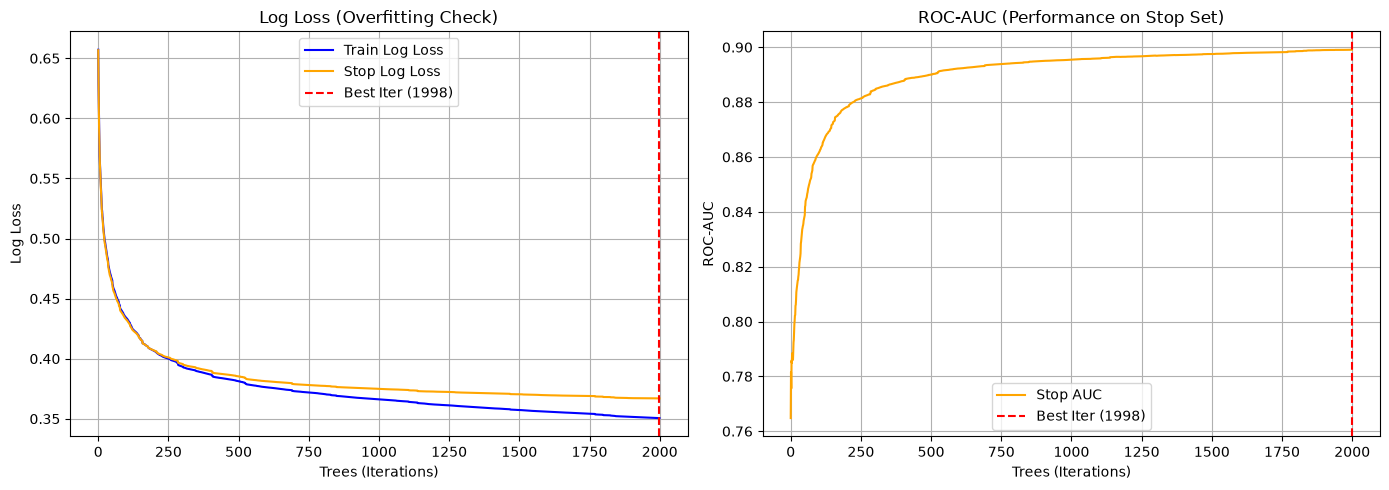

Calibrating Probabilities...

Evaluating Model on Dual Test Sets...
--- Model Performance Summary ---
Random Test     | ROC-AUC: 0.8990 | Log Loss: 0.3668 | Brier Score: 0.1200
OOT Test        | ROC-AUC: 0.7382 | Log Loss: 2.3621 | Brier Score: 0.3990

Temporal Degradation Penalty (AUC Drop): 0.1608
*(Both splits are order-grouped and label-mature. A large drop now means real
  behavioural/processor drift between the training period and OOT window.)*


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier, Pool

sampled_df = df

# Must match the DATEDIFF threshold in the training SQL's in-flight filter
MATURITY_DAYS = 30

# =====================================================================
# 1. Base Filtering and Sorting
# =====================================================================
sampled_df['LAST_DECLINE_CODE'] = sampled_df['LAST_DECLINE_CODE'].astype(str)
sampled_df['DECLINE_FAMILY'] = sampled_df['LAST_DECLINE_CODE'].str[0]

sampled_df['TRANSACTION_DATETIME'] = pd.to_datetime(sampled_df['TRANSACTION_DATETIME'])

# Sort ascending to guarantee Past predicts Future
sampled_df = sampled_df.sort_values('TRANSACTION_DATETIME').reset_index(drop=True)

# =====================================================================
# 1b. Invoice resolution timing  
# =====================================================================

print("Computing invoice resolution times...")

invoice_times = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    INVOICE_START=('TRANSACTION_DATETIME', 'min'),
    INVOICE_LAST_TXN=('TRANSACTION_DATETIME', 'max'),
    IS_EVENTUALLY_SUCCESSFUL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
)

first_accept = (
    sampled_df.loc[sampled_df['TRANSACTION_STATUS'] == 'accepted']
              .groupby('INVOICE_ID')['TRANSACTION_DATETIME'].min()
)

invoice_times['RESOLVED_AT'] = first_accept.reindex(invoice_times.index).where(
    invoice_times['IS_EVENTUALLY_SUCCESSFUL'] == 1,
    invoice_times['INVOICE_START'] + pd.Timedelta(days=MATURITY_DAYS)
)

if invoice_times['RESOLVED_AT'].isna().any():
    raise ValueError(
        f"{invoice_times['RESOLVED_AT'].isna().sum()} invoices are labelled successful "
        "but have no accepted transaction. Did the != 'accepted' filter get left in the SQL?"
    )

sampled_df = sampled_df.merge(
    invoice_times[['INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']],
    left_on='INVOICE_ID', right_index=True, how='left'
)

# Now drop the accepted rows -- at serving time the model only ever scores declines.
#sampled_df = sampled_df[sampled_df['TRANSACTION_STATUS'] != 'accepted'].reset_index(drop=True)
print(f"  {len(sampled_df):,} rows | {sampled_df['INVOICE_ID'].nunique():,} invoices "
      f"| {sampled_df['ORDER_ID'].nunique():,} orders")

# =======================================================================
# 2. Data Processing & Pre-Split Vectorized I
# =======================================================================
print("Processing and Imputing Data...")
drop_cols = ['ORDER_ID', 'INVOICE_ID', 'TRANSACTION_ID', 'TRANSACTION_DATETIME',
             'IS_EVENTUALLY_SUCCESSFUL', 'TRANSACTION_STATUS',
             'INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']

# Separate text features from standard categorical features for better string processing
text_features = [col for col in ['SUPER_PARTNER_ID_NAME', 'BANK'] if col in sampled_df.columns]

# Get remaining categorical features (Using errors='ignore' safely)
cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c not in text_features]

# Vectorized Imputation BEFORE the split (Massive speedup)
sampled_df[cat_features + text_features] = sampled_df[cat_features + text_features].fillna('unknown').astype(str)

# Get purely numeric feature columns (excluding drops and target)
numeric_cols = sampled_df.columns.difference(cat_features + text_features + drop_cols)
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(-1)

# =====================================================================
# 3. Hybrid Split (As-Of-Date OOT + Order-Grouped Random)
# =====================================================================
print("Splitting data (As-Of OOT + Order-Grouped Random)...")

ASOF_DATE = pd.Timestamp('2026-01-15')   # "retrain the model on this date"
OOT_END   = pd.Timestamp('2026-03-01')   # MUST be <= max ORDER_DATE in the extract

invoice_elig = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    RESOLVED_AT=('RESOLVED_AT', 'first'),
    INVOICE_LAST_TXN=('INVOICE_LAST_TXN', 'first'),
)
eligible_invoices = invoice_elig.index[
    (invoice_elig['RESOLVED_AT'] < ASOF_DATE) &
    (invoice_elig['INVOICE_LAST_TXN'] < ASOF_DATE)
]

past_data = sampled_df[
    sampled_df['INVOICE_ID'].isin(eligible_invoices) &
    (sampled_df['TRANSACTION_DATETIME'] < ASOF_DATE)
].copy()

oot_test_df = sampled_df[
    (sampled_df['TRANSACTION_DATETIME'] >= ASOF_DATE) &
    (sampled_df['TRANSACTION_DATETIME'] < OOT_END)
].copy()

assert not (set(past_data['INVOICE_ID']) & set(oot_test_df['INVOICE_ID'])), \
    "invoices straddle the as-of boundary"

print(f"  past_data   : {len(past_data):>9,} rows | {past_data['ORDER_ID'].nunique():>7,} orders")
print(f"  oot_test_df : {len(oot_test_df):>9,} rows | {oot_test_df['ORDER_ID'].nunique():>7,} orders")
print(f"  orders in both (new invoices, expected): "
      f"{len(set(past_data['ORDER_ID']) & set(oot_test_df['ORDER_ID'])):,}")
print(f"  dropped (unresolved at ASOF / beyond OOT_END): "
      f"{len(sampled_df) - len(past_data) - len(oot_test_df):,} rows")

# --- FIX 1: order-grouped assignment --------------------------------------------
# hashlib rather than hash(): Python salts str hashing per process, so hash() would
# reshuffle orders across splits on every run. This assignment is stable, and stays
# stable when new orders are added next month.
def order_hash_frac(order_ids, salt='retry_cutoff_v1'):
    return np.array([
        int(hashlib.md5(f'{salt}:{o}'.encode()).hexdigest()[:16], 16) / 2**64
        for o in order_ids
    ])

unique_orders = past_data['ORDER_ID'].unique()
order_frac = pd.Series(order_hash_frac(unique_orders), index=unique_orders)
row_frac = past_data['ORDER_ID'].map(order_frac)

# Same 75 / 10 / 10 / 5 boundaries as before -- but over ORDERS, not rows.
train_df       = past_data[row_frac < 0.75].copy()
stop_df        = past_data[(row_frac >= 0.75) & (row_frac < 0.85)].copy()
calib_df       = past_data[(row_frac >= 0.85) & (row_frac < 0.95)].copy()
random_test_df = past_data[row_frac >= 0.95].copy()

for _name, _part in [('train_df', train_df), ('stop_df', stop_df),
                     ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    print(f"  {_name:<15}: {len(_part):>9,} rows | {_part['ORDER_ID'].nunique():>7,} orders "
          f"| base rate {_part['IS_EVENTUALLY_SUCCESSFUL'].mean():.4f}")

for _a, _b in [('train_df', train_df), ('stop_df', stop_df),
               ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    for _c, _d in [('train_df', train_df), ('stop_df', stop_df),
                   ('calib_df', calib_df), ('random_test_df', random_test_df)]:
        if _a < _c:
            assert not (set(_b['ORDER_ID']) & set(_d['ORDER_ID'])), f"{_a}/{_c} share orders"
print("  [ok] no ORDER_ID spans two splits")

# 4. Separate X and y (Using errors='ignore' safely)
X_train, y_train = train_df.drop(columns=drop_cols, errors='ignore'), train_df['IS_EVENTUALLY_SUCCESSFUL']
X_stop,  y_stop  = stop_df.drop(columns=drop_cols, errors='ignore'),  stop_df['IS_EVENTUALLY_SUCCESSFUL']
X_calib, y_calib = calib_df.drop(columns=drop_cols, errors='ignore'), calib_df['IS_EVENTUALLY_SUCCESSFUL']

X_random_test, y_random_test = random_test_df.drop(columns=drop_cols, errors='ignore'), random_test_df['IS_EVENTUALLY_SUCCESSFUL']
X_oot_test,    y_oot_test    = oot_test_df.drop(columns=drop_cols, errors='ignore'),    oot_test_df['IS_EVENTUALLY_SUCCESSFUL']

# =====================================================================
# 4. Create Memory-Efficient CatBoost Pools
# =====================================================================
print("Building data pools...")
train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
stop_pool  = Pool(X_stop,  y_stop,  cat_features=cat_features, text_features=text_features)

# =====================================================================
# 5. Base Model Definition
# =====================================================================
print("Training Base Model...")
base_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.1,          # Updated Learning Rate
    depth=6,
    task_type="CPU",
    eval_metric='Logloss',
    custom_metric=['AUC'],
    l2_leaf_reg=6,
    thread_count=-1,
    early_stopping_rounds=100,
    verbose=50,
    random_state=42,
    cat_features=cat_features,
    text_features=text_features
)

# Train the model, strictly using the Stop pool
base_model.fit(train_pool, eval_set=stop_pool)

# =====================================================================
# 6. In-Flight Overfitting Diagnostic Plot
# =====================================================================
print("Plotting Learning Curves...")
history = base_model.evals_result_
iterations_range = range(len(history['learn']['Logloss']))
best_iter = base_model.get_best_iteration()

# Safely locate the validation dictionary key
val_key = 'validation' if 'validation' in history else 'validation_0'

plt.figure(figsize=(14, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(iterations_range, history['learn']['Logloss'], label='Train Log Loss', color='blue')
plt.plot(iterations_range, history[val_key]['Logloss'], label='Stop Log Loss', color='orange')
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
plt.title('Log Loss (Overfitting Check)')
plt.xlabel('Trees (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

# Plot ROC-AUC (Fixing the AUC KeyError by ignoring Train AUC)
plt.subplot(1, 2, 2)
if 'AUC' in history[val_key]:
    plt.plot(iterations_range, history[val_key]['AUC'], label='Stop AUC', color='orange')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
    plt.title('ROC-AUC (Performance on Stop Set)')
    plt.xlabel('Trees (Iterations)')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True)
else:
    plt.title('AUC not tracked')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. Probability Calibration
# =====================================================================
print("Calibrating Probabilities...")
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic'
)
calibrated_model.fit(X_calib, y_calib)

# =====================================================================
# 8. Final Dual-Evaluation (Random vs. Chronological)
# =====================================================================
print("\nEvaluating Model on Dual Test Sets...")

def evaluate_split(split_name, model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    brier = brier_score_loss(y, y_prob)
    print(f"{split_name: <15} | ROC-AUC: {auc:.4f} | Log Loss: {loss:.4f} | Brier Score: {brier:.4f}")
    return y_prob

print("--- Model Performance Summary ---")
# 1. Unseen ORDERS from the same period as training -> generalization to new customers.
random_probs = evaluate_split("Random Test", calibrated_model, X_random_test, y_random_test)

# 2. The strict future -> what the model would actually have scored after ASOF_DATE.
oot_probs    = evaluate_split("OOT Test", calibrated_model, X_oot_test, y_oot_test)

# Calculate the Degradation Penalty
auc_drop = roc_auc_score(y_random_test, random_probs) - roc_auc_score(y_oot_test, oot_probs)
print(f"\nTemporal Degradation Penalty (AUC Drop): {auc_drop:.4f}")
# CHANGED: both sides are now order-grouped and label-mature, so this gap is no longer
# contaminated by row duplication or by lifecycle-tail enrichment. What remains is
# genuine drift between the training period and the deployment window.
print("*(Both splits are order-grouped and label-mature. A large drop now means real")
print("  behavioural/processor drift between the training period and OOT window.)*")

In [ ]:
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

# 2. Package the model and the exact feature lists into one dictionary
# This ensures your prediction script applies the exact same preprocessing
model_artifact = {
    'model': calibrated_model,
    'cat_features': cat_features,
    'text_features': text_features,
    'drop_cols': drop_cols,
    'asof_date': ASOF_DATE,      # CHANGED: what the model knew, and when
    'oot_end': OOT_END,
}

# 3. Save the artifact to the script's directory
joblib.dump(model_artifact, model_path)

print(f"Model artifact successfully saved to: {model_path}")

Model artifact successfully saved to: /Users/amanda.huang/NIC/amanda_projects/Early_Retry_Cutoffs/calibrated_catboost_model.joblib


In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator

In [ ]:
# Start fetching data directly from Snowflake
ctx = snowflake.connector.connect(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
    warehouse='COMPUTE_WH',
    schema='EARLY_RETRY_CUTOFF'
)


# 2. Create a cursor and execute
cur = ctx.cursor()
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_DATA")

# 3. Fetch directly to a Pandas DataFrame using Arrow
# This is drastically faster than pd.read_sql()
df = cur.fetch_pandas_all()

In [ ]:
import pandas as pd
import numpy as np
import json
import re
import hashlib                      # CHANGED: stable order-level split assignment
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pytz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from catboost import CatBoostClassifier
import os
import joblib
from sklearn.frozen import FrozenEstimator
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool

Computing invoice resolution times...
  33,085,680 rows | 4,738,235 invoices | 1,867,180 orders
Processing and Imputing Data...


<ipython-input-4-8f5e934d23dd>:69: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()


Splitting data (As-Of OOT + Order-Grouped Random)...
  past_data   : 2,671,816 rows | 701,618 orders
  oot_test_df : 11,043,395 rows | 1,312,414 orders
  orders in both (new invoices, expected): 325,803
  dropped (unresolved at ASOF / beyond OOT_END): 19,370,469 rows
  train_df       : 2,004,846 rows | 526,243 orders | base rate 0.6657
  stop_df        :   267,670 rows |  69,986 orders | base rate 0.6707
  calib_df       :   264,346 rows |  70,085 orders | base rate 0.6725
  random_test_df :   134,954 rows |  35,304 orders | base rate 0.6694
  [ok] no ORDER_ID spans two splits
Building data pools...
Training Base Model...
0:	learn: 0.6546121	test: 0.6541710	best: 0.6541710 (0)	total: 1.62s	remaining: 21m 36s
50:	learn: 0.4502357	test: 0.4481959	best: 0.4481959 (50)	total: 1m 7s	remaining: 16m 27s
100:	learn: 0.4212802	test: 0.4200571	best: 0.4200571 (100)	total: 2m 6s	remaining: 14m 37s
150:	learn: 0.4054228	test: 0.4051374	best: 0.4051374 (150)	total: 3m 5s	remaining: 13m 18s
200:	lea

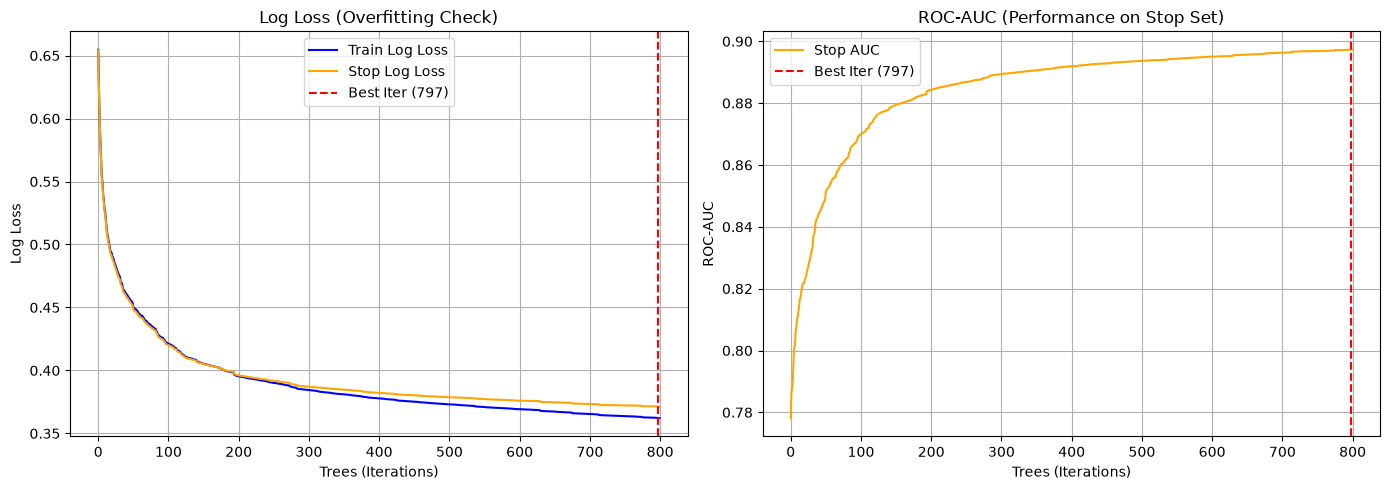

Calibrating Probabilities...

Evaluating Model on Dual Test Sets...
--- Model Performance Summary ---
Random Test     | ROC-AUC: 0.8974 | Log Loss: 0.3700 | Brier Score: 0.1210
OOT Test        | ROC-AUC: 0.7372 | Log Loss: 2.3256 | Brier Score: 0.3941

Temporal Degradation Penalty (AUC Drop): 0.1602
*(Both splits are order-grouped and label-mature. A large drop now means real
  behavioural/processor drift between the training period and OOT window.)*


In [ ]:
sampled_df = df

# Must match the DATEDIFF threshold in the training SQL's in-flight filter
MATURITY_DAYS = 30

# =====================================================================
# 1. Base Filtering and Sorting
# =====================================================================
sampled_df['LAST_DECLINE_CODE'] = sampled_df['LAST_DECLINE_CODE'].astype(str)
sampled_df['DECLINE_FAMILY'] = sampled_df['LAST_DECLINE_CODE'].str[0]

sampled_df['TRANSACTION_DATETIME'] = pd.to_datetime(sampled_df['TRANSACTION_DATETIME'])

# Sort ascending to guarantee Past predicts Future
sampled_df = sampled_df.sort_values('TRANSACTION_DATETIME').reset_index(drop=True)

# =====================================================================
# 1b. Invoice resolution timing  
# =====================================================================

print("Computing invoice resolution times...")

invoice_times = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    INVOICE_START=('TRANSACTION_DATETIME', 'min'),
    INVOICE_LAST_TXN=('TRANSACTION_DATETIME', 'max'),
    IS_EVENTUALLY_SUCCESSFUL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
)

first_accept = (
    sampled_df.loc[sampled_df['TRANSACTION_STATUS'] == 'accepted']
              .groupby('INVOICE_ID')['TRANSACTION_DATETIME'].min()
)

invoice_times['RESOLVED_AT'] = first_accept.reindex(invoice_times.index).where(
    invoice_times['IS_EVENTUALLY_SUCCESSFUL'] == 1,
    invoice_times['INVOICE_START'] + pd.Timedelta(days=MATURITY_DAYS)
)

if invoice_times['RESOLVED_AT'].isna().any():
    raise ValueError(
        f"{invoice_times['RESOLVED_AT'].isna().sum()} invoices are labelled successful "
        "but have no accepted transaction. Did the != 'accepted' filter get left in the SQL?"
    )

sampled_df = sampled_df.merge(
    invoice_times[['INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']],
    left_on='INVOICE_ID', right_index=True, how='left'
)

# Now drop the accepted rows -- at serving time the model only ever scores declines.
#sampled_df = sampled_df[sampled_df['TRANSACTION_STATUS'] != 'accepted'].reset_index(drop=True)
print(f"  {len(sampled_df):,} rows | {sampled_df['INVOICE_ID'].nunique():,} invoices "
      f"| {sampled_df['ORDER_ID'].nunique():,} orders")

# =======================================================================
# 2. Data Processing & Pre-Split Vectorized I
# =======================================================================
print("Processing and Imputing Data...")
drop_cols = ['ORDER_ID', 'INVOICE_ID', 'TRANSACTION_ID', 'TRANSACTION_DATETIME',
             'IS_EVENTUALLY_SUCCESSFUL', 'TRANSACTION_STATUS',
             'INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']

# Separate text features from standard categorical features for better string processing
text_features = [col for col in ['SUPER_PARTNER_ID_NAME', 'BANK'] if col in sampled_df.columns]

# Get remaining categorical features (Using errors='ignore' safely)
cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c not in text_features]

# Vectorized Imputation BEFORE the split (Massive speedup)
sampled_df[cat_features + text_features] = sampled_df[cat_features + text_features].fillna('unknown').astype(str)

# Get purely numeric feature columns (excluding drops and target)
numeric_cols = sampled_df.columns.difference(cat_features + text_features + drop_cols)
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(-1)

# =====================================================================
# 3. Hybrid Split (As-Of-Date OOT + Order-Grouped Random)
# =====================================================================
print("Splitting data (As-Of OOT + Order-Grouped Random)...")

ASOF_DATE = pd.Timestamp('2026-01-15')   # "retrain the model on this date"
OOT_END   = pd.Timestamp('2026-03-01')   # MUST be <= max ORDER_DATE in the extract

invoice_elig = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    RESOLVED_AT=('RESOLVED_AT', 'first'),
    INVOICE_LAST_TXN=('INVOICE_LAST_TXN', 'first'),
)
eligible_invoices = invoice_elig.index[
    (invoice_elig['RESOLVED_AT'] < ASOF_DATE) &
    (invoice_elig['INVOICE_LAST_TXN'] < ASOF_DATE)
]

past_data = sampled_df[
    sampled_df['INVOICE_ID'].isin(eligible_invoices) &
    (sampled_df['TRANSACTION_DATETIME'] < ASOF_DATE)
].copy()

oot_test_df = sampled_df[
    (sampled_df['TRANSACTION_DATETIME'] >= ASOF_DATE) &
    (sampled_df['TRANSACTION_DATETIME'] < OOT_END)
].copy()

assert not (set(past_data['INVOICE_ID']) & set(oot_test_df['INVOICE_ID'])), \
    "invoices straddle the as-of boundary"

print(f"  past_data   : {len(past_data):>9,} rows | {past_data['ORDER_ID'].nunique():>7,} orders")
print(f"  oot_test_df : {len(oot_test_df):>9,} rows | {oot_test_df['ORDER_ID'].nunique():>7,} orders")
print(f"  orders in both (new invoices, expected): "
      f"{len(set(past_data['ORDER_ID']) & set(oot_test_df['ORDER_ID'])):,}")
print(f"  dropped (unresolved at ASOF / beyond OOT_END): "
      f"{len(sampled_df) - len(past_data) - len(oot_test_df):,} rows")

# --- FIX 1: order-grouped assignment --------------------------------------------
# hashlib rather than hash(): Python salts str hashing per process, so hash() would
# reshuffle orders across splits on every run. This assignment is stable, and stays
# stable when new orders are added next month.
def order_hash_frac(order_ids, salt='retry_cutoff_v1'):
    return np.array([
        int(hashlib.md5(f'{salt}:{o}'.encode()).hexdigest()[:16], 16) / 2**64
        for o in order_ids
    ])

unique_orders = past_data['ORDER_ID'].unique()
order_frac = pd.Series(order_hash_frac(unique_orders), index=unique_orders)
row_frac = past_data['ORDER_ID'].map(order_frac)

# Same 75 / 10 / 10 / 5 boundaries as before -- but over ORDERS, not rows.
train_df       = past_data[row_frac < 0.75].copy()
stop_df        = past_data[(row_frac >= 0.75) & (row_frac < 0.85)].copy()
calib_df       = past_data[(row_frac >= 0.85) & (row_frac < 0.95)].copy()
random_test_df = past_data[row_frac >= 0.95].copy()

for _name, _part in [('train_df', train_df), ('stop_df', stop_df),
                     ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    print(f"  {_name:<15}: {len(_part):>9,} rows | {_part['ORDER_ID'].nunique():>7,} orders "
          f"| base rate {_part['IS_EVENTUALLY_SUCCESSFUL'].mean():.4f}")

for _a, _b in [('train_df', train_df), ('stop_df', stop_df),
               ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    for _c, _d in [('train_df', train_df), ('stop_df', stop_df),
                   ('calib_df', calib_df), ('random_test_df', random_test_df)]:
        if _a < _c:
            assert not (set(_b['ORDER_ID']) & set(_d['ORDER_ID'])), f"{_a}/{_c} share orders"
print("  [ok] no ORDER_ID spans two splits")

# 4. Separate X and y (Using errors='ignore' safely)
X_train, y_train = train_df.drop(columns=drop_cols, errors='ignore'), train_df['IS_EVENTUALLY_SUCCESSFUL']
X_stop,  y_stop  = stop_df.drop(columns=drop_cols, errors='ignore'),  stop_df['IS_EVENTUALLY_SUCCESSFUL']
X_calib, y_calib = calib_df.drop(columns=drop_cols, errors='ignore'), calib_df['IS_EVENTUALLY_SUCCESSFUL']

X_random_test, y_random_test = random_test_df.drop(columns=drop_cols, errors='ignore'), random_test_df['IS_EVENTUALLY_SUCCESSFUL']
X_oot_test,    y_oot_test    = oot_test_df.drop(columns=drop_cols, errors='ignore'),    oot_test_df['IS_EVENTUALLY_SUCCESSFUL']

# =====================================================================
# 4. Create Memory-Efficient CatBoost Pools
# =====================================================================
print("Building data pools...")
train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
stop_pool  = Pool(X_stop,  y_stop,  cat_features=cat_features, text_features=text_features)

# =====================================================================
# 5. Base Model Definition
# =====================================================================
print("Training Base Model...")
base_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.1,          # Updated Learning Rate
    depth=7,
    task_type="CPU",
    eval_metric='Logloss',
    custom_metric=['AUC'],
    l2_leaf_reg=6,
    thread_count=-1,
    early_stopping_rounds=50,
    verbose=50,
    random_state=42,
    cat_features=cat_features,
    text_features=text_features
)

# Train the model, strictly using the Stop pool
base_model.fit(train_pool, eval_set=stop_pool)

# =====================================================================
# 6. In-Flight Overfitting Diagnostic Plot
# =====================================================================
print("Plotting Learning Curves...")
history = base_model.evals_result_
iterations_range = range(len(history['learn']['Logloss']))
best_iter = base_model.get_best_iteration()

# Safely locate the validation dictionary key
val_key = 'validation' if 'validation' in history else 'validation_0'

plt.figure(figsize=(14, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(iterations_range, history['learn']['Logloss'], label='Train Log Loss', color='blue')
plt.plot(iterations_range, history[val_key]['Logloss'], label='Stop Log Loss', color='orange')
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
plt.title('Log Loss (Overfitting Check)')
plt.xlabel('Trees (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

# Plot ROC-AUC (Fixing the AUC KeyError by ignoring Train AUC)
plt.subplot(1, 2, 2)
if 'AUC' in history[val_key]:
    plt.plot(iterations_range, history[val_key]['AUC'], label='Stop AUC', color='orange')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
    plt.title('ROC-AUC (Performance on Stop Set)')
    plt.xlabel('Trees (Iterations)')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True)
else:
    plt.title('AUC not tracked')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. Probability Calibration
# =====================================================================
print("Calibrating Probabilities...")
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic'
)
calibrated_model.fit(X_calib, y_calib)

# =====================================================================
# 8. Final Dual-Evaluation (Random vs. Chronological)
# =====================================================================
print("\nEvaluating Model on Dual Test Sets...")

def evaluate_split(split_name, model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    brier = brier_score_loss(y, y_prob)
    print(f"{split_name: <15} | ROC-AUC: {auc:.4f} | Log Loss: {loss:.4f} | Brier Score: {brier:.4f}")
    return y_prob

print("--- Model Performance Summary ---")
# 1. Unseen ORDERS from the same period as training -> generalization to new customers.
random_probs = evaluate_split("Random Test", calibrated_model, X_random_test, y_random_test)

# 2. The strict future -> what the model would actually have scored after ASOF_DATE.
oot_probs    = evaluate_split("OOT Test", calibrated_model, X_oot_test, y_oot_test)

# Calculate the Degradation Penalty
auc_drop = roc_auc_score(y_random_test, random_probs) - roc_auc_score(y_oot_test, oot_probs)
print(f"\nTemporal Degradation Penalty (AUC Drop): {auc_drop:.4f}")
# CHANGED: both sides are now order-grouped and label-mature, so this gap is no longer
# contaminated by row duplication or by lifecycle-tail enrichment. What remains is
# genuine drift between the training period and the deployment window.
print("*(Both splits are order-grouped and label-mature. A large drop now means real")
print("  behavioural/processor drift between the training period and OOT window.)*")

In [ ]:
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

# 2. Package the model and the exact feature lists into one dictionary
# This ensures your prediction script applies the exact same preprocessing
model_artifact = {
    'model': calibrated_model,
    'cat_features': cat_features,
    'text_features': text_features,
    'drop_cols': drop_cols,
    'asof_date': ASOF_DATE,      # CHANGED: what the model knew, and when
    'oot_end': OOT_END,
}

# 3. Save the artifact to the script's directory
joblib.dump(model_artifact, model_path)

print(f"Model artifact successfully saved to: {model_path}")

Model artifact successfully saved to: /Users/amanda.huang/NIC/amanda_projects/Early_Retry_Cutoffs/calibrated_catboost_model.joblib


In [ ]:
# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active in your environment
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_062025 ")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
# CHANGED: mirrors section 1 -- DECLINE_FAMILY comes from LAST_DECLINE_CODE now.
# Without this the model's DECLINE_FAMILY column is missing and the reindex below
# raises a KeyError.
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    # Grab the wrapper from the first fold
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    # Fallback if calibrated without CV somehow
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator (Checking common attribute names)
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class (IS_EVENTUALLY_SUCCESSFUL = 1)
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_order_level_confusion_matrix(order_ids, y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact at the ORDER level.
    Rules:
    - If Actual=1: If ANY transaction is predicted 0 (cut off), order is False Negative.
                   Otherwise (ALL predicted 1), it's a True Positive.
    - If Actual=0: If ANY transaction is predicted 1 (allowed), order is False Positive.
                   Otherwise (ALL predicted 0), it's a True Negative.
    """
    # 1. Create a temporary dataframe to group predictions by order
    df = pd.DataFrame({
        'order_id': order_ids,
        'y_true': y_true,
        'y_pred': (y_probs >= threshold).astype(int)
    })

    # 2. Group by order_id and evaluate the predictions
    grouped = df.groupby('order_id').agg(
        y_true=('y_true', 'first'),                     # Actual outcome is the same for the whole order
        has_pred_0=('y_pred', lambda x: (x == 0).any()), # Did we predict 0 for ANY transaction?
        has_pred_1=('y_pred', lambda x: (x == 1).any())  # Did we predict 1 for ANY transaction?
    )

    # 3. Apply the Business Logic to categorize each order
    FN = ((grouped['y_true'] == 1) & (grouped['has_pred_0'])).sum()
    TP = ((grouped['y_true'] == 1) & (~grouped['has_pred_0'])).sum()
    FP = ((grouped['y_true'] == 0) & (grouped['has_pred_1'])).sum()
    TN = ((grouped['y_true'] == 0) & (~grouped['has_pred_1'])).sum()

    # 4. Build the Confusion Matrix array and calculate percentages
    cm = np.array([[TN, FP], 
                   [FN, TP]])
    cm_percentages = cm / np.sum(cm)

    labels = [f"{count:,}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Order-Level Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('Order-Level Prediction Outcome', fontsize=12, labelpad=10)
    plt.ylabel('Actual Order Outcome', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    print(f"\n--- Order-Level Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"Total Unique Orders:  {np.sum(cm):,}")
    print(f"True Negatives (TN):  {TN:,} ({cm_percentages[0,0]:.1%}) -> Entire bad order correctly cut off")
    print(f"False Positives (FP): {FP:,} ({cm_percentages[0,1]:.1%}) -> Allowed at least one retry on a doomed order")
    print(f"False Negatives (FN): {FN:,} ({cm_percentages[1,0]:.1%}) -> Killed a good order prematurely (Missed revenue!)")
    print(f"True Positives (TP):  {TP:,} ({cm_percentages[1,1]:.1%}) -> Allowed all retries, successfully collected")

print("\nGenerating Order-Level Confusion Matrices...")

# 2. Evaluate the Random Holdout Test Set (In-Sample)
plot_order_level_confusion_matrix(
    order_ids=random_test_df['ORDER_ID'].values, 
    y_true=y_true_062025, 
    y_probs=y_probs_062025, 
    threshold=0.03, 
    dataset_name="Random Test Set (In-Sample)"
)


Generating Order-Level Confusion Matrices...


NameError: name 'y_true_062025' is not defined

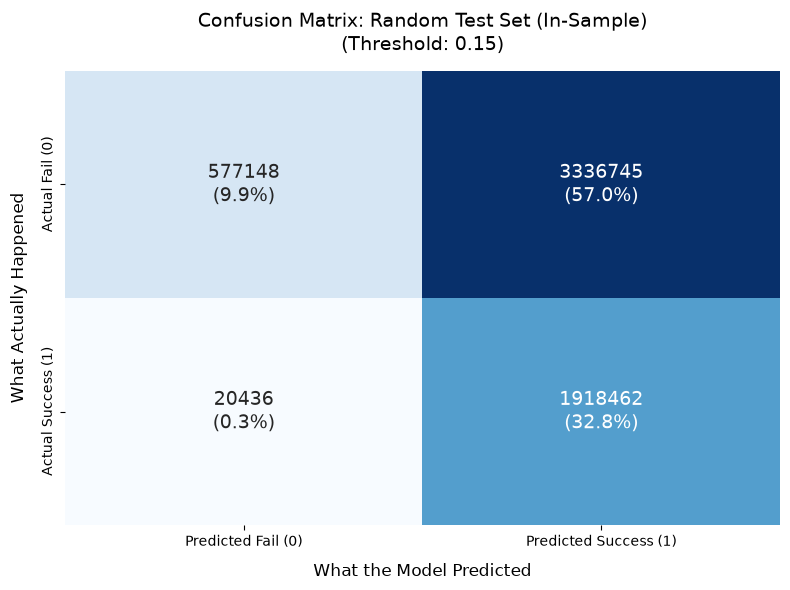


--- Confusion Matrix Breakdown: Random Test Set (In-Sample) (Threshold: 0.15) ---
True Negatives (TN):  577,148 (9.9%) -> Correctly cut off
False Positives (FP): 3,336,745 (57.0%) -> Wasted $0.10 retry
False Negatives (FN): 20,436 (0.3%) -> Missed revenue!
True Positives (TP):  1,918,462 (32.8%) -> Successfully collected


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_business_confusion_matrix(y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact based on model predictions and a given threshold.
    """
    # 2. Convert probabilities to hard predictions
    y_pred = (y_probs >= threshold).astype(int)

    # 3. Calculate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 4. Calculate Percentages and Create Custom Labels ugk 
    # Divide each cell by the total number of predictions to get the % of total
    cm_percentages = cm / np.sum(cm)

    # Zip the raw counts and the percentages together into a formatted string
    labels = [f"{count}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    # Reshape the list of strings back into a 2x2 grid to match the heatmap
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))

    # Notice we changed annot=labels and fmt='' (empty string) so Seaborn accepts our custom text
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
    plt.ylabel('What Actually Happened', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- Confusion Matrix Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"True Negatives (TN):  {tn:,} ({cm_percentages[0,0]:.1%}) -> Correctly cut off")
    print(f"False Positives (FP): {fp:,} ({cm_percentages[0,1]:.1%}) -> Wasted $0.10 retry")
    print(f"False Negatives (FN): {fn:,} ({cm_percentages[1,0]:.1%}) -> Missed revenue!")
    print(f"True Positives (TP):  {tp:,} ({cm_percentages[1,1]:.1%}) -> Successfully collected")

# =====================================================================
# Generate the Confusion Matrices using variables from your training script
# ====================================================================

# Check the Random Holdout Test Set
y_true_062025 = df_pred['IS_EVENTUALLY_SUCCESSFUL'].values
y_probs_062025 = df_pred['SUCCESS_PROBABILITY'].values

plot_business_confusion_matrix(y_true=y_true_062025, 
                               y_probs=y_probs_062025, 
                               threshold=0.15, 
                               dataset_name="Random Test Set (In-Sample)")

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       13552                10587      7239.2        4477.35       2761.85
model p < 0.02       33888                25714     22585.0       19225.57       3359.43
model p < 0.03       41160                31168     28677.9       26660.82       2017.08
model p < 0.05       46664                35222     33563.4       31926.38       1637.02
 model p < 0.1       58743                43986     45764.4       47999.75      -2235.35
model p < 0.15       83187                61156     74315.5       94605.53     -20290.03
 model p < 0.2       89833                65790     82920.3      109250.57     -26330.27
 model p < 0.3      103805                75389    103798.7      146871.43     -43072.73
 model p < 0.4      124320                87667    142944.8      22

In [ ]:
# Starts from YOUR original calculation and applies my changes one at a time.
# The "Delta Net" column is the damage (or credit) attributable to that one change.

import pandas as pd
import numpy as np

RETRY_COST = 0.1
THRESHOLD = 0.05     # ablate at one fixed threshold
ECLTV_CAP = 20


def load_cltv(dedupe):
    """dedupe=False reproduces your original ecltv CTE (no GROUP BY)."""
    ecltv_cte = ("select order_id, max(cltv_pred_mean) as ecltv_1y "
                 "from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER group by 1") if dedupe else \
                ("select order_id, cltv_pred_mean as ecltv_1y "
                 "from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER")
    cur = ctx.cursor()
    cur.execute(f"""
    with ecltv as ({ecltv_cte}),
    tb as (
        select order_id,
               div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                             then transaction_amount else 0 end),
                    count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                        then order_id else null end)) as cltv_360,
               max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01' and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def build(df_pred, cltv_df):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(cltv_df, on='ORDER_ID', how='left', indicator='_src')
    df['NEVER_M0'] = df['_src'] == 'left_only'      # absent from tb => never signed up
    df = df.drop(columns='_src').sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])
    df['ORDER_MAX_RETRY'] = df.groupby('ORDER_ID')['RETRIES'].transform('max')
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def score(df, fill0, clip, gate, gain_mode, plus1):
    d = df.copy()
    if fill0:
        # your version: every missing CLTV becomes 0, including paying customers
        d['ECLTV_1Y'] = d['ECLTV_1Y'].fillna(0)
        d['CLTV_360'] = d['CLTV_360'].fillna(0)
    else:
        # mine: never-M0 are true zeros; made-M0-but-no-eCLTV stay NaN -> never cut
        d.loc[d['NEVER_M0'], ['CLTV_360', 'ECLTV_1Y']] = 0.0

    cut = (d[(d['SUCCESS_PROBABILITY'] < THRESHOLD) & (d['ECLTV_1Y'] < ECLTV_CAP)]
           .drop_duplicates('ORDER_ID', keep='first').copy())

    if gain_mode == 'attempts':
        cut['gain'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST   # pre-attempt by construction
    else:
        cut['gain'] = (cut['ORDER_MAX_RETRY'] - cut['RETRIES'] + int(plus1)) * RETRY_COST

    loss = cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']
    if clip:
        loss = loss.clip(lower=0)
    if gate:
        loss = loss.where(cut['IS_EVENTUALLY_SUCCESSFUL'] == 1, 0.0)
    cut['loss'] = loss
    cut['net'] = cut['gain'] - cut['loss']
    return cut


# --- Pre-flight: are the ingredients even in play? ---------------------------
cur = ctx.cursor()
cur.execute("""select count(*) as dupe_orders from (
                 select order_id from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
                 group by 1 having count(*) > 1)""")
dupes = cur.fetch_pandas_all().iloc[0, 0]

cltv_dedup = load_cltv(dedupe=True)
cltv_raw = load_cltv(dedupe=False)
base_dedup = build(df_pred, cltv_dedup)
base_raw = build(df_pred, cltv_raw)

n_orders = base_dedup['ORDER_ID'].nunique()
never_m0 = base_dedup.loc[base_dedup['NEVER_M0'], 'ORDER_ID'].nunique()
no_ecltv = base_dedup.loc[base_dedup['ECLTV_1Y'].isna() & ~base_dedup['NEVER_M0'], 'ORDER_ID'].nunique()
multi_inv = (base_dedup.groupby('ORDER_ID')['INVOICE_ID'].nunique() > 1).mean()

print("=" * 76)
print("PRE-FLIGHT -- how much can each change possibly matter?")
print("=" * 76)
print(f"  orders in FCT_ECLTV_ORDER with >1 row : {dupes:,}   <- if 0, the SQL dedupe is a no-op")
print(f"  orders that never made M0             : {never_m0:,} / {n_orders:,} ({never_m0/n_orders:.1%})")
print(f"    -> we AGREE on these (loss truly 0)")
print(f"  orders made M0 but no eCLTV row       : {no_ecltv:,} / {n_orders:,} ({no_ecltv/n_orders:.1%})")
print(f"    -> your fillna(0) marks these free to cut; I refuse to cut them")
print(f"  orders with >1 invoice                : {multi_inv:.1%}")
print(f"    -> only these can make the GAIN formulas diverge")

# --- Cumulative ablation -----------------------------------------------------
STEPS = [
    ('0. your original',              dict(dedupe=False, fill0=True,  clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('1. + dedupe ecltv (SQL)',       dict(dedupe=True,  fill0=True,  clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('2. + split the two NaN cases',  dict(dedupe=True,  fill0=False, clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('3. + clip loss at 0',           dict(dedupe=True,  fill0=False, clip=True,  gate=True,  gain_mode='order_max', plus1=False)),
    ('4. + drop success gate',        dict(dedupe=True,  fill0=False, clip=True,  gate=False, gain_mode='order_max', plus1=False)),
    ('5. + pre-attempt (+1)',         dict(dedupe=True,  fill0=False, clip=True,  gate=False, gain_mode='order_max', plus1=True)),
    ('6. + count order-wide attempts', dict(dedupe=True, fill0=False, clip=True,  gate=False, gain_mode='attempts',  plus1=True)),
]

rows, prev_net = [], None
for label, cfg in STEPS:
    base = base_dedup if cfg.pop('dedupe') else base_raw
    cut = score(base, **cfg)
    net = cut['net'].sum()
    rows.append({
        'Step': label,
        'Orders Cut': len(cut),
        'Gain': round(cut['gain'].sum(), 2),
        'Loss': round(cut['loss'].sum(), 2),
        'Net': round(net, 2),
        'Delta Net': '' if prev_net is None else round(net - prev_net, 2),
    })
    prev_net = net

ablation = pd.DataFrame(rows)
print("\n" + "=" * 76)
print(f"CUMULATIVE ABLATION  (threshold {THRESHOLD}, ECLTV cap {ECLTV_CAP})")
print("=" * 76)
print(ablation.to_string(index=False))
print("\n  Row 0 = your number. Row 6 = mine. The biggest |Delta Net| is your answer.")

# --- Where exactly does the gain diverge? ------------------------------------
final = score(base_dedup, fill0=False, clip=True, gate=False, gain_mode='attempts', plus1=True)
final['gain_yours'] = (final['ORDER_MAX_RETRY'] - final['RETRIES']) * RETRY_COST
final['n_invoices'] = final['ORDER_ID'].map(base_dedup.groupby('ORDER_ID')['INVOICE_ID'].nunique())
final['gain_diff'] = final['gain'] - final['gain_yours']

print("\n" + "=" * 76)
print("GAIN DIVERGENCE BY INVOICE COUNT")
print("=" * 76)
by_inv = final.groupby(final['n_invoices'].clip(upper=4)).agg(
    orders=('gain', 'size'), yours=('gain_yours', 'mean'),
    mine=('gain', 'mean'), total_diff=('gain_diff', 'sum'))
by_inv['ratio'] = (by_inv['mine'] / by_inv['yours']).round(2)
print(by_inv.round(2).to_string())
print("\n  Single-invoice orders should be ~1.0x (only the +1 differs).")
print("  Multi-invoice orders diverge because retry numbers restart at 0 each invoice,")
print("  so 'max retry - current retry' cannot see the invoices cancelling also kills.")

PRE-FLIGHT -- how much can each change possibly matter?
  orders in FCT_ECLTV_ORDER with >1 row : 0   <- if 0, the SQL dedupe is a no-op
  orders that never made M0             : 142,453 / 350,718 (40.6%)
    -> we AGREE on these (loss truly 0)
  orders made M0 but no eCLTV row       : 339 / 350,718 (0.1%)
    -> your fillna(0) marks these free to cut; I refuse to cut them
  orders with >1 invoice                : 41.5%
    -> only these can make the GAIN formulas diverge

CUMULATIVE ABLATION  (threshold 0.05, ECLTV cap 20)
                          Step  Orders Cut    Gain     Loss      Net Delta Net
              0. your original       46715 27184.1 21477.06  5707.04          
       1. + dedupe ecltv (SQL)       46715 27184.1 21477.06  5707.04       0.0
  2. + split the two NaN cases       46664 27130.7 21423.38  5707.32      0.28
           3. + clip loss at 0       46664 27130.7 21694.38  5436.32    -271.0
        4. + drop success gate       46664 27130.7 31926.38 -4795.68  -1023

In [ ]:
# Three candidates. This tells you which.
#   A: orders genuinely collect after a failed invoice   -> gate is wrong, loss is real
#   B: labels are wrong (accepted txn hidden by filters) -> loss real AND target corrupted
#   C: CLTV_360 counts money HIST cannot see             -> loss is phantom, gate masked it

import pandas as pd
import numpy as np

# =============================================================================
# TEST 1 -- how much collected money do the extract's filters hide?
# base_transactions requires retries IS NOT NULL AND transaction_type IN
# ('sale','capture'). Anything accepted outside that is invisible to
# HISTORICAL_COLLECTED_AMOUNT *and* to MAX(accepted) -- i.e. to the label.
# =============================================================================
cur = ctx.cursor()
cur.execute("""
select
    case when retries is null then 'retries IS NULL'
         when transaction_type not in ('sale','capture') then 'other transaction_type'
         else 'visible to extract' end          as bucket,
    transaction_type,
    count(*)                                     as txns,
    sum(iff(transaction_status='accepted',1,0))  as accepted_txns,
    round(sum(iff(transaction_status='accepted', transaction_amount, 0)), 2) as accepted_dollars
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where order_date >= '2025-06-01' and order_date < '2025-07-01'
group by 1, 2
order by accepted_dollars desc
""")
hidden = cur.fetch_pandas_all()
print("=" * 84)
print("TEST 1 -- collected money the extract cannot see")
print("=" * 84)
print(hidden.to_string(index=False))
vis = hidden.loc[hidden.BUCKET == 'visible to extract', 'ACCEPTED_DOLLARS'].sum()
inv = hidden.loc[hidden.BUCKET != 'visible to extract', 'ACCEPTED_DOLLARS'].sum()
print(f"\n  visible ${vis:,.0f} | INVISIBLE ${inv:,.0f} ({inv/(vis+inv):.1%} of all collections)")
print("  Any invisible dollars => CLTV_360 sees them, HIST does not, and MAX(accepted)")
print("  misses them too. That is hypothesis B/C, and it breaks the label as well.")

# =============================================================================
# TEST 2 -- per order: does CLTV_360 exceed everything the extract shows collected?
# If yes for nearly every order, the gap is an accounting artifact, not revenue.
# =============================================================================
extract_collected = (df_pred[df_pred['TRANSACTION_STATUS'] == 'accepted']
                     .groupby('ORDER_ID')['TRANSACTION_AMOUNT'].sum().rename('EXTRACT_COLLECTED'))

cmp = (load_cltv(dedupe=True).set_index('ORDER_ID')
       .join(extract_collected, how='inner'))
cmp['GAP'] = cmp['CLTV_360'] - cmp['EXTRACT_COLLECTED']

print("\n" + "=" * 84)
print("TEST 2 -- CLTV_360 minus what the extract says was collected, per order")
print("=" * 84)
print(cmp['GAP'].describe().round(2).to_string())
print(f"\n  orders with GAP > $0.01 : {(cmp['GAP'] > 0.01).mean():.1%}")
print(f"  median GAP              : ${cmp['GAP'].median():.2f}")
print(f"  GAP == a tight cluster? -> a fixed per-order charge the extract drops (the M0 trial)")
print("\n  GAP distribution:")
print(cmp['GAP'].round(0).value_counts().head(8).to_string())

# =============================================================================
# TEST 3 -- THE DECIDER. For the orders driving the $146k, is there actually an
# accepted transaction after the cutoff point, in the extract itself?
#   found => hypothesis A (real revenue after a failed invoice)
#   none  => hypothesis B/C (the money is only in CLTV_360, not in your data)
# =============================================================================
base = build(df_pred, load_cltv(dedupe=True))
base.loc[base['NEVER_M0'], ['CLTV_360', 'ECLTV_1Y']] = 0.0

cut = (base[(base['SUCCESS_PROBABILITY'] < 0.05) & (base['ECLTV_1Y'] < 20)]
       .drop_duplicates('ORDER_ID', keep='first').copy())
cut['loss'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

# the population the gate was hiding
hidden_loss = cut[(cut['IS_EVENTUALLY_SUCCESSFUL'] == 0) & (cut['loss'] > 0)]
print("\n" + "=" * 84)
print("TEST 3 -- the orders the gate was suppressing")
print("=" * 84)
print(f"  orders: {len(hidden_loss):,}   loss they carry: ${hidden_loss['loss'].sum():,.0f}")

# for each, is there an accepted txn in the extract after the cutoff datetime?
cutoff_at = hidden_loss.set_index('ORDER_ID')['TRANSACTION_DATETIME']
acc = df_pred[df_pred['TRANSACTION_STATUS'] == 'accepted'][['ORDER_ID', 'TRANSACTION_DATETIME', 'TRANSACTION_AMOUNT']]
acc = acc[acc['ORDER_ID'].isin(cutoff_at.index)].copy()
acc['CUTOFF_AT'] = acc['ORDER_ID'].map(cutoff_at)
after = acc[pd.to_datetime(acc['TRANSACTION_DATETIME']) > pd.to_datetime(acc['CUTOFF_AT'])]

n_with_real = after['ORDER_ID'].nunique()
print(f"  ...of which have a REAL accepted txn after the cutoff : {n_with_real:,} "
      f"({n_with_real/max(len(hidden_loss),1):.1%})")
print(f"  ...dollars actually collected after the cutoff        : ${after['TRANSACTION_AMOUNT'].sum():,.0f}")
print(f"  ...dollars CLTV_360 claims were lost                  : ${hidden_loss['loss'].sum():,.0f}")

ratio = after['TRANSACTION_AMOUNT'].sum() / max(hidden_loss['loss'].sum(), 1e-9)
print(f"\n  RATIO real/claimed = {ratio:.1%}")
print("    ~100% -> HYPOTHESIS A. Orders do survive failed invoices. Your gate is wrong,")
print("             the loss is real, and cutting at 0.05 destroys value.")
print("    ~0%   -> HYPOTHESIS B/C. The money exists only in CLTV_360, not in your")
print("             transactions. The loss is an accounting artifact -- and the same")
print("             filters that hide it also corrupt IS_EVENTUALLY_SUCCESSFUL.")

# =============================================================================
# TEST 4 -- if B: how many invoices are labelled failed but actually collected?
# =============================================================================
cur.execute("""
with filtered as (
    select invoice_id, max(iff(transaction_status='accepted',1,0)) as lbl
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where retries is not null and transaction_type in ('sale','capture')
      and order_date >= '2025-06-01' and order_date < '2025-07-01'
    group by 1
),
truth as (
    select invoice_id, max(iff(transaction_status='accepted',1,0)) as lbl
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where order_date >= '2025-06-01' and order_date < '2025-07-01'
    group by 1
)
select count(*) as invoices,
       sum(iff(f.lbl=0 and t.lbl=1,1,0)) as labelled_fail_but_paid,
       round(100*avg(iff(f.lbl=0 and t.lbl=1,1,0)), 3) as pct
from filtered f join truth t using (invoice_id)
""")
print("\n" + "=" * 84)
print("TEST 4 -- invoices labelled FAILED that actually collected")
print("=" * 84)
print(cur.fetch_pandas_all().to_string(index=False))
print("\n  Non-zero => your training target is wrong for these rows, and every model")
print("  metric so far was computed against a corrupted label.")

TEST 1 -- collected money the extract cannot see
                BUCKET TRANSACTION_TYPE    TXNS  ACCEPTED_TXNS  ACCEPTED_DOLLARS
    visible to extract             sale 6132755         807919        6837836.49
other transaction_type           refund   13046          12747         214221.77
other transaction_type             auth   27494          11878         184784.15
    visible to extract          capture    6889           4116          92930.54
other transaction_type          voidtxn    3229           2811          50605.15
other transaction_type      voidpreauth       1              1             12.49
       retries IS NULL              NaN    9965              0              0.00

  visible $6,930,767 | INVISIBLE $449,624 (6.1% of all collections)
  Any invisible dollars => CLTV_360 sees them, HIST does not, and MAX(accepted)
  misses them too. That is hypothesis B/C, and it breaks the label as well.

TEST 2 -- CLTV_360 minus what the extract says was collected, per order
count

In [ ]:
# Run after gate_diagnostic.py -- reuses hidden_loss, base, df_pred.

import pandas as pd

ids = hidden_loss['ORDER_ID'].tolist()
print(f"{len(ids):,} orders. First 20:")
print(ids[:20])

# --- per-invoice timeline for a few of them ---------------------------------
inv = (df_pred[df_pred['ORDER_ID'].isin(ids)]
       .assign(TRANSACTION_DATETIME=lambda d: pd.to_datetime(d['TRANSACTION_DATETIME']))
       .groupby(['ORDER_ID', 'INVOICE_ID'])
       .agg(INV_NO=('INVOICE_NUMBER', 'first'),
            FIRST_TXN=('TRANSACTION_DATETIME', 'min'),
            LAST_TXN=('TRANSACTION_DATETIME', 'max'),
            MAX_RETRY=('RETRIES', 'max'),
            LABEL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
            COLLECTED=('TRANSACTION_AMOUNT',
                       lambda s: s[df_pred.loc[s.index, 'TRANSACTION_STATUS'] == 'accepted'].sum()))
       .reset_index().sort_values(['ORDER_ID', 'FIRST_TXN']))

cut_at = hidden_loss.set_index('ORDER_ID')['TRANSACTION_DATETIME']
for oid in ids[:5]:
    print(f"\n--- order {oid} | cut at {pd.to_datetime(cut_at[oid])} ---")
    print(inv[inv['ORDER_ID'] == oid].drop(columns='ORDER_ID').to_string(index=False))

# --- THE question: sequential or overlapping? -------------------------------
# Was the later money collected by a LATER invoice (order survived the failure),
# or by an invoice already running ALONGSIDE the failing one (overlap)?
inv['PREV_LAST'] = inv.groupby('ORDER_ID')['LAST_TXN'].shift()
inv['OVERLAPS_PREV'] = inv['FIRST_TXN'] < inv['PREV_LAST']

print("\n" + "=" * 70)
print("Do this order's invoices run CONCURRENTLY?")
print("=" * 70)
print(f"  invoices starting before the previous one ended: "
      f"{inv['OVERLAPS_PREV'].mean():.1%}")
print(f"  orders with any overlap: "
      f"{inv.groupby('ORDER_ID')['OVERLAPS_PREV'].any().mean():.1%}")

# Of the money collected after the cutoff, which invoice did it come from?
paid_after = (df_pred[(df_pred['ORDER_ID'].isin(ids)) &
                      (df_pred['TRANSACTION_STATUS'] == 'accepted')]
              .assign(TRANSACTION_DATETIME=lambda d: pd.to_datetime(d['TRANSACTION_DATETIME'])))
paid_after['CUT_AT'] = pd.to_datetime(paid_after['ORDER_ID'].map(cut_at))
paid_after = paid_after[paid_after['TRANSACTION_DATETIME'] > paid_after['CUT_AT']]
paid_after['CUT_INV_NO'] = paid_after['ORDER_ID'].map(hidden_loss.set_index('ORDER_ID')['INVOICE_NUMBER'])

print(f"\n  money collected after cutoff, by invoice position:")
print(f"    from a LATER invoice   : ${paid_after.loc[paid_after['INVOICE_NUMBER'] > paid_after['CUT_INV_NO'], 'TRANSACTION_AMOUNT'].sum():,.0f}"
      f"   <- order survived the failed invoice")
print(f"    from the SAME invoice  : ${paid_after.loc[paid_after['INVOICE_NUMBER'] == paid_after['CUT_INV_NO'], 'TRANSACTION_AMOUNT'].sum():,.0f}"
      f"   <- should be $0: that invoice is labelled failed")
print(f"    from an EARLIER invoice: ${paid_after.loc[paid_after['INVOICE_NUMBER'] < paid_after['CUT_INV_NO'], 'TRANSACTION_AMOUNT'].sum():,.0f}"
      f"   <- only possible if invoices overlap")

10,240 orders. First 20:
[51463530, 51463546, 51463579, 51463665, 51463743, 51463771, 51463781, 51463800, 51463831, 51463840, 51463872, 51463883, 51463886, 51463887, 51463893, 51463926, 51463939, 51463972, 51464068, 51464243]

--- order 51463530 | cut at 2025-07-26 01:17:00 ---
 INVOICE_ID  INV_NO           FIRST_TXN            LAST_TXN  MAX_RETRY  LABEL  COLLECTED
  111537627       1 2025-06-08 08:00:08 2025-07-26 01:17:00         18      0        0.0

--- order 51463546 | cut at 2025-08-22 03:04:23 ---
 INVOICE_ID  INV_NO           FIRST_TXN            LAST_TXN  MAX_RETRY  LABEL  COLLECTED
  111537540       1 2025-06-08 08:00:07 2025-07-25 03:06:09         17      1       2.95
  113614921       2 2025-08-01 00:28:55 2025-10-24 03:06:55         30      0       0.00

--- order 51463579 | cut at 2025-06-13 01:50:23 ---
 INVOICE_ID  INV_NO           FIRST_TXN            LAST_TXN  MAX_RETRY  LABEL  COLLECTED
  111537567       1 2025-06-08 08:00:07 2025-07-26 01:41:15         18      0    

In [ ]:
_diff

array([False, False, False, ..., False, False, False], shape=(46664,))

In [ ]:
_diff

array([False, False, False, ..., False, False, False], shape=(46664,))

In [ ]:
_c

,ORDER_ID,INVOICE_ID,TRANSACTION_ID,TRANSACTION_DATETIME,INVOICE_NUMBER,RETRIES,TRANSACTION_STATUS,VERTICAL_TYPE,SUPER_PARTNER_ID_NAME,PROCESSOR_TYPE,...,RETRY_HOUR,SUPER_PARTNER_8D_SUCCESS_RATE,PROCESSOR_8D_SUCCESS_RATE,BANK_8D_SUCCESS_RATE,IS_EVENTUALLY_SUCCESSFUL,DECLINE_FAMILY,SUCCESS_PROBABILITY,CLTV_360,ECLTV_1Y,ORDER_ATTEMPTS_SAVED
4033528,51463501,111339679,349767200,2025-06-11 00:12:54,1,2,declined,rto,182 Internal_New_Cascade_Declines,ADYEN,...,0,0.156527,0.422397,0.562500,0,2,0.017994,0.0,0.000000,1
4033606,51463506,111340349,349774988,2025-06-11 00:16:58,1,2,declined,credco,182 Internal_New_Cascade_Declines,NMI,...,0,0.152855,0.364135,0.353497,0,2,0.017994,0.0,0.000000,1
4033714,51463509,111537412,354059556,2025-07-03 01:12:07,1,9,declined,rto,192 Internal_New_Cascade_Non-Declines,ADYEN,...,1,0.072724,0.124165,0.075140,0,2,0.029004,0.0,2.294733,17
4033980,51463525,111340035,349771293,2025-06-11 00:15:03,1,2,declined,credco,182 Internal_New_Cascade_Declines,ADYEN,...,0,0.155273,0.439810,0.395601,0,2,0.029004,0.0,0.000000,1
4033994,51463527,111537456,355719247,2025-07-11 02:12:29,1,11,declined,credco,192 Internal_New_Cascade_Non-Declines,Others,...,2,0.041210,0.094449,0.015569,0,2,0.030144,0.0,0.463645,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5126500,51883128,115027747,367706508,2025-09-11 00:15:29,3,2,declined,credco,182 Internal_New_Cascade_Declines,NMI,...,0,0.062462,0.067641,0.122375,0,2,0.042142,0.0,0.000000,1
5126516,51883132,113549327,361233152,2025-08-09 00:15:52,1,5,declined,foreclosure,182 Internal_New_Cascade_Declines,ADYEN,...,0,0.046864,0.094330,0.063230,0,2,0.042142,0.0,0.295497,26
5126543,51883133,112455296,355375466,2025-07-10 00:12:09,1,1,declined,foreclosure,182 Internal_New_Cascade_Declines,ADYEN,...,0,0.057264,0.227530,0.081275,0,2,0.009636,0.0,0.000000,2
5126859,51883161,112662075,371639857,2025-09-27 00:35:24,1,29,declined,rto,182 Internal_New_Cascade_Declines,ADYEN,...,0,0.078488,0.080921,0.133333,0,2,0.043974,0.0,4.641257,2


In [ ]:
_ungated

4033528    0.0
4033606    0.0
4033714    0.0
4033980    0.0
4033994    0.0
          ... 
5126500    0.0
5126516    0.0
5126543    0.0
5126859    0.0
5127222    0.0
Length: 46664, dtype: float64

In [ ]:
_ungated[_diff]

4034019    1.0
4034240    1.0
4034680    1.0
4036072    1.0
4037087    1.0
          ... 
5121432    1.0
5123615    1.0
5124558    1.0
5124589    1.0
5125939    1.0
Length: 10240, dtype: float64

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

# 20 example orders where the gate flips the value (_diff is positional, so use iloc)
_diff_examples = _c.iloc[_diff][['ORDER_ID', 'IS_EVENTUALLY_SUCCESSFUL',
                                 'CLTV_360', 'HISTORICAL_COLLECTED_AMOUNT',
                                 'SUCCESS_PROBABILITY', 'ECLTV_1Y']].head(20)
print("\n20 example orders that differ:")
print(_diff_examples.to_string(index=False))

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       13552                10587      7239.2        4477.35       2761.85
model p < 0.02       33888                25714     22585.0       19225.57       3359.43
model p < 0.03       41160                31168     28677.9       26660.82       2017.08
model p < 0.05       46664                35222     33563.4       31926.38       1637.02
 model p < 0.1       58743                43986     45764.4       47999.75      -2235.35
model p < 0.15       83187                61156     74315.5       94605.53     -20290.03
 model p < 0.2       89833                65790     82920.3      109250.57     -26330.27
 model p < 0.3      103805                75389    103798.7      146871.43     -43072.73
 model p < 0.4      124320                87667    142944.8      22

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

# 20 example orders where the gate flips the value (_diff is positional, so use iloc)
_diff_examples = _c.iloc[_diff][['ORDER_ID', 'IS_EVENTUALLY_SUCCESSFUL',
                                 'CLTV_360', 'HISTORICAL_COLLECTED_AMOUNT',
                                 'SUCCESS_PROBABILITY', 'ECLTV_1Y']].head(20)
print("\n20 example orders that differ:")
print(_diff_examples.to_string(index=False))

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       13552                10587      7239.2        1641.35       5597.85
model p < 0.02       33888                25714     22585.0       11355.57      11229.43
model p < 0.03       41160                31168     28677.9       17067.82      11610.08
model p < 0.05       46664                35222     33563.4       20970.38      12593.02
 model p < 0.1       58743                43986     45764.4       33965.75      11798.65
model p < 0.15       83187                61156     74315.5       73542.53        772.97
 model p < 0.2       89833                65790     82920.3       86209.57      -3289.27
 model p < 0.3      103805                75389    103798.7      119483.43     -15684.73
 model p < 0.4      124320                87667    142944.8      18

In [ ]:
import pandas as pd
import numpy as np

def evaluate_cutoff_thresholds(df_pred, thresholds_to_test, ecltv_max_threshold=float('inf')):
    """
    Calculates the financial impact of cutting off retries based on a probability threshold.
    Only cuts off orders if their ECLTV_1Y is strictly less than ecltv_max_threshold.
    """
    print("Loading data and merging...")
    
    # Execute Snowflake query
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
    SELECT ORDER_ID, CLTV_PRED_MEAN as ECLTV_1Y FROM DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
    ),

    tb as (select
    order_id,
    div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360 then transaction_amount else 0 end),
        count (distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360 then order_id else null end)) as cltv_360,
    max(ECLTV_1Y) as ecltv_1y
    FROM DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    left join ecltv using (order_id)
    where order_date >= '2025-06-01' and order_date < '2025-07-01'
    and is_m0 = 1
    group by 1
    )

    select 
    *
    from tb
    """) 
    ecltv_df = cur.fetch_pandas_all()
    
    # 1. Ensure datetime formatting
    df_pred['TRANSACTION_DATETIME'] = pd.to_datetime(df_pred['TRANSACTION_DATETIME'])
    
    # 2. Merge predictions with the ECLTV dataframe from Snowflake
    df = pd.merge(df_pred, ecltv_df, on='ORDER_ID', how='left')
    
    # Fill missing ECLTV with 0 to prevent math errors
    df['ECLTV_1Y'] = df['ECLTV_1Y'].fillna(0)
    df['CLTV_360'] = df['CLTV_360'].fillna(0)
    
    # 3. Sort chronologically
    df = df.sort_values(by=['ORDER_ID', 'TRANSACTION_DATETIME'])
    
    # --- Calculate order-level maximums for Gain and Actual Loss ---
    print("Calculating order-level maximums...")
    order_stats = df.groupby('ORDER_ID').agg(
        MAX_RETRY_COUNT=('RETRIES', 'max')
    ).reset_index()
    
    # Merge the max stats back into the main dataframe
    df = pd.merge(df, order_stats, on='ORDER_ID', how='left')
    results = []
    
    print(f"Evaluating thresholds with an ECLTV cap of {ecltv_max_threshold}...")
    # 4. Iterate over thresholds to generate a comparative report
    for threshold in thresholds_to_test:
        
        # --- MODIFIED LOGIC: Filter by BOTH probability and ECLTV ---
        below_threshold = df[
            (df['SUCCESS_PROBABILITY'] < threshold) & 
            (df['ECLTV_1Y'] < ecltv_max_threshold)
        ]
        
        # Keep only the FIRST instance for each order
        first_cutoffs = below_threshold.drop_duplicates(subset=['ORDER_ID'], keep='first').copy()
        
        # 5. Calculate Financial Impacts
        
        # Gain: (max retry count in the order - current retry count) * 0.1
        first_cutoffs['money_gained'] = (first_cutoffs['MAX_RETRY_COUNT'] - first_cutoffs['RETRIES']) * 0.1
        
        # Loss Actual: (actual collections over 360 days - current transaction HISTORICAL_COLLECTED_AMOUNT)
        first_cutoffs['loss_actual'] = np.where(
            first_cutoffs['IS_EVENTUALLY_SUCCESSFUL'] == 1,
            first_cutoffs['CLTV_360'] - first_cutoffs['HISTORICAL_COLLECTED_AMOUNT'],
            0.0
        )
        
        # Loss Projected: (ECLTV_1Y - current transaction HISTORICAL_COLLECTED_AMOUNT)
        first_cutoffs['loss_projected'] = np.where(
            first_cutoffs['IS_EVENTUALLY_SUCCESSFUL'] == 1,
            first_cutoffs['ECLTV_1Y'] - first_cutoffs['HISTORICAL_COLLECTED_AMOUNT'],
            0.0
        )
        
        # Calculate Net Actual and Net Projected
        first_cutoffs['net_actual'] = first_cutoffs['money_gained'] - first_cutoffs['loss_actual']
        first_cutoffs['net_projected'] = first_cutoffs['money_gained'] - first_cutoffs['loss_projected']
        
        # 6. Aggregate results for this threshold
        results.append({
            'Prob Threshold': threshold,
            'ECLTV Cap': ecltv_max_threshold,
            'Orders Cut': len(first_cutoffs),
            'Total Gain': round(first_cutoffs['money_gained'].sum(), 2),
            'Loss (Actual)': round(first_cutoffs['loss_actual'].sum(), 2),
            'Net (Actual)': round(first_cutoffs['net_actual'].sum(), 2),
            'Loss (Proj)': round(first_cutoffs['loss_projected'].sum(), 2),
            'Net (Proj)': round(first_cutoffs['net_projected'].sum(), 2)
        })
        
    return pd.DataFrame(results)

# Run the evaluation
test_thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.15]

# Set your ECLTV limit here (e.g., only cancel orders with ECLTV < 100)
# If you don't pass this argument, it defaults to infinity (meaning no ECLTV limit).
impact_report = evaluate_cutoff_thresholds(df_pred, test_thresholds, ecltv_max_threshold=20)

print(impact_report.to_string(index=False))

Loading data and merging...
Calculating order-level maximums...
Evaluating thresholds with an ECLTV cap of 20...
 Prob Threshold  ECLTV Cap  Orders Cut  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
           0.01         20       13567      5744.1        1685.35       4058.75       146.84     5597.26
           0.02         20       33926     18264.7       11623.92       6640.78      1460.76    16803.94
           0.03         20       41205     23198.0       17491.06       5706.94      2061.20    21136.80
           0.04         20       42783     24321.0       18867.78       5453.22      2175.17    22145.83
           0.05         20       46715     27184.1       21477.06       5707.04      2636.09    24548.01
           0.10         20       58812     37227.9       34673.44       2554.46      3767.30    33460.60
           0.15         20       83285     60458.9       74657.49     -14198.59      6593.91    53864.99


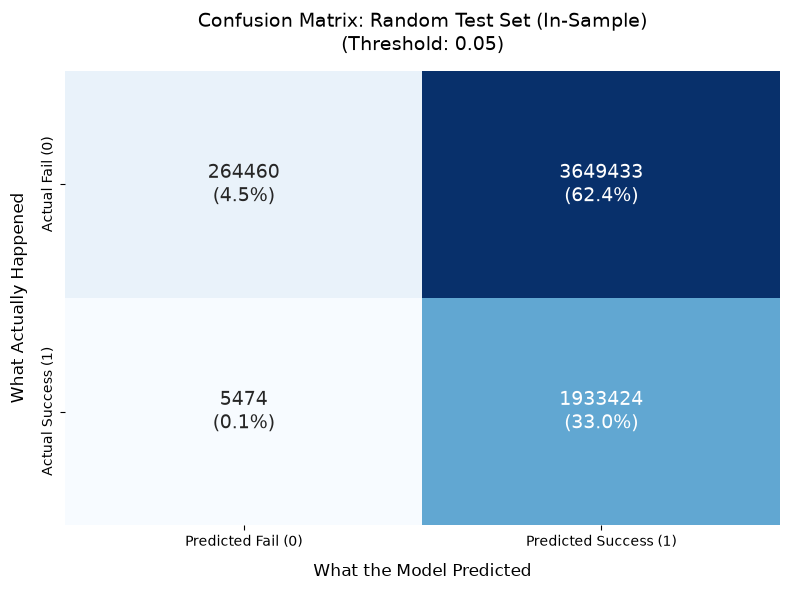


--- Confusion Matrix Breakdown: Random Test Set (In-Sample) (Threshold: 0.05) ---
True Negatives (TN):  264,460 (4.5%) -> Correctly cut off
False Positives (FP): 3,649,433 (62.4%) -> Wasted $0.10 retry
False Negatives (FN): 5,474 (0.1%) -> Missed revenue!
True Positives (TP):  1,933,424 (33.0%) -> Successfully collected


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_business_confusion_matrix(y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact based on model predictions and a given threshold.
    """
    # 2. Convert probabilities to hard predictions
    y_pred = (y_probs >= threshold).astype(int)

    # 3. Calculate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 4. Calculate Percentages and Create Custom Labels ugk 
    # Divide each cell by the total number of predictions to get the % of total
    cm_percentages = cm / np.sum(cm)

    # Zip the raw counts and the percentages together into a formatted string
    labels = [f"{count}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    # Reshape the list of strings back into a 2x2 grid to match the heatmap
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))

    # Notice we changed annot=labels and fmt='' (empty string) so Seaborn accepts our custom text
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
    plt.ylabel('What Actually Happened', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- Confusion Matrix Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"True Negatives (TN):  {tn:,} ({cm_percentages[0,0]:.1%}) -> Correctly cut off")
    print(f"False Positives (FP): {fp:,} ({cm_percentages[0,1]:.1%}) -> Wasted $0.10 retry")
    print(f"False Negatives (FN): {fn:,} ({cm_percentages[1,0]:.1%}) -> Missed revenue!")
    print(f"True Positives (TP):  {tp:,} ({cm_percentages[1,1]:.1%}) -> Successfully collected")

# =====================================================================
# Generate the Confusion Matrices using variables from your training script
# ====================================================================

# Check the Random Holdout Test Set
y_true_062025 = df_pred['IS_EVENTUALLY_SUCCESSFUL'].values
y_probs_062025 = df_pred['SUCCESS_PROBABILITY'].values

plot_business_confusion_matrix(y_true=y_true_062025, 
                               y_probs=y_probs_062025, 
                               threshold=0.05, 
                               dataset_name="Random Test Set (In-Sample)")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_order_level_confusion_matrix(order_ids, y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact at the ORDER level.
    Rules:
    - If Actual=1: If ANY transaction is predicted 0 (cut off), order is False Negative.
                   Otherwise (ALL predicted 1), it's a True Positive.
    - If Actual=0: If ANY transaction is predicted 1 (allowed), order is False Positive.
                   Otherwise (ALL predicted 0), it's a True Negative.
    """
    # 1. Create a temporary dataframe to group predictions by order
    df = pd.DataFrame({
        'order_id': order_ids,
        'y_true': y_true,
        'y_pred': (y_probs >= threshold).astype(int)
    })

    # 2. Group by order_id and evaluate the predictions
    grouped = df.groupby('order_id').agg(
        y_true=('y_true', 'first'),                     # Actual outcome is the same for the whole order
        has_pred_0=('y_pred', lambda x: (x == 0).any()), # Did we predict 0 for ANY transaction?
        has_pred_1=('y_pred', lambda x: (x == 1).any())  # Did we predict 1 for ANY transaction?
    )

    # 3. Apply the Business Logic to categorize each order
    FN = ((grouped['y_true'] == 1) & (grouped['has_pred_0'])).sum()
    TP = ((grouped['y_true'] == 1) & (~grouped['has_pred_0'])).sum()
    FP = ((grouped['y_true'] == 0) & (grouped['has_pred_1'])).sum()
    TN = ((grouped['y_true'] == 0) & (~grouped['has_pred_1'])).sum()

    # 4. Build the Confusion Matrix array and calculate percentages
    cm = np.array([[TN, FP], 
                   [FN, TP]])
    cm_percentages = cm / np.sum(cm)

    labels = [f"{count:,}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Order-Level Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('Order-Level Prediction Outcome', fontsize=12, labelpad=10)
    plt.ylabel('Actual Order Outcome', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    print(f"\n--- Order-Level Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"Total Unique Orders:  {np.sum(cm):,}")
    print(f"True Negatives (TN):  {TN:,} ({cm_percentages[0,0]:.1%}) -> Entire bad order correctly cut off")
    print(f"False Positives (FP): {FP:,} ({cm_percentages[0,1]:.1%}) -> Allowed at least one retry on a doomed order")
    print(f"False Negatives (FN): {FN:,} ({cm_percentages[1,0]:.1%}) -> Killed a good order prematurely (Missed revenue!)")
    print(f"True Positives (TP):  {TP:,} ({cm_percentages[1,1]:.1%}) -> Allowed all retries, successfully collected")

print("\nGenerating Order-Level Confusion Matrices...")

# 2. Evaluate the Random Holdout Test Set (In-Sample)
plot_order_level_confusion_matrix(
    order_ids=random_test_df['ORDER_ID'].values, 
    y_true=y_true_062025, 
    y_probs=y_probs_062025, 
    threshold=0.03, 
    dataset_name="Random Test Set (In-Sample)"
)


Generating Order-Level Confusion Matrices...


ValueError: All arrays must be of the same length

In [ ]:
import os
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score # <-- Added Import

# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_062025")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

# =====================================================================
# 4. Evaluate Performance (NEW AUC SECTION)
# =====================================================================
print("\nEvaluating Model Performance...")

if 'IS_EVENTUALLY_SUCCESSFUL' in df_pred.columns:
    # Filter out any rows where the target might be NaN (unresolved invoices)
    valid_mask = df_pred['IS_EVENTUALLY_SUCCESSFUL'].notna()
    
    if valid_mask.sum() > 0:
        y_true = df_pred.loc[valid_mask, 'IS_EVENTUALLY_SUCCESSFUL'].astype(int)
        y_prob = df_pred.loc[valid_mask, 'SUCCESS_PROBABILITY']
        
        auc_score = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC Score on New Data: {auc_score:.4f}")
        print(f"*(Evaluated on {valid_mask.sum():,} resolved rows)*")
    else:
        print("Cannot calculate AUC: 'IS_EVENTUALLY_SUCCESSFUL' contains only null values.")
else:
    print("Cannot calculate AUC: Target column 'IS_EVENTUALLY_SUCCESSFUL' missing from data.")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!

Evaluating Model Performance...
ROC-AUC Score on New Data: 0.7626
*(Evaluated on 5,852,791 resolved rows)*


Computing invoice resolution times...
  33,085,680 rows | 4,738,235 invoices | 1,867,180 orders
Processing and Imputing Data...


<ipython-input-26-3f1c1810ad97>:69: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()


Splitting data (As-Of OOT + Order-Grouped Random)...
  past_data   : 8,494,601 rows | 1,170,663 orders
  oot_test_df : 3,145,928 rows | 877,821 orders
  orders in both (new invoices, expected): 338,634
  dropped (unresolved at ASOF / beyond OOT_END): 21,445,151 rows
  train_df       : 6,362,626 rows | 877,572 orders | base rate 0.4745
  stop_df        :   853,861 rows | 117,081 orders | base rate 0.4761
  calib_df       :   851,732 rows | 117,235 orders | base rate 0.4749
  random_test_df :   426,382 rows |  58,775 orders | base rate 0.4734
  [ok] no ORDER_ID spans two splits
Building data pools...
Training Base Model...
0:	learn: 0.6593684	test: 0.6594044	best: 0.6594044 (0)	total: 6.21s	remaining: 20m 35s
50:	learn: 0.4844126	test: 0.4852446	best: 0.4852446 (50)	total: 3m 34s	remaining: 10m 25s
100:	learn: 0.4643141	test: 0.4655724	best: 0.4655724 (100)	total: 6m 52s	remaining: 6m 44s
150:	learn: 0.4532014	test: 0.4548338	best: 0.4548338 (150)	total: 10m 9s	remaining: 3m 17s
199:	lea

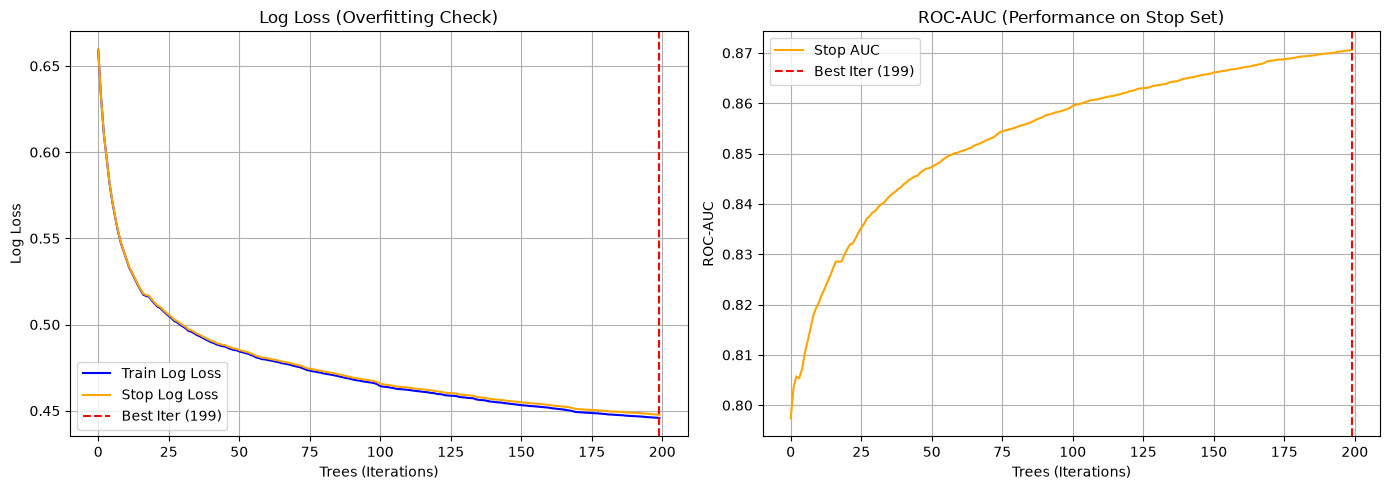

Calibrating Probabilities...

Evaluating Model on Dual Test Sets...
--- Model Performance Summary ---
Random Test     | ROC-AUC: 0.8722 | Log Loss: 0.4424 | Brier Score: 0.1455
OOT Test        | ROC-AUC: 0.8276 | Log Loss: 0.6184 | Brier Score: 0.1865

Temporal Degradation Penalty (AUC Drop): 0.0446
*(Both splits are order-grouped and label-mature. A large drop now means real
  behavioural/processor drift between the training period and OOT window.)*


In [ ]:
# Model Training Starts Here
sampled_df = df

# Must match the DATEDIFF threshold in the training SQL's in-flight filter
MATURITY_DAYS = 30

# =====================================================================
# 1. Base Filtering and Sorting
# =====================================================================
sampled_df['LAST_DECLINE_CODE'] = sampled_df['LAST_DECLINE_CODE'].astype(str)
sampled_df['DECLINE_FAMILY'] = sampled_df['LAST_DECLINE_CODE'].str[0]

sampled_df['TRANSACTION_DATETIME'] = pd.to_datetime(sampled_df['TRANSACTION_DATETIME'])

# Sort ascending to guarantee Past predicts Future
sampled_df = sampled_df.sort_values('TRANSACTION_DATETIME').reset_index(drop=True)

# =====================================================================
# 1b. Invoice resolution timing  
# =====================================================================

print("Computing invoice resolution times...")

invoice_times = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    INVOICE_START=('TRANSACTION_DATETIME', 'min'),
    INVOICE_LAST_TXN=('TRANSACTION_DATETIME', 'max'),
    IS_EVENTUALLY_SUCCESSFUL=('IS_EVENTUALLY_SUCCESSFUL', 'first'),
)

first_accept = (
    sampled_df.loc[sampled_df['TRANSACTION_STATUS'] == 'accepted']
              .groupby('INVOICE_ID')['TRANSACTION_DATETIME'].min()
)

invoice_times['RESOLVED_AT'] = first_accept.reindex(invoice_times.index).where(
    invoice_times['IS_EVENTUALLY_SUCCESSFUL'] == 1,
    invoice_times['INVOICE_START'] + pd.Timedelta(days=MATURITY_DAYS)
)

if invoice_times['RESOLVED_AT'].isna().any():
    raise ValueError(
        f"{invoice_times['RESOLVED_AT'].isna().sum()} invoices are labelled successful "
        "but have no accepted transaction. Did the != 'accepted' filter get left in the SQL?"
    )

sampled_df = sampled_df.merge(
    invoice_times[['INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']],
    left_on='INVOICE_ID', right_index=True, how='left'
)

# Now drop the accepted rows -- at serving time the model only ever scores declines.
#sampled_df = sampled_df[sampled_df['TRANSACTION_STATUS'] != 'accepted'].reset_index(drop=True)
print(f"  {len(sampled_df):,} rows | {sampled_df['INVOICE_ID'].nunique():,} invoices "
      f"| {sampled_df['ORDER_ID'].nunique():,} orders")

# =======================================================================
# 2. Data Processing & Pre-Split Vectorized I
# =======================================================================
print("Processing and Imputing Data...")
drop_cols = ['ORDER_ID', 'INVOICE_ID', 'TRANSACTION_ID', 'TRANSACTION_DATETIME',
             'IS_EVENTUALLY_SUCCESSFUL', 'TRANSACTION_STATUS',
             'INVOICE_START', 'INVOICE_LAST_TXN', 'RESOLVED_AT']

# Separate text features from standard categorical features for better string processing
text_features = [col for col in ['SUPER_PARTNER_ID_NAME', 'BANK'] if col in sampled_df.columns]

# Get remaining categorical features (Using errors='ignore' safely)
cat_features = sampled_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c not in text_features]

# Vectorized Imputation BEFORE the split (Massive speedup)
sampled_df[cat_features + text_features] = sampled_df[cat_features + text_features].fillna('unknown').astype(str)

# Get purely numeric feature columns (excluding drops and target)
numeric_cols = sampled_df.columns.difference(cat_features + text_features + drop_cols)
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(-1)

# =====================================================================
# 3. Hybrid Split (As-Of-Date OOT + Order-Grouped Random)
# =====================================================================
print("Splitting data (As-Of OOT + Order-Grouped Random)...")

ASOF_DATE = pd.Timestamp('2026-02-15')   # "retrain the model on this date"
OOT_END   = pd.Timestamp('2026-03-01')   # MUST be <= max ORDER_DATE in the extract

invoice_elig = sampled_df.groupby('INVOICE_ID', sort=False).agg(
    RESOLVED_AT=('RESOLVED_AT', 'first'),
    INVOICE_LAST_TXN=('INVOICE_LAST_TXN', 'first'),
)
eligible_invoices = invoice_elig.index[
    (invoice_elig['RESOLVED_AT'] < ASOF_DATE) &
    (invoice_elig['INVOICE_LAST_TXN'] < ASOF_DATE)
]

past_data = sampled_df[
    sampled_df['INVOICE_ID'].isin(eligible_invoices) &
    (sampled_df['TRANSACTION_DATETIME'] < ASOF_DATE)
].copy()

oot_test_df = sampled_df[
    (sampled_df['TRANSACTION_DATETIME'] >= ASOF_DATE) &
    (sampled_df['TRANSACTION_DATETIME'] < OOT_END)
].copy()

assert not (set(past_data['INVOICE_ID']) & set(oot_test_df['INVOICE_ID'])), \
    "invoices straddle the as-of boundary"

print(f"  past_data   : {len(past_data):>9,} rows | {past_data['ORDER_ID'].nunique():>7,} orders")
print(f"  oot_test_df : {len(oot_test_df):>9,} rows | {oot_test_df['ORDER_ID'].nunique():>7,} orders")
print(f"  orders in both (new invoices, expected): "
      f"{len(set(past_data['ORDER_ID']) & set(oot_test_df['ORDER_ID'])):,}")
print(f"  dropped (unresolved at ASOF / beyond OOT_END): "
      f"{len(sampled_df) - len(past_data) - len(oot_test_df):,} rows")

# --- FIX 1: order-grouped assignment --------------------------------------------
# hashlib rather than hash(): Python salts str hashing per process, so hash() would
# reshuffle orders across splits on every run. This assignment is stable, and stays
# stable when new orders are added next month.
def order_hash_frac(order_ids, salt='retry_cutoff_v1'):
    return np.array([
        int(hashlib.md5(f'{salt}:{o}'.encode()).hexdigest()[:16], 16) / 2**64
        for o in order_ids
    ])

unique_orders = past_data['ORDER_ID'].unique()
order_frac = pd.Series(order_hash_frac(unique_orders), index=unique_orders)
row_frac = past_data['ORDER_ID'].map(order_frac)

# Same 75 / 10 / 10 / 5 boundaries as before -- but over ORDERS, not rows.
train_df       = past_data[row_frac < 0.75].copy()
stop_df        = past_data[(row_frac >= 0.75) & (row_frac < 0.85)].copy()
calib_df       = past_data[(row_frac >= 0.85) & (row_frac < 0.95)].copy()
random_test_df = past_data[row_frac >= 0.95].copy()

for _name, _part in [('train_df', train_df), ('stop_df', stop_df),
                     ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    print(f"  {_name:<15}: {len(_part):>9,} rows | {_part['ORDER_ID'].nunique():>7,} orders "
          f"| base rate {_part['IS_EVENTUALLY_SUCCESSFUL'].mean():.4f}")

for _a, _b in [('train_df', train_df), ('stop_df', stop_df),
               ('calib_df', calib_df), ('random_test_df', random_test_df)]:
    for _c, _d in [('train_df', train_df), ('stop_df', stop_df),
                   ('calib_df', calib_df), ('random_test_df', random_test_df)]:
        if _a < _c:
            assert not (set(_b['ORDER_ID']) & set(_d['ORDER_ID'])), f"{_a}/{_c} share orders"
print("  [ok] no ORDER_ID spans two splits")

# 4. Separate X and y (Using errors='ignore' safely)
X_train, y_train = train_df.drop(columns=drop_cols, errors='ignore'), train_df['IS_EVENTUALLY_SUCCESSFUL']
X_stop,  y_stop  = stop_df.drop(columns=drop_cols, errors='ignore'),  stop_df['IS_EVENTUALLY_SUCCESSFUL']
X_calib, y_calib = calib_df.drop(columns=drop_cols, errors='ignore'), calib_df['IS_EVENTUALLY_SUCCESSFUL']

X_random_test, y_random_test = random_test_df.drop(columns=drop_cols, errors='ignore'), random_test_df['IS_EVENTUALLY_SUCCESSFUL']
X_oot_test,    y_oot_test    = oot_test_df.drop(columns=drop_cols, errors='ignore'),    oot_test_df['IS_EVENTUALLY_SUCCESSFUL']

# =====================================================================
# 4. Create Memory-Efficient CatBoost Pools
# =====================================================================
print("Building data pools...")
train_pool = Pool(X_train, y_train, cat_features=cat_features, text_features=text_features)
stop_pool  = Pool(X_stop,  y_stop,  cat_features=cat_features, text_features=text_features)

# =====================================================================
# 5. Base Model Definition
# =====================================================================
print("Training Base Model...")
base_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,          # Updated Learning Rate
    depth=6,
    task_type="CPU",
    eval_metric='Logloss',
    custom_metric=['AUC'],
    l2_leaf_reg=6,
    thread_count=-1,
    early_stopping_rounds=50,
    verbose=50,
    random_state=42,
    cat_features=cat_features,
    text_features=text_features
)

# Train the model, strictly using the Stop pool
base_model.fit(train_pool, eval_set=stop_pool)

# =====================================================================
# 6. In-Flight Overfitting Diagnostic Plot
# =====================================================================
print("Plotting Learning Curves...")
history = base_model.evals_result_
iterations_range = range(len(history['learn']['Logloss']))
best_iter = base_model.get_best_iteration()

# Safely locate the validation dictionary key
val_key = 'validation' if 'validation' in history else 'validation_0'

plt.figure(figsize=(14, 5))

# Plot Log Loss
plt.subplot(1, 2, 1)
plt.plot(iterations_range, history['learn']['Logloss'], label='Train Log Loss', color='blue')
plt.plot(iterations_range, history[val_key]['Logloss'], label='Stop Log Loss', color='orange')
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
plt.title('Log Loss (Overfitting Check)')
plt.xlabel('Trees (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

# Plot ROC-AUC (Fixing the AUC KeyError by ignoring Train AUC)
plt.subplot(1, 2, 2)
if 'AUC' in history[val_key]:
    plt.plot(iterations_range, history[val_key]['AUC'], label='Stop AUC', color='orange')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iter ({best_iter})')
    plt.title('ROC-AUC (Performance on Stop Set)')
    plt.xlabel('Trees (Iterations)')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True)
else:
    plt.title('AUC not tracked')

plt.tight_layout()
plt.show()

# =====================================================================
# 7. Probability Calibration
# =====================================================================
print("Calibrating Probabilities...")
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic'
)
calibrated_model.fit(X_calib, y_calib)

# =====================================================================
# 8. Final Dual-Evaluation (Random vs. Chronological)
# =====================================================================
print("\nEvaluating Model on Dual Test Sets...")

def evaluate_split(split_name, model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    loss = log_loss(y, y_prob)
    brier = brier_score_loss(y, y_prob)
    print(f"{split_name: <15} | ROC-AUC: {auc:.4f} | Log Loss: {loss:.4f} | Brier Score: {brier:.4f}")
    return y_prob

print("--- Model Performance Summary ---")
# 1. Unseen ORDERS from the same period as training -> generalization to new customers.
random_probs = evaluate_split("Random Test", calibrated_model, X_random_test, y_random_test)

# 2. The strict future -> what the model would actually have scored after ASOF_DATE.
oot_probs    = evaluate_split("OOT Test", calibrated_model, X_oot_test, y_oot_test)

# Calculate the Degradation Penalty
auc_drop = roc_auc_score(y_random_test, random_probs) - roc_auc_score(y_oot_test, oot_probs)
print(f"\nTemporal Degradation Penalty (AUC Drop): {auc_drop:.4f}")
# CHANGED: both sides are now order-grouped and label-mature, so this gap is no longer
# contaminated by row duplication or by lifecycle-tail enrichment. What remains is
# genuine drift between the training period and the deployment window.
print("*(Both splits are order-grouped and label-mature. A large drop now means real")
print("  behavioural/processor drift between the training period and OOT window.)*")

In [ ]:
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

# 2. Package the model and the exact feature lists into one dictionary
# This ensures your prediction script applies the exact same preprocessing
model_artifact = {
    'model': calibrated_model,
    'cat_features': cat_features,
    'text_features': text_features,
    'drop_cols': drop_cols,
}

# 3. Save the artifact to the script's directory
joblib.dump(model_artifact, model_path)

print(f"Model artifact successfully saved to: {model_path}")

Model artifact successfully saved to: /Users/amanda.huang/NIC/amanda_projects/Early_Retry_Cutoffs/calibrated_catboost_model.joblib


In [ ]:
import os
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score # <-- Added Import

# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_062025")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

# =====================================================================
# 4. Evaluate Performance (NEW AUC SECTION)
# =====================================================================
print("\nEvaluating Model Performance...")

if 'IS_EVENTUALLY_SUCCESSFUL' in df_pred.columns:
    # Filter out any rows where the target might be NaN (unresolved invoices)
    valid_mask = df_pred['IS_EVENTUALLY_SUCCESSFUL'].notna()
    
    if valid_mask.sum() > 0:
        y_true = df_pred.loc[valid_mask, 'IS_EVENTUALLY_SUCCESSFUL'].astype(int)
        y_prob = df_pred.loc[valid_mask, 'SUCCESS_PROBABILITY']
        
        auc_score = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC Score on New Data: {auc_score:.4f}")
        print(f"*(Evaluated on {valid_mask.sum():,} resolved rows)*")
    else:
        print("Cannot calculate AUC: 'IS_EVENTUALLY_SUCCESSFUL' contains only null values.")
else:
    print("Cannot calculate AUC: Target column 'IS_EVENTUALLY_SUCCESSFUL' missing from data.")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!

Evaluating Model Performance...
ROC-AUC Score on New Data: 0.8212
*(Evaluated on 5,852,791 resolved rows)*


In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

# 20 example orders where the gate flips the value (_diff is positional, so use iloc)
_diff_examples = _c.iloc[_diff][['ORDER_ID', 'IS_EVENTUALLY_SUCCESSFUL',
                                 'CLTV_360', 'HISTORICAL_COLLECTED_AMOUNT',
                                 'SUCCESS_PROBABILITY', 'ECLTV_1Y']].head(20)
print("\n20 example orders that differ:")
print(_diff_examples.to_string(index=False))

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       39691                24654     20639.8        8684.30      11955.50
model p < 0.02       49956                30946     28170.6       14658.76      13511.84
model p < 0.03       65431                40722     40478.9       28175.88      12303.02
model p < 0.05       91096                55932     61442.2       58647.54       2794.66
 model p < 0.1      125172                76475     94347.6      117693.48     -23345.88
model p < 0.15      145660                89793    127370.4      188070.72     -60700.32
 model p < 0.2      156216                97277    152570.1      239256.06     -86685.96
 model p < 0.3      175161               111212    206044.9      351035.31    -144990.41
 model p < 0.4      194558               125425    265374.9      46


Generating Order-Level Confusion Matrices...


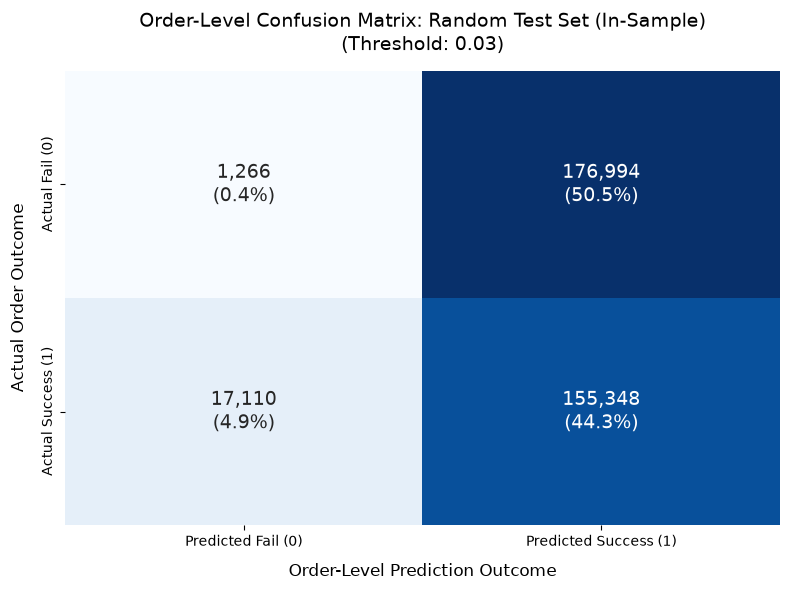


--- Order-Level Breakdown: Random Test Set (In-Sample) (Threshold: 0.03) ---
Total Unique Orders:  350,718
True Negatives (TN):  1,266 (0.4%) -> Entire bad order correctly cut off
False Positives (FP): 176,994 (50.5%) -> Allowed at least one retry on a doomed order
False Negatives (FN): 17,110 (4.9%) -> Killed a good order prematurely (Missed revenue!)
True Positives (TP):  155,348 (44.3%) -> Allowed all retries, successfully collected


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_order_level_confusion_matrix(order_ids, y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact at the ORDER level.
    Rules:
    - If Actual=1: If ANY transaction is predicted 0 (cut off), order is False Negative.
                   Otherwise (ALL predicted 1), it's a True Positive.
    - If Actual=0: If ANY transaction is predicted 1 (allowed), order is False Positive.
                   Otherwise (ALL predicted 0), it's a True Negative.
    """
    # 1. Create a temporary dataframe to group predictions by order
    df = pd.DataFrame({
        'order_id': order_ids,
        'y_true': y_true,
        'y_pred': (y_probs >= threshold).astype(int)
    })

    # 2. Group by order_id and evaluate the predictions
    grouped = df.groupby('order_id').agg(
        y_true=('y_true', 'first'),                     # Actual outcome is the same for the whole order
        has_pred_0=('y_pred', lambda x: (x == 0).any()), # Did we predict 0 for ANY transaction?
        has_pred_1=('y_pred', lambda x: (x == 1).any())  # Did we predict 1 for ANY transaction?
    )

    # 3. Apply the Business Logic to categorize each order
    FN = ((grouped['y_true'] == 1) & (grouped['has_pred_0'])).sum()
    TP = ((grouped['y_true'] == 1) & (~grouped['has_pred_0'])).sum()
    FP = ((grouped['y_true'] == 0) & (grouped['has_pred_1'])).sum()
    TN = ((grouped['y_true'] == 0) & (~grouped['has_pred_1'])).sum()

    # 4. Build the Confusion Matrix array and calculate percentages
    cm = np.array([[TN, FP], 
                   [FN, TP]])
    cm_percentages = cm / np.sum(cm)

    labels = [f"{count:,}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Order-Level Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('Order-Level Prediction Outcome', fontsize=12, labelpad=10)
    plt.ylabel('Actual Order Outcome', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    print(f"\n--- Order-Level Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"Total Unique Orders:  {np.sum(cm):,}")
    print(f"True Negatives (TN):  {TN:,} ({cm_percentages[0,0]:.1%}) -> Entire bad order correctly cut off")
    print(f"False Positives (FP): {FP:,} ({cm_percentages[0,1]:.1%}) -> Allowed at least one retry on a doomed order")
    print(f"False Negatives (FN): {FN:,} ({cm_percentages[1,0]:.1%}) -> Killed a good order prematurely (Missed revenue!)")
    print(f"True Positives (TP):  {TP:,} ({cm_percentages[1,1]:.1%}) -> Allowed all retries, successfully collected")

print("\nGenerating Order-Level Confusion Matrices...")

# 2. Evaluate the Random Holdout Test Set (In-Sample)
plot_order_level_confusion_matrix(
    order_ids=df_pred['ORDER_ID'].values, 
    y_true=y_true_062025, 
    y_probs=y_probs_062025, 
    threshold=0.03, 
    dataset_name="Random Test Set (In-Sample)"
)


Generating Order-Level Confusion Matrices...


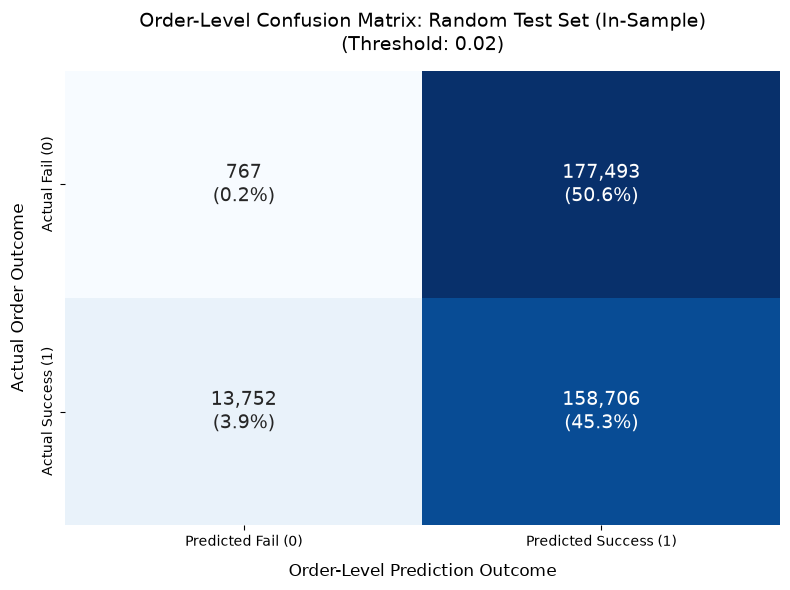


--- Order-Level Breakdown: Random Test Set (In-Sample) (Threshold: 0.02) ---
Total Unique Orders:  350,718
True Negatives (TN):  767 (0.2%) -> Entire bad order correctly cut off
False Positives (FP): 177,493 (50.6%) -> Allowed at least one retry on a doomed order
False Negatives (FN): 13,752 (3.9%) -> Killed a good order prematurely (Missed revenue!)
True Positives (TP):  158,706 (45.3%) -> Allowed all retries, successfully collected


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_order_level_confusion_matrix(order_ids, y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact at the ORDER level.
    Rules:
    - If Actual=1: If ANY transaction is predicted 0 (cut off), order is False Negative.
                   Otherwise (ALL predicted 1), it's a True Positive.
    - If Actual=0: If ANY transaction is predicted 1 (allowed), order is False Positive.
                   Otherwise (ALL predicted 0), it's a True Negative.
    """
    # 1. Create a temporary dataframe to group predictions by order
    df = pd.DataFrame({
        'order_id': order_ids,
        'y_true': y_true,
        'y_pred': (y_probs >= threshold).astype(int)
    })

    # 2. Group by order_id and evaluate the predictions
    grouped = df.groupby('order_id').agg(
        y_true=('y_true', 'first'),                     # Actual outcome is the same for the whole order
        has_pred_0=('y_pred', lambda x: (x == 0).any()), # Did we predict 0 for ANY transaction?
        has_pred_1=('y_pred', lambda x: (x == 1).any())  # Did we predict 1 for ANY transaction?
    )

    # 3. Apply the Business Logic to categorize each order
    FN = ((grouped['y_true'] == 1) & (grouped['has_pred_0'])).sum()
    TP = ((grouped['y_true'] == 1) & (~grouped['has_pred_0'])).sum()
    FP = ((grouped['y_true'] == 0) & (grouped['has_pred_1'])).sum()
    TN = ((grouped['y_true'] == 0) & (~grouped['has_pred_1'])).sum()

    # 4. Build the Confusion Matrix array and calculate percentages
    cm = np.array([[TN, FP], 
                   [FN, TP]])
    cm_percentages = cm / np.sum(cm)

    labels = [f"{count:,}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Order-Level Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('Order-Level Prediction Outcome', fontsize=12, labelpad=10)
    plt.ylabel('Actual Order Outcome', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    print(f"\n--- Order-Level Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"Total Unique Orders:  {np.sum(cm):,}")
    print(f"True Negatives (TN):  {TN:,} ({cm_percentages[0,0]:.1%}) -> Entire bad order correctly cut off")
    print(f"False Positives (FP): {FP:,} ({cm_percentages[0,1]:.1%}) -> Allowed at least one retry on a doomed order")
    print(f"False Negatives (FN): {FN:,} ({cm_percentages[1,0]:.1%}) -> Killed a good order prematurely (Missed revenue!)")
    print(f"True Positives (TP):  {TP:,} ({cm_percentages[1,1]:.1%}) -> Allowed all retries, successfully collected")

print("\nGenerating Order-Level Confusion Matrices...")

# 2. Evaluate the Random Holdout Test Set (In-Sample)
plot_order_level_confusion_matrix(
    order_ids=df_pred['ORDER_ID'].values, 
    y_true=y_true_062025, 
    y_probs=y_probs_062025, 
    threshold=0.02, 
    dataset_name="Random Test Set (In-Sample)"
)

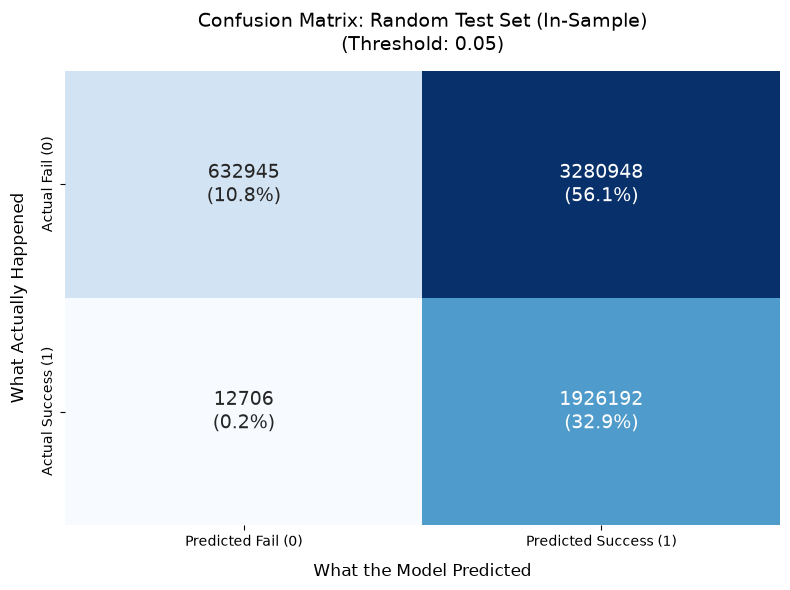


--- Confusion Matrix Breakdown: Random Test Set (In-Sample) (Threshold: 0.05) ---
True Negatives (TN):  632,945 (10.8%) -> Correctly cut off
False Positives (FP): 3,280,948 (56.1%) -> Wasted $0.10 retry
False Negatives (FN): 12,706 (0.2%) -> Missed revenue!
True Positives (TP):  1,926,192 (32.9%) -> Successfully collected


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_business_confusion_matrix(y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact based on model predictions and a given threshold.
    """
    # 2. Convert probabilities to hard predictions
    y_pred = (y_probs >= threshold).astype(int)

    # 3. Calculate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 4. Calculate Percentages and Create Custom Labels ugk 
    # Divide each cell by the total number of predictions to get the % of total
    cm_percentages = cm / np.sum(cm)

    # Zip the raw counts and the percentages together into a formatted string
    labels = [f"{count}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    # Reshape the list of strings back into a 2x2 grid to match the heatmap
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))

    # Notice we changed annot=labels and fmt='' (empty string) so Seaborn accepts our custom text
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
    plt.ylabel('What Actually Happened', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- Confusion Matrix Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"True Negatives (TN):  {tn:,} ({cm_percentages[0,0]:.1%}) -> Correctly cut off")
    print(f"False Positives (FP): {fp:,} ({cm_percentages[0,1]:.1%}) -> Wasted $0.10 retry")
    print(f"False Negatives (FN): {fn:,} ({cm_percentages[1,0]:.1%}) -> Missed revenue!")
    print(f"True Positives (TP):  {tp:,} ({cm_percentages[1,1]:.1%}) -> Successfully collected")

# =====================================================================
# Generate the Confusion Matrices using variables from your training script
# ====================================================================

# Check the Random Holdout Test Set
y_true_062025 = df_pred['IS_EVENTUALLY_SUCCESSFUL'].values
y_probs_062025 = df_pred['SUCCESS_PROBABILITY'].values

plot_business_confusion_matrix(y_true=y_true_062025, 
                               y_probs=y_probs_062025, 
                               threshold=0.05, 
                               dataset_name="Random Test Set (In-Sample)")


Generating Order-Level Confusion Matrices...


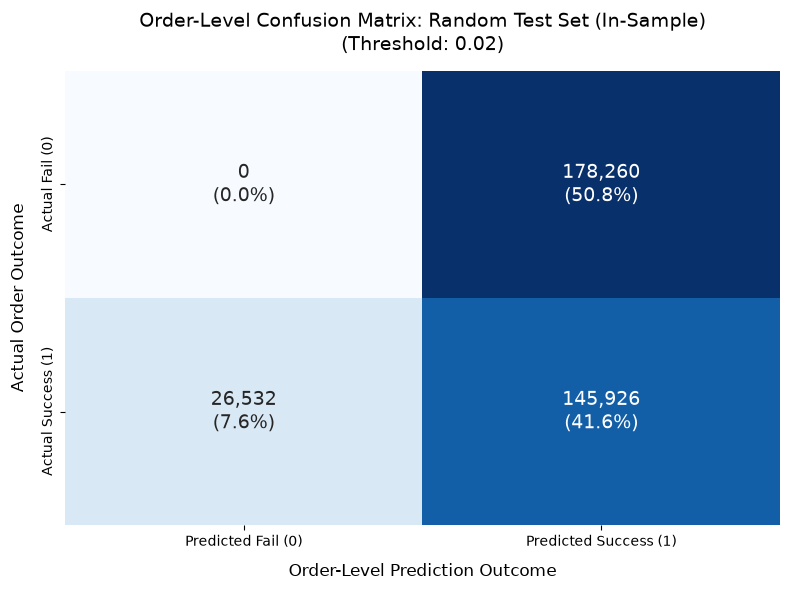


--- Order-Level Breakdown: Random Test Set (In-Sample) (Threshold: 0.02) ---
Total Unique Orders:  350,718
True Negatives (TN):  0 (0.0%) -> Entire bad order correctly cut off
False Positives (FP): 178,260 (50.8%) -> Allowed at least one retry on a doomed order
False Negatives (FN): 26,532 (7.6%) -> Killed a good order prematurely (Missed revenue!)
True Positives (TP):  145,926 (41.6%) -> Allowed all retries, successfully collected


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import confusion_matrix

def plot_order_level_confusion_matrix(order_ids, y_true, y_probs, threshold=0.05, dataset_name="Test Set"):
    """
    Evaluates business impact at the ORDER level.
    Rules:
    - If Actual=1: If ANY transaction is predicted 0 (cut off), order is False Negative.
                   Otherwise (ALL predicted 1), it's a True Positive.
    - If Actual=0: If ANY transaction is predicted 1 (allowed), order is False Positive.
                   Otherwise (ALL predicted 0), it's a True Negative.
    """
    # 1. Create a temporary dataframe to group predictions by order
    df = pd.DataFrame({
        'order_id': order_ids,
        'y_true': y_true,
        'y_pred': (y_probs >= threshold).astype(int)
    })

    # 2. Group by order_id and evaluate the predictions
    grouped = df.groupby('order_id').agg(
        y_true=('y_true', 'first'),                     # Actual outcome is the same for the whole order
        has_pred_0=('y_pred', lambda x: (x == 0).any()), # Did we predict 0 for ANY transaction?
        has_pred_1=('y_pred', lambda x: (x == 1).any())  # Did we predict 1 for ANY transaction?
    )

    # 3. Apply the Business Logic to categorize each order
    FN = ((grouped['y_true'] == 1) & (grouped['has_pred_0'])).sum()
    TP = ((grouped['y_true'] == 1) & (~grouped['has_pred_0'])).sum()
    FP = ((grouped['y_true'] == 0) & (grouped['has_pred_1'])).sum()
    TN = ((grouped['y_true'] == 0) & (~grouped['has_pred_1'])).sum()

    # 4. Build the Confusion Matrix array and calculate percentages
    cm = np.array([[TN, FP], 
                   [FN, TP]])
    cm_percentages = cm / np.sum(cm)

    labels = [f"{count:,}\n({percentage:.1%})" for count, percentage in zip(cm.flatten(), cm_percentages.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    # 5. Visualize the Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, annot_kws={'size': 14},
                xticklabels=['Predicted Fail (0)', 'Predicted Success (1)'],
                yticklabels=['Actual Fail (0)', 'Actual Success (1)'])

    plt.title(f'Order-Level Confusion Matrix: {dataset_name}\n(Threshold: {threshold})', fontsize=14, pad=15)
    plt.xlabel('Order-Level Prediction Outcome', fontsize=12, labelpad=10)
    plt.ylabel('Actual Order Outcome', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.show()

    # 6. Print the business breakdown
    print(f"\n--- Order-Level Breakdown: {dataset_name} (Threshold: {threshold}) ---")
    print(f"Total Unique Orders:  {np.sum(cm):,}")
    print(f"True Negatives (TN):  {TN:,} ({cm_percentages[0,0]:.1%}) -> Entire bad order correctly cut off")
    print(f"False Positives (FP): {FP:,} ({cm_percentages[0,1]:.1%}) -> Allowed at least one retry on a doomed order")
    print(f"False Negatives (FN): {FN:,} ({cm_percentages[1,0]:.1%}) -> Killed a good order prematurely (Missed revenue!)")
    print(f"True Positives (TP):  {TP:,} ({cm_percentages[1,1]:.1%}) -> Allowed all retries, successfully collected")

print("\nGenerating Order-Level Confusion Matrices...")

# 2. Evaluate the Random Holdout Test Set (In-Sample)
plot_order_level_confusion_matrix(
    order_ids=df_pred['ORDER_ID'].values, 
    y_true=y_true_062025, 
    y_probs=y_probs_062025, 
    threshold=0.02, 
    dataset_name="Random Test Set (In-Sample)"
)

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (25
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       39691                24654     21540.2        8684.30      12855.90
model p < 0.02       49956                30946     30652.1       14658.76      15993.34
model p < 0.03       65431                40722     47560.8       28175.88      19384.92
model p < 0.05       91096                55932     75387.4       58647.54      16739.86
 model p < 0.1      125172                76475    125994.0      117693.48       8300.52
model p < 0.15      145660                89793    179107.7      188070.72      -8963.02
 model p < 0.2      156216                97277    218558.4      239256.06     -20697.66
 model p < 0.3      175161               111212    301104.4      351035.31     -49930.91
 model p < 0.4      194558               125425    394361.6      46

In [ ]:
# Add FUTURE_SUCCESS inside prepare_cutoff_frame, right after ORDER_ATTEMPTS_SAVED:
#
#     rev = df.iloc[::-1]
#     df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
#
# Cutting kills the whole order, so every invoice at or after this row dies with it.
# If any of them would have collected, the order was cut prematurely => false negative.
#
# And in _score, after 'Orders Cut':
#
#     'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
#     'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",

import pandas as pd
import numpy as np

# =============================================================================
# Which never-M0 orders collected money, and why?
# =============================================================================
never = cutoff_df[cutoff_df['NEVER_M0']]
collected = (never.groupby('ORDER_ID')['HISTORICAL_COLLECTED_AMOUNT'].max()
                  .loc[lambda s: s > 0].sort_values(ascending=False))

n_never = never['ORDER_ID'].nunique()
print("=" * 78)
print("NEVER-M0 ORDERS THAT COLLECTED MONEY")
print("=" * 78)
print(f"  never-M0 orders          : {n_never:,}")
print(f"  ...that collected > $0   : {len(collected):,} ({len(collected)/n_never:.2%})")
print(f"  total collected by them  : ${collected.sum():,.2f}")
print(f"\n  Every one of these is being cut with loss forced to $0.\n")
print(collected.head(20).to_string())

# =============================================================================
# THE DECIDER -- are they really non-M0, or did the June date filter drop them?
#
# load_cltv() filters `order_date >= '2025-06-01' and order_date < '2025-07-01'`.
# An order that DID make M0 but whose order_date falls outside June is ALSO absent
# from tb -- and my merge indicator marks it 'left_only' exactly like a true non-M0
# order. NEVER_M0 conflates the two. If is_m0=1 comes back below, that is the bug.
# =============================================================================
if len(collected):
    ids = ','.join(str(i) for i in collected.head(50).index)
    cur = ctx.cursor()
    cur.execute(f"""
    select order_id,
           max(is_m0)                                   as is_m0,
           min(order_date)                              as order_date,
           count(*)                                     as txns,
           sum(iff(transaction_status='accepted',1,0))  as accepted_txns,
           round(sum(iff(transaction_status='accepted', transaction_amount, 0)),2) as collected
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where order_id in ({ids})
    group by 1
    order by collected desc
    """)
    src = cur.fetch_pandas_all()
    print("\n" + "=" * 78)
    print("SAME ORDERS, STRAIGHT FROM THE SOURCE TABLE")
    print("=" * 78)
    print(src.to_string(index=False))
    print(f"\n  is_m0 = 1 anywhere above  -> NEVER_M0 is wrong; the June order_date filter")
    print(f"                              dropped them, not a failed trial.")
    print(f"  order_date outside June   -> confirms it.")
    print(f"  is_m0 = 0 and collected>0 -> is_m0 does not mean what you were told.")

# =============================================================================
# How big is the exposure? Free cuts are 76% of every cut you make.
# =============================================================================
print("\n" + "=" * 78)
print("WHAT IF THE FREE CUTS AREN'T FREE?")
print("=" * 78)
free_at_002 = 25714   # from your p<0.02 row
net_at_002 = 3359.43
print(f"  Net @ p<0.02 : ${net_at_002:,.2f} on {free_at_002:,} free cuts")
for per_order in [0.05, 0.10, 0.13, 0.20, 0.50]:
    adj = net_at_002 - free_at_002 * per_order
    flag = '  <-- Net goes NEGATIVE' if adj < 0 else ''
    print(f"  if each free cut really costs ${per_order:.2f} -> Net ${adj:>10,.2f}{flag}")

KeyError: 'NEVER_M0'

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       39691                24654     20639.8        8684.30      11955.50
model p < 0.02       49956                30946     28170.6       14658.76      13511.84
model p < 0.03       65431                40722     40478.9       28175.88      12303.02
model p < 0.05       91096                55932     61442.2       58647.54       2794.66
 model p < 0.1      125172                76475     94347.6      117693.48     -23345.88
model p < 0.15      145660                89793    127370.4      188070.72     -60700.32
 model p < 0.2      156216                97277    152570.1      239256.06     -86685.96
 model p < 0.3      175161               111212    206044.9      351035.31    -144990.41
 model p < 0.4      194558               125425    265374.9      46

In [ ]:
# Add FUTURE_SUCCESS inside prepare_cutoff_frame, right after ORDER_ATTEMPTS_SAVED:
#
#     rev = df.iloc[::-1]
#     df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
#
# Cutting kills the whole order, so every invoice at or after this row dies with it.
# If any of them would have collected, the order was cut prematurely => false negative.
#
# And in _score, after 'Orders Cut':
#
#     'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
#     'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",

import pandas as pd
import numpy as np

# =============================================================================
# Which never-M0 orders collected money, and why?
# =============================================================================
never = cutoff_df[cutoff_df['NEVER_M0']]
collected = (never.groupby('ORDER_ID')['HISTORICAL_COLLECTED_AMOUNT'].max()
                  .loc[lambda s: s > 0].sort_values(ascending=False))

n_never = never['ORDER_ID'].nunique()
print("=" * 78)
print("NEVER-M0 ORDERS THAT COLLECTED MONEY")
print("=" * 78)
print(f"  never-M0 orders          : {n_never:,}")
print(f"  ...that collected > $0   : {len(collected):,} ({len(collected)/n_never:.2%})")
print(f"  total collected by them  : ${collected.sum():,.2f}")
print(f"\n  Every one of these is being cut with loss forced to $0.\n")
print(collected.head(20).to_string())

# =============================================================================
# THE DECIDER -- are they really non-M0, or did the June date filter drop them?
#
# load_cltv() filters `order_date >= '2025-06-01' and order_date < '2025-07-01'`.
# An order that DID make M0 but whose order_date falls outside June is ALSO absent
# from tb -- and my merge indicator marks it 'left_only' exactly like a true non-M0
# order. NEVER_M0 conflates the two. If is_m0=1 comes back below, that is the bug.
# =============================================================================
if len(collected):
    ids = ','.join(str(i) for i in collected.head(50).index)
    cur = ctx.cursor()
    cur.execute(f"""
    select order_id,
           max(is_m0)                                   as is_m0,
           min(order_date)                              as order_date,
           count(*)                                     as txns,
           sum(iff(transaction_status='accepted',1,0))  as accepted_txns,
           round(sum(iff(transaction_status='accepted', transaction_amount, 0)),2) as collected
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where order_id in ({ids})
    group by 1
    order by collected desc
    """)
    src = cur.fetch_pandas_all()
    print("\n" + "=" * 78)
    print("SAME ORDERS, STRAIGHT FROM THE SOURCE TABLE")
    print("=" * 78)
    print(src.to_string(index=False))
    print(f"\n  is_m0 = 1 anywhere above  -> NEVER_M0 is wrong; the June order_date filter")
    print(f"                              dropped them, not a failed trial.")
    print(f"  order_date outside June   -> confirms it.")
    print(f"  is_m0 = 0 and collected>0 -> is_m0 does not mean what you were told.")

# =============================================================================
# How big is the exposure? Free cuts are 76% of every cut you make.
# =============================================================================
print("\n" + "=" * 78)
print("WHAT IF THE FREE CUTS AREN'T FREE?")
print("=" * 78)
free_at_002 = 25714   # from your p<0.02 row
net_at_002 = 3359.43
print(f"  Net @ p<0.02 : ${net_at_002:,.2f} on {free_at_002:,} free cuts")
for per_order in [0.05, 0.10, 0.13, 0.20, 0.50]:
    adj = net_at_002 - free_at_002 * per_order
    flag = '  <-- Net goes NEGATIVE' if adj < 0 else ''
    print(f"  if each free cut really costs ${per_order:.2f} -> Net ${adj:>10,.2f}{flag}")

KeyError: 'NEVER_M0'

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       39691              510    1.3%                24654     20639.8        8684.30      11955.50
model p < 0.02       49956              894    1.8%                30946     28170.6       14658.76      13511.84
model p < 0.03       65431             1684    2.6%                40722     40478.9       28175.88      12303.02
model p < 0.05       91096             3399    3.7%                55932     61442.2       58647.54       2794.66
 model p < 0.1      125172             6359    5.1%                76475     94347.6      117693.48     -23345.88
model p < 0.15      145660             9732    6.7%                89793    127370.4      188070.72     -60700.32
 model p < 0.2      156216            12395    7.9%                972

In [ ]:
import os
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score # <-- Added Import

# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_052025")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

# =====================================================================
# 4. Evaluate Performance (NEW AUC SECTION)
# =====================================================================
print("\nEvaluating Model Performance...")

if 'IS_EVENTUALLY_SUCCESSFUL' in df_pred.columns:
    # Filter out any rows where the target might be NaN (unresolved invoices)
    valid_mask = df_pred['IS_EVENTUALLY_SUCCESSFUL'].notna()
    
    if valid_mask.sum() > 0:
        y_true = df_pred.loc[valid_mask, 'IS_EVENTUALLY_SUCCESSFUL'].astype(int)
        y_prob = df_pred.loc[valid_mask, 'SUCCESS_PROBABILITY']
        
        auc_score = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC Score on New Data: {auc_score:.4f}")
        print(f"*(Evaluated on {valid_mask.sum():,} resolved rows)*")
    else:
        print("Cannot calculate AUC: 'IS_EVENTUALLY_SUCCESSFUL' contains only null values.")
else:
    print("Cannot calculate AUC: Target column 'IS_EVENTUALLY_SUCCESSFUL' missing from data.")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!

Evaluating Model Performance...
ROC-AUC Score on New Data: 0.8163
*(Evaluated on 6,171,954 resolved rows)*


In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 362,159 total | 362,159 never made M0 (loss=0, kept) | 0 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       53396              589    1.1%                53396     25727.6            0.0       25727.6
model p < 0.02       65913             1034    1.6%                65913     34961.9            0.0       34961.9
model p < 0.03       86158             1908    2.2%                86158     50342.9            0.0       50342.9
model p < 0.05      120489             4026    3.3%               120489     77492.5            0.0       77492.5
 model p < 0.1      164537             8295    5.0%               164537    123016.0            0.0      123016.0
model p < 0.15      190028            13306    7.0%               190028    168776.6            0.0      168776.6
 model p < 0.2      203043            17720    8.7%               203043

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-05-01' and order_date < '2025-06-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 362,159 total | 150,026 never made M0 (loss=0, kept) | 309 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)
model p < 0.01       39629              416    1.0%                25385     17552.7        7142.60      10410.10
model p < 0.02       49621              744    1.5%                31665     24407.4       13087.23      11320.17
model p < 0.03       66159             1383    2.1%                41972     36039.6       22833.02      13206.58
model p < 0.05       94444             2885    3.1%                58394     56214.5       46954.56       9259.94
 model p < 0.1      131162             5879    4.5%                80031     89563.9      102959.05     -13395.15
model p < 0.15      151786             9194    6.1%                93368    122643.7      168541.48     -45897.78
 model p < 0.2      162008            11950    7.4%               1010

In [ ]:
cutoff_df

,ORDER_ID,INVOICE_ID,TRANSACTION_ID,TRANSACTION_DATETIME,INVOICE_NUMBER,RETRIES,TRANSACTION_STATUS,VERTICAL_TYPE,SUPER_PARTNER_ID_NAME,PROCESSOR_TYPE,...,SUPER_PARTNER_8D_SUCCESS_RATE,PROCESSOR_8D_SUCCESS_RATE,BANK_8D_SUCCESS_RATE,IS_EVENTUALLY_SUCCESSFUL,DECLINE_FAMILY,SUCCESS_PROBABILITY,CLTV_360,ECLTV_1Y,ORDER_ATTEMPTS_SAVED,FUTURE_SUCCESS
2887784,51027198,110411255,343734436,2025-05-08 08:00:11,1,0,declined,credco,244 Leadsgate (Brainsome Ltd),NMI,...,0.756654,0.439856,0.536745,0,u,0.580475,1.0,3.729963,30,0
2887785,51027198,110411255,344110134,2025-05-09 02:41:59,1,1,declined,credco,244 Leadsgate (Brainsome Ltd),NMI,...,0.676051,0.373021,0.460229,0,2,0.535274,1.0,3.729963,29,0
2887786,51027198,110411255,344399599,2025-05-10 02:39:51,1,2,declined,credco,244 Leadsgate (Brainsome Ltd),NMI,...,0.603822,0.325260,0.387877,0,2,0.545347,1.0,3.729963,28,0
2887787,51027198,110411255,345044275,2025-05-15 02:51:52,1,3,declined,credco,244 Leadsgate (Brainsome Ltd),NMI,...,0.385674,0.178592,0.255441,0,2,0.530110,1.0,3.729963,27,0
2887788,51027198,110411255,345439628,2025-05-16 02:47:25,1,4,declined,credco,244 Leadsgate (Brainsome Ltd),NMI,...,0.326433,0.148915,0.219294,0,2,0.461137,1.0,3.729963,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463001,51463486,112441400,353909478,2025-07-03 00:15:14,2,0,accepted,credco,182 Internal_New_Cascade_Declines,NMI,...,0.042880,0.047060,0.142643,1,u,0.911118,0.0,0.000000,5,1
3463002,51463486,113693670,360185535,2025-08-03 00:15:24,3,0,accepted,credco,182 Internal_New_Cascade_Declines,NMI,...,0.071218,0.072431,0.170378,1,u,0.770739,0.0,0.000000,4,1
3463003,51463486,115027913,365962359,2025-09-03 00:14:50,4,0,declined,credco,182 Internal_New_Cascade_Declines,NMI,...,0.126579,0.109580,0.120785,0,u,0.928368,0.0,0.000000,3,0
3463004,51463486,115027913,367654525,2025-09-10 00:16:04,4,1,declined,credco,182 Internal_New_Cascade_Declines,NMI,...,0.132994,0.119039,0.167575,0,2,0.115119,0.0,0.000000,2,0


In [ ]:
bad

NameError: name 'bad' is not defined

In [ ]:
dataimpact_report

NameError: name 'dataimpact_report' is not defined

In [ ]:
impact_report

,Rule,Orders Cut,False Negatives,FN Rate,Free Cuts (no CLTV),Total Gain,Loss (Actual),Net (Actual)
0,model p < 0.01,53396,589,1.1%,53396,25727.6,0.0,25727.6
1,model p < 0.02,65913,1034,1.6%,65913,34961.9,0.0,34961.9
2,model p < 0.03,86158,1908,2.2%,86158,50342.9,0.0,50342.9
3,model p < 0.05,120489,4026,3.3%,120489,77492.5,0.0,77492.5
4,model p < 0.1,164537,8295,5.0%,164537,123016.0,0.0,123016.0
5,model p < 0.15,190028,13306,7.0%,190028,168776.6,0.0,168776.6
6,model p < 0.2,203043,17720,8.7%,203043,203099.2,0.0,203099.2
7,model p < 0.3,224877,28995,12.9%,224877,276021.4,0.0,276021.4
8,model p < 0.4,247260,46488,18.8%,247260,361973.2,0.0,361973.2


In [ ]:
# Starts from YOUR original calculation and applies my changes one at a time.
# The "Delta Net" column is the damage (or credit) attributable to that one change.

import pandas as pd
import numpy as np

RETRY_COST = 0.1
THRESHOLD = 0.05     # ablate at one fixed threshold
ECLTV_CAP = 20


def load_cltv(dedupe):
    """dedupe=False reproduces your original ecltv CTE (no GROUP BY)."""
    ecltv_cte = ("select order_id, max(cltv_pred_mean) as ecltv_1y "
                 "from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER group by 1") if dedupe else \
                ("select order_id, cltv_pred_mean as ecltv_1y "
                 "from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER")
    cur = ctx.cursor()
    cur.execute(f"""
    with ecltv as ({ecltv_cte}),
    tb as (
        select order_id,
               div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                             then transaction_amount else 0 end),
                    count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                        then order_id else null end)) as cltv_360,
               max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01' and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def build(df_pred, cltv_df):
    df = df_pred.copy()
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(cltv_df, on='ORDER_ID', how='left', indicator='_src')
    df['NEVER_M0'] = df['_src'] == 'left_only'      # absent from tb => never signed up
    df = df.drop(columns='_src').sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])
    df['ORDER_MAX_RETRY'] = df.groupby('ORDER_ID')['RETRIES'].transform('max')
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    return df


def score(df, fill0, clip, gate, gain_mode, plus1):
    d = df.copy()
    if fill0:
        # your version: every missing CLTV becomes 0, including paying customers
        d['ECLTV_1Y'] = d['ECLTV_1Y'].fillna(0)
        d['CLTV_360'] = d['CLTV_360'].fillna(0)
    else:
        # mine: never-M0 are true zeros; made-M0-but-no-eCLTV stay NaN -> never cut
        d.loc[d['NEVER_M0'], ['CLTV_360', 'ECLTV_1Y']] = 0.0

    cut = (d[(d['SUCCESS_PROBABILITY'] < THRESHOLD) & (d['ECLTV_1Y'] < ECLTV_CAP)]
           .drop_duplicates('ORDER_ID', keep='first').copy())

    if gain_mode == 'attempts':
        cut['gain'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST   # pre-attempt by construction
    else:
        cut['gain'] = (cut['ORDER_MAX_RETRY'] - cut['RETRIES'] + int(plus1)) * RETRY_COST

    loss = cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']
    if clip:
        loss = loss.clip(lower=0)
    if gate:
        loss = loss.where(cut['IS_EVENTUALLY_SUCCESSFUL'] == 1, 0.0)
    cut['loss'] = loss
    cut['net'] = cut['gain'] - cut['loss']
    return cut


# --- Pre-flight: are the ingredients even in play? ---------------------------
cur = ctx.cursor()
cur.execute("""select count(*) as dupe_orders from (
                 select order_id from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
                 group by 1 having count(*) > 1)""")
dupes = cur.fetch_pandas_all().iloc[0, 0]

cltv_dedup = load_cltv(dedupe=True)
cltv_raw = load_cltv(dedupe=False)
base_dedup = build(df_pred, cltv_dedup)
base_raw = build(df_pred, cltv_raw)

n_orders = base_dedup['ORDER_ID'].nunique()
never_m0 = base_dedup.loc[base_dedup['NEVER_M0'], 'ORDER_ID'].nunique()
no_ecltv = base_dedup.loc[base_dedup['ECLTV_1Y'].isna() & ~base_dedup['NEVER_M0'], 'ORDER_ID'].nunique()
multi_inv = (base_dedup.groupby('ORDER_ID')['INVOICE_ID'].nunique() > 1).mean()

print("=" * 76)
print("PRE-FLIGHT -- how much can each change possibly matter?")
print("=" * 76)
print(f"  orders in FCT_ECLTV_ORDER with >1 row : {dupes:,}   <- if 0, the SQL dedupe is a no-op")
print(f"  orders that never made M0             : {never_m0:,} / {n_orders:,} ({never_m0/n_orders:.1%})")
print(f"    -> we AGREE on these (loss truly 0)")
print(f"  orders made M0 but no eCLTV row       : {no_ecltv:,} / {n_orders:,} ({no_ecltv/n_orders:.1%})")
print(f"    -> your fillna(0) marks these free to cut; I refuse to cut them")
print(f"  orders with >1 invoice                : {multi_inv:.1%}")
print(f"    -> only these can make the GAIN formulas diverge")

# --- Cumulative ablation -----------------------------------------------------
STEPS = [
    ('0. your original',              dict(dedupe=False, fill0=True,  clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('1. + dedupe ecltv (SQL)',       dict(dedupe=True,  fill0=True,  clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('2. + split the two NaN cases',  dict(dedupe=True,  fill0=False, clip=False, gate=True,  gain_mode='order_max', plus1=False)),
    ('3. + clip loss at 0',           dict(dedupe=True,  fill0=False, clip=True,  gate=True,  gain_mode='order_max', plus1=False)),
    ('4. + drop success gate',        dict(dedupe=True,  fill0=False, clip=True,  gate=False, gain_mode='order_max', plus1=False)),
    ('5. + pre-attempt (+1)',         dict(dedupe=True,  fill0=False, clip=True,  gate=False, gain_mode='order_max', plus1=True)),
    ('6. + count order-wide attempts', dict(dedupe=True, fill0=False, clip=True,  gate=False, gain_mode='attempts',  plus1=True)),
]

rows, prev_net = [], None
for label, cfg in STEPS:
    base = base_dedup if cfg.pop('dedupe') else base_raw
    cut = score(base, **cfg)
    net = cut['net'].sum()
    rows.append({
        'Step': label,
        'Orders Cut': len(cut),
        'Gain': round(cut['gain'].sum(), 2),
        'Loss': round(cut['loss'].sum(), 2),
        'Net': round(net, 2),
        'Delta Net': '' if prev_net is None else round(net - prev_net, 2),
    })
    prev_net = net

ablation = pd.DataFrame(rows)
print("\n" + "=" * 76)
print(f"CUMULATIVE ABLATION  (threshold {THRESHOLD}, ECLTV cap {ECLTV_CAP})")
print("=" * 76)
print(ablation.to_string(index=False))
print("\n  Row 0 = your number. Row 6 = mine. The biggest |Delta Net| is your answer.")

# --- Where exactly does the gain diverge? ------------------------------------
final = score(base_dedup, fill0=False, clip=True, gate=False, gain_mode='attempts', plus1=True)
final['gain_yours'] = (final['ORDER_MAX_RETRY'] - final['RETRIES']) * RETRY_COST
final['n_invoices'] = final['ORDER_ID'].map(base_dedup.groupby('ORDER_ID')['INVOICE_ID'].nunique())
final['gain_diff'] = final['gain'] - final['gain_yours']

print("\n" + "=" * 76)
print("GAIN DIVERGENCE BY INVOICE COUNT")
print("=" * 76)
by_inv = final.groupby(final['n_invoices'].clip(upper=4)).agg(
    orders=('gain', 'size'), yours=('gain_yours', 'mean'),
    mine=('gain', 'mean'), total_diff=('gain_diff', 'sum'))
by_inv['ratio'] = (by_inv['mine'] / by_inv['yours']).round(2)
print(by_inv.round(2).to_string())
print("\n  Single-invoice orders should be ~1.0x (only the +1 differs).")
print("  Multi-invoice orders diverge because retry numbers restart at 0 each invoice,")
print("  so 'max retry - current retry' cannot see the invoices cancelling also kills.")

PRE-FLIGHT -- how much can each change possibly matter?
  orders in FCT_ECLTV_ORDER with >1 row : 0   <- if 0, the SQL dedupe is a no-op
  orders that never made M0             : 362,159 / 362,159 (100.0%)
    -> we AGREE on these (loss truly 0)
  orders made M0 but no eCLTV row       : 0 / 362,159 (0.0%)
    -> your fillna(0) marks these free to cut; I refuse to cut them
  orders with >1 invoice                : 43.5%
    -> only these can make the GAIN formulas diverge

CUMULATIVE ABLATION  (threshold 0.05, ECLTV cap 20)
                          Step  Orders Cut    Gain      Loss       Net Delta Net
              0. your original      120489 56165.8 -69034.21 125200.01          
       1. + dedupe ecltv (SQL)      120489 56165.8 -69034.21 125200.01       0.0
  2. + split the two NaN cases      120489 56165.8 -69034.21 125200.01       0.0
           3. + clip loss at 0      120489 56165.8      0.00  56165.80 -69034.21
        4. + drop success gate      120489 56165.8      0.00  5616

In [ ]:
# Cross-tabulates the source truth: did it EVER make M0, and is its order_date inside
# the June window load_cltv() filters on? If the mass lands in (is_m0=1, outside June),
# the date filter -- not is_m0 -- is what's dropping them from tb.
if len(collected):
    ids = ','.join(str(i) for i in collected.index)   # all of them, not just top 50
    cur = ctx.cursor()
    cur.execute(f"""
    select
        iff(is_m0_ever = 1, 'is_m0=1 (made M0)', 'is_m0=0 (true non-M0)') as m0_bucket,
        june_bucket,
        count(*)                    as orders,
        round(sum(collected), 2)    as collected
    from (
        select order_id,
               max(is_m0)                                                       as is_m0_ever,
               iff(min(order_date) >= '2025-06-01'
                   and max(order_date) < '2025-07-01', 'in June', 'outside June') as june_bucket,
               sum(iff(transaction_status = 'accepted', transaction_amount, 0))  as collected
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        where order_id in ({ids})
        group by order_id
    )
    group by 1, 2
    order by collected desc
    """)
    verdict = cur.fetch_pandas_all()
    print("\n" + "=" * 78)
    print("WHY THESE ORDERS ARE MISSING FROM tb  (source truth, all flagged orders)")
    print("=" * 78)
    print(verdict.to_string(index=False))
    print("\n  Rows in 'is_m0=1 (made M0)' + 'outside June' == the load_cltv date filter")
    print("  is throwing away real M0 orders. Fix: widen/remove the order_date window in")
    print("  load_cltv() to match df_pred's range, or key NEVER_M0 off is_m0, not the merge.")

# =============================================================================
# How big is the exposure? Free cuts are 76% of every cut you make.
# =============================================================================
print("\n" + "=" * 78)
print("WHAT IF THE FREE CUTS AREN'T FREE?")
print("=" * 78)
free_at_002 = 25714   # from your p<0.02 row
net_at_002 = 3359.43
print(f"  Net @ p<0.02 : ${net_at_002:,.2f} on {free_at_002:,} free cuts")
for per_order in [0.05, 0.10, 0.13, 0.20, 0.50]:
    adj = net_at_002 - free_at_002 * per_order
    flag = '  <-- Net goes NEGATIVE' if adj < 0 else ''
    print(f"  if each free cut really costs ${per_order:.2f} -> Net ${adj:>10,.2f}{flag}")

NameError: name 'collected' is not defined

In [ ]:
# Add FUTURE_SUCCESS inside prepare_cutoff_frame, right after ORDER_ATTEMPTS_SAVED:
#
#     rev = df.iloc[::-1]
#     df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
#
# Cutting kills the whole order, so every invoice at or after this row dies with it.
# If any of them would have collected, the order was cut prematurely => false negative.
#
# And in _score, after 'Orders Cut':
#
#     'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
#     'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",

import pandas as pd
import numpy as np

# =============================================================================
# Which never-M0 orders collected money, and why?
# =============================================================================
never = cutoff_df[cutoff_df['NEVER_M0']]
# > 1, not > 0: the +1 offset in prepare_cutoff_frame makes a true $0 order read $1.
collected = (never.groupby('ORDER_ID')['HISTORICAL_COLLECTED_AMOUNT'].max()
                  .loc[lambda s: s > 1].sort_values(ascending=False))

n_never = never['ORDER_ID'].nunique()
print("=" * 78)
print("NEVER-M0 ORDERS THAT COLLECTED MONEY")
print("=" * 78)
print(f"  never-M0 orders          : {n_never:,}")
print(f"  ...that collected > $0   : {len(collected):,} ({len(collected)/n_never:.2%})")
print(f"  total collected by them  : ${collected.sum():,.2f}")
print(f"\n  Every one of these is being cut with loss forced to $0.\n")
print(collected.head(20).to_string())

# =============================================================================
# THE DECIDER -- are they really non-M0, or did the June date filter drop them?
#
# load_cltv() filters `order_date >= '2025-06-01' and order_date < '2025-07-01'`.
# An order that DID make M0 but whose order_date falls outside June is ALSO absent
# from tb -- and my merge indicator marks it 'left_only' exactly like a true non-M0
# order. NEVER_M0 conflates the two. If is_m0=1 comes back below, that is the bug.
# =============================================================================
if len(collected):
    ids = ','.join(str(i) for i in collected.head(50).index)
    cur = ctx.cursor()
    cur.execute(f"""
    select order_id,
           max(is_m0)                                   as is_m0,
           min(order_date)                              as order_date,
           count(*)                                     as txns,
           sum(iff(transaction_status='accepted',1,0))  as accepted_txns,
           round(sum(iff(transaction_status='accepted', transaction_amount, 0)),2) as collected
    from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
    where order_id in ({ids})
    group by 1
    order by collected desc
    """)
    src = cur.fetch_pandas_all()
    print("\n" + "=" * 78)
    print("SAME ORDERS, STRAIGHT FROM THE SOURCE TABLE")
    print("=" * 78)
    print(src.to_string(index=False))
    print(f"\n  is_m0 = 1 anywhere above  -> NEVER_M0 is wrong; the June order_date filter")
    print(f"                              dropped them, not a failed trial.")
    print(f"  order_date outside June   -> confirms it.")
    print(f"  is_m0 = 0 and collected>0 -> is_m0 does not mean what you were told.")

KeyError: 'NEVER_M0'

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money. ECLTV_1Y (projected) treated identically.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    cut['loss_proj'] = (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 362,159 total | 362,159 never made M0 (loss=0, kept) | 0 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       53396              589    1.1%                53396     25727.6            0.0       25727.6          0.0     25727.6
model p < 0.02       65913             1034    1.6%                65913     34961.9            0.0       34961.9          0.0     34961.9
model p < 0.03       86158             1908    2.2%                86158     50342.9            0.0       50342.9          0.0     50342.9
model p < 0.05      120489             4026    3.3%               120489     77492.5            0.0       77492.5          0.0     77492.5
 model p < 0.1      164537             8295    5.0%               164537    123016.0            0.0      123016.0          0.0    123016.0
model p < 0.15      190028          

In [ ]:
import os
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score # <-- Added Import

# 1. Load the Model and Metadata
script_dir = os.path.dirname(os.path.abspath(__file__))
model_path = os.path.join(script_dir, 'calibrated_catboost_model.joblib')

print("Loading model artifact...")
artifact = joblib.load(model_path)

# Extract components from the artifact
calibrated_model = artifact['model']
cat_features = artifact['cat_features']
text_features = artifact['text_features']
drop_cols = artifact['drop_cols']

# 2. Load and Preprocess New Data
print("Loading new data...")
# Assuming 'cur' (your database cursor) is already initialized and active
cur.execute(("use database dbt_prod"))
cur.execute("SELECT * FROM ANALYTICS.EARLY_RETRY_CUTOFF.EARLY_RETRY_CUTOFF_SAMPLE_062025")
df_062025 = cur.fetch_pandas_all()
df_pred = df_062025.copy()

print("Applying strict preprocessing rules...")

# 1. Format specific string columns if they exist
if 'LAST_DECLINE_CODE' in df_pred.columns:
    df_pred['LAST_DECLINE_CODE'] = df_pred['LAST_DECLINE_CODE'].astype(str)
    df_pred['DECLINE_FAMILY'] = df_pred['LAST_DECLINE_CODE'].str[0]

# 2. Drop core IDs and target (ignoring errors if they aren't in the new data)
X_new = df_pred.drop(columns=drop_cols, errors='ignore').copy()

# 3. Apply Imputations based on saved feature lists
# Categorical/Text Imputation
existing_cat_text = [c for c in (cat_features + text_features) if c in X_new.columns]
if existing_cat_text:
    X_new[existing_cat_text] = X_new[existing_cat_text].fillna('unknown').astype(str)

# Numeric Imputation
numeric_cols = X_new.columns.difference(cat_features + text_features)
if len(numeric_cols) > 0:
    X_new[numeric_cols] = X_new[numeric_cols].fillna(-1)

# 3. Make Predictions
print("Extracting feature names from the nested model...")

# Dig into the CalibratedClassifierCV
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    base_wrapper = calibrated_model.calibrated_classifiers_[0].estimator
else:
    base_wrapper = calibrated_model.estimator

# Dig into your custom FrozenEstimator
if hasattr(base_wrapper, 'estimator'):
    actual_catboost = base_wrapper.estimator
elif hasattr(base_wrapper, 'model'):
    actual_catboost = base_wrapper.model
else:
    actual_catboost = base_wrapper

# Extract the feature names directly from the underlying CatBoost object
feature_names = actual_catboost.feature_names_

print("Generating predictions...")

# Ensure column order matches training exactly
X_new = X_new[feature_names]

# Get the probability of the positive class
probabilities = calibrated_model.predict_proba(X_new)[:, 1]

# Attach probabilities back to the original dataframe
df_pred['SUCCESS_PROBABILITY'] = probabilities

print("Predictions successfully generated and attached!")

# =====================================================================
# 4. Evaluate Performance (NEW AUC SECTION)
# =====================================================================
print("\nEvaluating Model Performance...")

if 'IS_EVENTUALLY_SUCCESSFUL' in df_pred.columns:
    # Filter out any rows where the target might be NaN (unresolved invoices)
    valid_mask = df_pred['IS_EVENTUALLY_SUCCESSFUL'].notna()
    
    if valid_mask.sum() > 0:
        y_true = df_pred.loc[valid_mask, 'IS_EVENTUALLY_SUCCESSFUL'].astype(int)
        y_prob = df_pred.loc[valid_mask, 'SUCCESS_PROBABILITY']
        
        auc_score = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC Score on New Data: {auc_score:.4f}")
        print(f"*(Evaluated on {valid_mask.sum():,} resolved rows)*")
    else:
        print("Cannot calculate AUC: 'IS_EVENTUALLY_SUCCESSFUL' contains only null values.")
else:
    print("Cannot calculate AUC: Target column 'IS_EVENTUALLY_SUCCESSFUL' missing from data.")

Loading model artifact...
Loading new data...
Applying strict preprocessing rules...
Extracting feature names from the nested model...
Generating predictions...
Predictions successfully generated and attached!

Evaluating Model Performance...
ROC-AUC Score on New Data: 0.8212
*(Evaluated on 5,852,791 resolved rows)*


In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money. ECLTV_1Y (projected) treated identically.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    cut['loss_proj'] = (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       39691              510    1.3%                24654     20639.8        8684.30      11955.50     81307.38   -60667.58
model p < 0.02       49956              894    1.8%                30946     28170.6       14658.76      13511.84    100899.03   -72728.43
model p < 0.03       65431             1684    2.6%                40722     40478.9       28175.88      12303.02    130316.72   -89837.82
model p < 0.05       91096             3399    3.7%                55932     61442.2       58647.54       2794.66    183175.15  -121732.95
 model p < 0.1      125172             6359    5.1%                76475     94347.6      117693.48     -23345.88    255377.56  -161029.96
model p < 0.15      145660        

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    # ECLTV_1Y is a signup-time forecast that never learned the order died, so it stays
    # positive for true negatives and invents losses on customers who never pay. Charge
    # the projection only where an invoice at/after the cut would actually have collected.
    cut['loss_proj'] = np.where(
        cut['FUTURE_SUCCESS'] == 1,
        (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0),
        0.0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       39691              510    1.3%                24654     20639.8        8684.30      11955.50      1276.76    19363.04
model p < 0.02       49956              894    1.8%                30946     28170.6       14658.76      13511.84      2248.42    25922.18
model p < 0.03       65431             1684    2.6%                40722     40478.9       28175.88      12303.02      3955.02    36523.88
model p < 0.05       91096             3399    3.7%                55932     61442.2       58647.54       2794.66      8212.78    53229.42
 model p < 0.1      125172             6359    5.1%                76475     94347.6      117693.48     -23345.88     15802.55    78545.05
model p < 0.15      145660        

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (30
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    # ECLTV_1Y is a signup-time forecast that never learned the order died, so it stays
    # positive for true negatives and invents losses on customers who never pay. Charge
    # the projection only where an invoice at/after the cut would actually have collected.
    cut['loss_proj'] = np.where(
        cut['FUTURE_SUCCESS'] == 1,
        (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0),
        0.0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       39691              510    1.3%                24654     41385.7        8684.30      32701.40      1276.76    40108.94
model p < 0.02       49956              894    1.8%                30946     55630.1       14658.76      40971.34      2248.42    53381.68
model p < 0.03       65431             1684    2.6%                40722     80276.3       28175.88      52100.42      3955.02    76321.28
model p < 0.05       91096             3399    3.7%                55932    120935.4       58647.54      62287.86      8212.78   112722.62
 model p < 0.1      125172             6359    5.1%                76475    188580.0      117693.48      70886.52     15802.55   172777.45
model p < 0.15      145660        

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (25
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    # ECLTV_1Y is a signup-time forecast that never learned the order died, so it stays
    # positive for true negatives and invents losses on customers who never pay. Charge
    # the projection only where an invoice at/after the cut would actually have collected.
    cut['loss_proj'] = np.where(
        cut['FUTURE_SUCCESS'] == 1,
        (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0),
        0.0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       39691              510    1.3%                24654     21540.2        8684.30      12855.90      1276.76    20263.44
model p < 0.02       49956              894    1.8%                30946     30652.1       14658.76      15993.34      2248.42    28403.68
model p < 0.03       65431             1684    2.6%                40722     47560.8       28175.88      19384.92      3955.02    43605.78
model p < 0.05       91096             3399    3.7%                55932     75387.4       58647.54      16739.86      8212.78    67174.62
 model p < 0.1      125172             6359    5.1%                76475    125994.0      117693.48       8300.52     15802.55   110191.45
model p < 0.15      145660        

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')+5
                                  - df.groupby('ORDER_ID').cumcount())
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    # ECLTV_1Y is a signup-time forecast that never learned the order died, so it stays
    # positive for true negatives and invents losses on customers who never pay. Charge
    # the projection only where an invoice at/after the cut would actually have collected.
    cut['loss_proj'] = np.where(
        cut['FUTURE_SUCCESS'] == 1,
        (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0),
        0.0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       39691              510    1.3%                24654     40485.3        8684.30      31801.00      1276.76    39208.54
model p < 0.02       49956              894    1.8%                30946     53148.6       14658.76      38489.84      2248.42    50900.18
model p < 0.03       65431             1684    2.6%                40722     73194.4       28175.88      45018.52      3955.02    69239.38
model p < 0.05       91096             3399    3.7%                55932    106990.2       58647.54      48342.66      8212.78    98777.42
 model p < 0.1      125172             6359    5.1%                76475    156933.6      117693.48      39240.12     15802.55   141131.05
model p < 0.15      145660        

In [ ]:
import pandas as pd
import numpy as np

RETRY_COST = 0.1


def load_cltv():
    cur = ctx.cursor()
    cur.execute("""
    with ecltv as (
        -- GROUP BY guards against >1 row per order fanning out the join below.
        select order_id, max(cltv_pred_mean) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_ECLTV_ORDER
        group by 1
    ),
    tb as (
        select
            order_id,
            div0(sum(case when is_sale = 1 and is_daydiff_interval_txn_order_0360
                          then transaction_amount else 0 end),
                 count(distinct case when is_m0 = 1 and is_daydiff_interval_txn_order_0360
                                     then order_id else null end)) as cltv_360,
            max(ecltv_1y) as ecltv_1y
        from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
        left join ecltv using (order_id)
        where order_date >= '2025-06-01' and order_date < '2025-07-01'
          and is_m0 = 1
        group by 1
    )
    select * from tb
    """)
    return cur.fetch_pandas_all()


def prepare_cutoff_frame(df_pred):
    df = df_pred.copy()
    df['HISTORICAL_COLLECTED_AMOUNT'] = df['HISTORICAL_COLLECTED_AMOUNT']+1
    df['TRANSACTION_DATETIME'] = pd.to_datetime(df['TRANSACTION_DATETIME'])
    df = df.merge(load_cltv(), on='ORDER_ID', how='left', indicator='_src')

    # tb is filtered to is_m0 = 1, so absent from it == never signed up for trial ==
    # never collected and never will. Real zeros, not missing data -- and the cheapest
    # orders to cut. Keep them.
    never_m0 = df['_src'] == 'left_only'
    df['NEVER_M0'] = never_m0            # persist for downstream diagnostics
    df.loc[never_m0, ['CLTV_360', 'ECLTV_1Y']] = 0.0
    df = df.drop(columns='_src')

    # Made M0 but no ECLTV prediction: CLTV_360 is real, the projection isn't. Left NaN
    # so `ECLTV_1Y < cap` is False and they are never cut.
    unpriceable = df['ECLTV_1Y'].isna()

    print(f"orders: {df.ORDER_ID.nunique():,} total | "
          f"{df.loc[never_m0, 'ORDER_ID'].nunique():,} never made M0 (loss=0, kept) | "
          f"{df.loc[unpriceable, 'ORDER_ID'].nunique():,} no ECLTV (never cut)")

    # Sanity: never-M0 orders should have collected nothing.
    bad = df.loc[never_m0, 'HISTORICAL_COLLECTED_AMOUNT'].max()
    if pd.notna(bad) and bad > 0:
        print(f"  WARNING: a never-M0 order shows ${bad:,.2f} collected -- is_m0 and "
              f"HISTORICAL_COLLECTED_AMOUNT disagree.")

    df = df.sort_values(['ORDER_ID', 'TRANSACTION_DATETIME'])

    # Cutting off cancels the order, so every remaining attempt across all of its
    # invoices is saved. Decision is pre-attempt, so the current row counts too.
    df['ORDER_ATTEMPTS_SAVED'] = (df.groupby('ORDER_ID')['TRANSACTION_ID'].transform('size')
                                  - df.groupby('ORDER_ID').cumcount())+5
    rev = df.iloc[::-1]
    df['FUTURE_SUCCESS'] = rev.groupby('ORDER_ID')['IS_EVENTUALLY_SUCCESSFUL'].cummax().iloc[::-1]
    return df


def _score(cut, label):
    cut = cut.copy()
    cut['money_gained'] = cut['ORDER_ATTEMPTS_SAVED'] * RETRY_COST

    # clip(0): CLTV_360 below already-collected means the two windows count different
    # things, not that cancelling earned us money.
    cut['loss_actual'] = (cut['CLTV_360'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)

    # ECLTV_1Y is a signup-time forecast that never learned the order died, so it stays
    # positive for true negatives and invents losses on customers who never pay. Charge
    # the projection only where an invoice at/after the cut would actually have collected.
    cut['loss_proj'] = np.where(
        cut['FUTURE_SUCCESS'] == 1,
        (cut['ECLTV_1Y'] - cut['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0),
        0.0)

    return {
        'Rule': label,
        'Orders Cut': len(cut),
        'False Negatives': int((cut['FUTURE_SUCCESS'] == 1).sum()),
        'FN Rate': f"{(cut['FUTURE_SUCCESS'] == 1).mean():.1%}",
        'Free Cuts (no CLTV)': int((cut['CLTV_360'] == 0).sum()),
        'Total Gain': round(cut['money_gained'].sum(), 2),
        'Loss (Actual)': round(cut['loss_actual'].sum(), 2),
        'Net (Actual)': round((cut['money_gained'] - cut['loss_actual']).sum(), 2),
        'Loss (Proj)': round(cut['loss_proj'].sum(), 2),
        'Net (Proj)': round((cut['money_gained'] - cut['loss_proj']).sum(), 2),
    }


def evaluate_cutoff_thresholds(df, thresholds_to_test, ecltv_max_threshold=float('inf')):
    rows = []
    for threshold in thresholds_to_test:
        cut = df[(df['SUCCESS_PROBABILITY'] < threshold) &
                 (df['ECLTV_1Y'] < ecltv_max_threshold)].drop_duplicates('ORDER_ID', keep='first')
        rows.append(_score(cut, f'model p < {threshold}'))
    return pd.DataFrame(rows)


# --- Run ---------------------------------------------------------------------
cutoff_df = prepare_cutoff_frame(df_pred)

ECLTV_CAP = 20
test_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

impact_report = evaluate_cutoff_thresholds(cutoff_df, test_thresholds, ECLTV_CAP)
print(f"\n=== Model-driven cutoff (ECLTV cap {ECLTV_CAP}) ===")
print(impact_report.to_string(index=False))

# Does the IS_EVENTUALLY_SUCCESSFUL gate change anything? If not, the question is moot.
_c = cutoff_df[(cutoff_df['SUCCESS_PROBABILITY'] < 0.05) &
               (cutoff_df['ECLTV_1Y'] < ECLTV_CAP)].drop_duplicates('ORDER_ID', keep='first').copy()
_ungated = (_c['CLTV_360'] - _c['HISTORICAL_COLLECTED_AMOUNT']).clip(lower=0)
_gated = np.where(_c['IS_EVENTUALLY_SUCCESSFUL'] == 1, _ungated, 0.0)
_diff = _ungated.values != _gated
print(f"\nGate check @0.05: {_diff.sum():,}/{len(_c):,} orders differ, "
      f"${_ungated[_diff].sum():,.0f} at stake. Zero => a failed invoice really does end "
      f"the order, and the gate is redundant.")

orders: 350,718 total | 142,453 never made M0 (loss=0, kept) | 339 no ECLTV (never cut)

=== Model-driven cutoff (ECLTV cap 20) ===
          Rule  Orders Cut  False Negatives FN Rate  Free Cuts (no CLTV)  Total Gain  Loss (Actual)  Net (Actual)  Loss (Proj)  Net (Proj)
model p < 0.01       39691              510    1.3%                24654     40485.3        8684.30      31801.00      1276.76    39208.54
model p < 0.02       49956              894    1.8%                30946     53148.6       14658.76      38489.84      2248.42    50900.18
model p < 0.03       65431             1684    2.6%                40722     73194.4       28175.88      45018.52      3955.02    69239.38
model p < 0.05       91096             3399    3.7%                55932    106990.2       58647.54      48342.66      8212.78    98777.42
 model p < 0.1      125172             6359    5.1%                76475    156933.6      117693.48      39240.12     15802.55   141131.05
model p < 0.15      145660        

In [ ]:
impact_report

,Rule,Orders Cut,False Negatives,FN Rate,Free Cuts (no CLTV),Total Gain,Loss (Actual),Net (Actual),Loss (Proj),Net (Proj)
0,model p < 0.01,39691,510,1.3%,24654,40485.3,8684.30,31801.00,1276.76,39208.54
1,model p < 0.02,49956,894,1.8%,30946,53148.6,14658.76,38489.84,2248.42,50900.18
2,model p < 0.03,65431,1684,2.6%,40722,73194.4,28175.88,45018.52,3955.02,69239.38
3,model p < 0.05,91096,3399,3.7%,55932,106990.2,58647.54,48342.66,8212.78,98777.42
4,model p < 0.1,125172,6359,5.1%,76475,156933.6,117693.48,39240.12,15802.55,141131.05
5,model p < 0.15,145660,9732,6.7%,89793,200200.4,188070.72,12129.68,25952.56,174247.84
6,model p < 0.2,156216,12395,7.9%,97277,230678.1,239256.06,-8577.96,33435.40,197242.70
7,model p < 0.3,175161,19232,11.0%,111212,293625.4,351035.31,-57409.91,51468.05,242157.35
8,model p < 0.4,194558,29479,15.2%,125425,362653.9,469748.97,-107095.07,73265.94,289387.96
